In [1]:
import pandas as pd, numpy as np

# === 路徑 ===
a_path = 'ds_doService_combo_enhanced.csv'   # service features
b_path = 'ds_billing_onehot.csv'     # Billing features
c_path = 'csr_analysis\\final_output\\enhanced_customer_features_with_analysis.csv'   # CSR features
d_path = 'cleaned_dataset2.csv'                    # dataset for final status at 2024/12/31
out_path = 'csr_service_bill_SFSS.csv'

# === A, B ===
a = pd.read_csv(a_path, sep='^').rename(columns={'客編': 'CUST_NO'})
b = pd.read_csv(b_path, sep=',').rename(columns={'客編': 'CUST_NO'})
c = pd.read_csv(c_path, sep=',')
d = pd.read_csv(d_path, sep='^').rename(columns={'客編': 'CUST_NO'})


In [2]:
b.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19289 entries, 0 to 19288
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CUST_NO                   19289 non-null  int64  
 1   平均繳款延遲日數                  19289 non-null  float64
 2   paytype_1                 19289 non-null  int64  
 3   paytype_3                 19289 non-null  int64  
 4   paytype_6                 19289 non-null  int64  
 5   paytype_12                19289 non-null  int64  
 6   paytype_15                19289 non-null  int64  
 7   paytype_99                19289 non-null  int64  
 8   paymethod_APP臨櫃代收(7-11)   19289 non-null  int64  
 9   paymethod_CVS臨櫃代收(7-11)   19289 non-null  int64  
 10  paymethod_信用卡扣款           19289 non-null  int64  
 11  paymethod_其他繳款方式          19289 non-null  int64  
 12  paymethod_廠商代收            19289 non-null  int64  
 13  paymethod_當月繳帳單           19289 non-null  int64  
 14  paymet

In [16]:
print("=== 檢查 a、b、c 三個資料集中 DType 為 object 的欄位 ===")

# 檢查 a 資料集
print("\n=== a 資料集 (工單特徵) ===")
print(f"a 資料集形狀: {a.shape}")
a_object_cols = a.select_dtypes(include=['object']).columns.tolist()
print(f"object 類型欄位數量: {len(a_object_cols)}")
if a_object_cols:
    print("object 類型欄位清單:")
    for i, col in enumerate(a_object_cols, 1):
        print(f"  {i:2d}. {col}")
        # 顯示該欄位的前幾個值作為範例
        sample_values = a[col].dropna().unique()[:3]
        print(f"      範例值: {list(sample_values)}")
else:
    print("  ✅ 沒有 object 類型欄位")

# 檢查 b 資料集
print("\n=== b 資料集 (帳單資料特徵) ===")
print(f"b 資料集形狀: {b.shape}")
b_object_cols = b.select_dtypes(include=['object']).columns.tolist()
print(f"object 類型欄位數量: {len(b_object_cols)}")
if b_object_cols:
    print("object 類型欄位清單:")
    for i, col in enumerate(b_object_cols, 1):
        print(f"  {i:2d}. {col}")
        # 顯示該欄位的前幾個值作為範例
        sample_values = b[col].dropna().unique()[:3]
        print(f"      範例值: {list(sample_values)}")
else:
    print("  ✅ 沒有 object 類型欄位")

# 檢查 c 資料集
print("\n=== c 資料集 (來電記錄特徵) ===")
print(f"c 資料集形狀: {c.shape}")
c_object_cols = c.select_dtypes(include=['object']).columns.tolist()
print(f"object 類型欄位數量: {len(c_object_cols)}")
if c_object_cols:
    print("object 類型欄位清單:")
    for i, col in enumerate(c_object_cols, 1):
        print(f"  {i:2d}. {col}")
        # 顯示該欄位的前幾個值作為範例
        sample_values = c[col].dropna().unique()[:3]
        print(f"      範例值: {list(sample_values)}")
else:
    print("  ✅ 沒有 object 類型欄位")

# 總結
print(f"\n=== 總結 ===")
total_object_cols = len(a_object_cols) + len(b_object_cols) + len(c_object_cols)
print(f"a 資料集 object 欄位: {len(a_object_cols)} 個")
print(f"b 資料集 object 欄位: {len(b_object_cols)} 個")
print(f"c 資料集 object 欄位: {len(c_object_cols)} 個")
print(f"總計 object 欄位: {total_object_cols} 個")

# 如果有 object 欄位，建議處理方式
if total_object_cols > 0:
    print(f"\n=== 建議處理方式 ===")
    print("1. 檢查是否為類別變數 → 使用 pd.get_dummies() 進行 one-hot 編碼")
    print("2. 檢查是否為日期時間 → 使用 pd.to_datetime() 轉換")
    print("3. 檢查是否為數值但儲存為文字 → 使用 pd.to_numeric() 轉換")
    print("4. 檢查是否包含空值或特殊字符 → 進行資料清理")
else:
    print(f"\n✅ 三個資料集都沒有 object 類型欄位，資料類型處理良好")

# 詳細資料型態分析
print(f"\n=== 詳細資料型態分析 ===")
for dataset_name, dataset in [('a', a), ('b', b), ('c', c)]:
    print(f"\n{dataset_name} 資料集資料型態統計:")
    dtype_counts = dataset.dtypes.value_counts()
    for dtype, count in dtype_counts.items():
        print(f"  {dtype}: {count} 個欄位")

=== 檢查 a、b、c 三個資料集中 DType 為 object 的欄位 ===

=== a 資料集 (工單特徵) ===
a 資料集形狀: (49871, 44)
object 類型欄位數量: 9
object 類型欄位清單:
   1. 工單原因_主要
      範例值: ['用戶端問題_用戶不善操作', '用戶端問題_IP分享(集線)器,無線AP問題', '其他_測試正常']
   2. 工單原因_次要
      範例值: ['tinp_CMTS問題', '用戶端問題_IP分享(集線)器,無線AP問題', '用戶端問題_數據機故,更換']
   3. 工單原因_最新
      範例值: ['其他_測試正常', '用戶端問題_IP分享(集線)器,無線AP問題', 'RF線路問題_更換室外5C頭']
   4. 工單原因_最舊
      範例值: ['用戶端問題_用戶不善操作', '用戶端問題_IP分享(集線)器,無線AP問題', '其他_測試正常']
   5. 工單原因_文字特徵
      範例值: ['用戶端問題_用戶不善操作 | tinp_CMTS問題 | 用戶端問題_IP分享(集線)器,無線AP問題 | 其他_測試正常', '用戶端問題_IP分享(集線)器,無線AP問題', '其他_測試正常']
   6. 產品名稱
      範例值: ['EPON', 'CM']
   7. 使用狀態
      範例值: ['使用中', '停用', '欠款斷線']
   8. 最新工單日期
      範例值: ['2023-09-04 21:19:20', '2022-08-26 20:58:06', '2022-04-13 21:29:02']
   9. 工單日期
      範例值: ['2023-09-04 21:19:20', '2022-08-26 20:58:06', '2022-04-13 21:29:02']

=== b 資料集 (帳單資料特徵) ===
b 資料集形狀: (19289, 16)
object 類型欄位數量: 0
  ✅ 沒有 object 類型欄位

=== c 資料集 (來電記錄特徵) ===
c 資料集形狀: (44349, 144)
object 類型欄位數量: 1
object 類型欄位清單:
   

In [19]:
d.head()

,客編,產品名稱,用戶種類,相關編號,起日,迄日,系統台,地區,繳別,使用狀態
0,503,EPON,一般收視戶,2569881,2023/04/20 11:17:58,NaN,大屯,大里區,1,使用中
1,506,CATV,一般收視戶,709,1998/11/01 00:00:00,1998/11/30 00:00:00,大屯,太平區,2,停用
2,511,CATV,一般收視戶,714,2005/07/19 15:50:03,NaN,大屯,太平區,1,停用
3,511,CATV,一般收視戶,713,1997/06/01 00:00:00,1997/08/31 00:00:00,大屯,太平區,3,停用
4,511,DTV,一般收視戶,1262815,2014/06/27 19:07:39,NaN,大屯,太平區,1,停用


In [7]:
# 處理d資料集：篩選EPON/CM產品並處理重複客編
print("=== 處理d資料集：篩選EPON/CM產品並處理重複客編 ===")

# 步驟1: 篩選產品名稱為EPON或CM的資料
print("=== 步驟1: 篩選產品名稱 ===")
print(f"原始d資料集形狀: {d.shape}")
print("原始產品名稱分布:")
print(d['產品名稱'].value_counts().head(10))

# 篩選僅保留EPON或CM的資料
d_filtered = d[d['產品名稱'].isin(['EPON', 'CM'])].copy()

print(f"\n篩選後結果:")
print(f"篩選前筆數: {len(d)}")
print(f"篩選後筆數: {len(d_filtered)}")
print(f"刪除筆數: {len(d) - len(d_filtered)}")
print(f"保留比例: {len(d_filtered) / len(d) * 100:.1f}%")

print(f"\n篩選後產品名稱分布:")
print(d_filtered['產品名稱'].value_counts())

# 步驟2: 檢查重複客編狀況
print(f"\n=== 步驟2: 檢查重複客編狀況 ===")
total_records = len(d_filtered)
unique_customers = d_filtered['CUST_NO'].nunique()
duplicate_count = total_records - unique_customers

print(f"總記錄數: {total_records:,}")
print(f"唯一客編數: {unique_customers:,}")
print(f"重複記錄數: {duplicate_count:,}")
print(f"重複比例: {duplicate_count / total_records * 100:.2f}%")

if duplicate_count > 0:
    # 找出有重複的客編
    customer_counts = d_filtered['CUST_NO'].value_counts()
    duplicated_customers = customer_counts[customer_counts > 1]
    
    print(f"\n有重複記錄的客編數量: {len(duplicated_customers)}")
    print(f"重複次數分布:")
    duplicate_distribution = duplicated_customers.value_counts().sort_index()
    for count, freq in duplicate_distribution.items():
        print(f"  重複{count}次的客編: {freq} 個")
    
    # 顯示重複客編範例（處理前）
    print(f"\n=== 重複客編範例（處理前） ===")
    sample_customers = duplicated_customers.head(3).index
    for cust_no in sample_customers:
        records = d_filtered[d_filtered['CUST_NO'] == cust_no].sort_values('起日')
        print(f"\n客編 {cust_no} 的記錄:")
        for i, (idx, row) in enumerate(records.iterrows(), 1):
            print(f"  記錄{i}: 起日={row['起日']}, 迄日={row['迄日']}, 使用狀態={row['使用狀態']}")

# 步驟3: 處理重複客編 - 修改後的邏輯
print(f"\n=== 步驟3: 處理重複客編 - 修改後的邏輯 ===")
print("處理邏輯:")
print("1. 迄日為空值時保留有空值的記錄")
print("2. 迄日均無空值者保留起日最晚的記錄")

# 檢查起日和迄日欄位的資料型態
print(f"\n起日欄位資料型態: {d_filtered['起日'].dtype}")
print(f"迄日欄位資料型態: {d_filtered['迄日'].dtype}")
print(f"起日範例值: {d_filtered['起日'].head().tolist()}")
print(f"迄日範例值: {d_filtered['迄日'].head().tolist()}")

# 檢查迄日空值情況
null_end_dates = d_filtered['迄日'].isnull().sum()
print(f"迄日空值數量: {null_end_dates}")

# 轉換起日為日期格式（如果需要）
if d_filtered['起日'].dtype == 'object':
    print("\n轉換起日為日期格式...")
    try:
        d_filtered['起日_date'] = pd.to_datetime(d_filtered['起日'], errors='coerce')
    except:
        d_filtered['起日_date'] = pd.to_datetime(d_filtered['起日'], format='%Y%m%d', errors='coerce')
    
    null_dates = d_filtered['起日_date'].isnull().sum()
    if null_dates > 0:
        print(f"⚠️ 有 {null_dates} 筆起日無法轉換為日期格式")
    else:
        print("✅ 所有起日都成功轉換為日期格式")
else:
    d_filtered['起日_date'] = d_filtered['起日']

print(f"\n執行去重處理...")

# 定義去重函數
def deduplicate_records(group):
    """
    對每個客編的重複記錄進行去重
    1. 如果有迄日為空值的記錄，優先保留迄日為空值的記錄
    2. 如果迄日都不為空值，保留起日最晚的記錄
    """
    if len(group) == 1:
        # 只有一筆記錄，直接返回
        return group
    
    # 檢查是否有迄日為空值的記錄
    null_end_records = group[group['迄日'].isnull()]
    
    if len(null_end_records) > 0:
        # 有迄日為空值的記錄，保留其中一筆（如果有多筆空值記錄，取起日最晚的）
        if len(null_end_records) == 1:
            return null_end_records
        else:
            # 多筆迄日為空值記錄，取起日最晚的
            return null_end_records.loc[null_end_records['起日_date'].idxmax():null_end_records['起日_date'].idxmax()]
    else:
        # 迄日都不為空值，保留起日最晚的記錄
        return group.loc[group['起日_date'].idxmax():group['起日_date'].idxmax()]

# 執行去重
print("正在執行去重處理...")
d_deduped_list = []

for cust_no, group in d_filtered.groupby('CUST_NO'):
    deduped_record = deduplicate_records(group)
    d_deduped_list.append(deduped_record)

d_deduped = pd.concat(d_deduped_list, ignore_index=True)

print(f"\n=== 去重結果 ===")
print(f"去重前筆數: {len(d_filtered)}")
print(f"去重後筆數: {len(d_deduped)}")
print(f"刪除筆數: {len(d_filtered) - len(d_deduped)}")
print(f"保留比例: {len(d_deduped) / len(d_filtered) * 100:.2f}%")

# 驗證去重結果
remaining_duplicates = d_deduped['CUST_NO'].duplicated().sum()
print(f"去重後剩餘重複客編數: {remaining_duplicates}")

if remaining_duplicates == 0:
    print("✅ 所有重複客編都已處理完成")
else:
    print("⚠️ 仍有重複客編存在")

# 分析去重策略的使用情況
if duplicate_count > 0:
    print(f"\n=== 去重策略分析 ===")
    
    # 統計保留記錄的迄日狀況
    retained_null_end = d_deduped['迄日'].isnull().sum()
    retained_non_null_end = len(d_deduped) - retained_null_end
    
    print(f"保留記錄中迄日為空值的數量: {retained_null_end}")
    print(f"保留記錄中迄日非空值的數量: {retained_non_null_end}")
    
    # 對於有重複記錄的客編，檢查應用的策略
    strategy_analysis = []
    
    for cust_no in duplicated_customers.index:
        original_records = d_filtered[d_filtered['CUST_NO'] == cust_no]
        retained_record = d_deduped[d_deduped['CUST_NO'] == cust_no]
        
        if len(retained_record) > 0:
            retained_record = retained_record.iloc[0]
            null_end_count = original_records['迄日'].isnull().sum()
            
            if null_end_count > 0 and pd.isnull(retained_record['迄日']):
                strategy_analysis.append('保留迄日空值記錄')
            elif null_end_count == 0:
                strategy_analysis.append('保留起日最晚記錄')
            else:
                strategy_analysis.append('其他情況')
    
    strategy_counts = pd.Series(strategy_analysis).value_counts()
    print(f"\n去重策略統計:")
    for strategy, count in strategy_counts.items():
        print(f"  {strategy}: {count} 個客編")

# 顯示處理後的範例
if duplicate_count > 0:
    print(f"\n=== 重複客編範例（處理後） ===")
    for cust_no in sample_customers:
        # 原始記錄
        original_records = d_filtered[d_filtered['CUST_NO'] == cust_no]
        retained_record = d_deduped[d_deduped['CUST_NO'] == cust_no]
        
        if len(retained_record) > 0:
            retained_record = retained_record.iloc[0]
            print(f"\n客編 {cust_no}:")
            print(f"  原始記錄數: {len(original_records)}")
            print(f"  保留記錄: 起日={retained_record['起日']}, 迄日={retained_record['迄日']}, 使用狀態={retained_record['使用狀態']}")
            
            # 判斷使用的策略
            null_end_count = original_records['迄日'].isnull().sum()
            if null_end_count > 0 and pd.isnull(retained_record['迄日']):
                print(f"  策略: 保留迄日空值記錄")
            elif null_end_count == 0:
                print(f"  策略: 保留起日最晚記錄")

# 清理臨時欄位
if '起日_date' in d_deduped.columns:
    d_deduped = d_deduped.drop(columns=['起日_date'])

# 更新d變數
d = d_deduped.copy()

print(f"\n✅ d資料集處理完成")
print(f"最終d資料集形狀: {d.shape}")
print(f"最終產品名稱分布:")
print(d['產品名稱'].value_counts())
print(f"最終使用狀態分布:")
print(d['使用狀態'].value_counts())
print(f"最終迄日空值數量: {d['迄日'].isnull().sum()}")

=== 處理d資料集：篩選EPON/CM產品並處理重複客編 ===
=== 步驟1: 篩選產品名稱 ===
原始d資料集形狀: (2124049, 10)
原始產品名稱分布:
產品名稱
DTV              888046
CATV             771864
CM               231239
EPON             110778
LINE TV          105253
熊搭心(瑪帛)            5374
LiTV               2822
HBOGO              2319
MESH WIFI加值服務      1752
居家智慧攝影機            1512
Name: count, dtype: int64

篩選後結果:
篩選前筆數: 2124049
篩選後筆數: 342017
刪除筆數: 1782032
保留比例: 16.1%

篩選後產品名稱分布:
產品名稱
CM      231239
EPON    110778
Name: count, dtype: int64

=== 步驟2: 檢查重複客編狀況 ===
總記錄數: 342,017
唯一客編數: 321,993
重複記錄數: 20,024
重複比例: 5.85%

有重複記錄的客編數量: 16858
重複次數分布:
  重複2次的客編: 15107 個
  重複3次的客編: 1186 個
  重複4次的客編: 170 個
  重複5次的客編: 249 個
  重複6次的客編: 39 個
  重複7次的客編: 51 個
  重複8次的客編: 10 個
  重複9次的客編: 22 個
  重複10次的客編: 4 個
  重複11次的客編: 5 個
  重複12次的客編: 3 個
  重複13次的客編: 1 個
  重複14次的客編: 2 個
  重複15次的客編: 5 個
  重複17次的客編: 3 個
  重複18次的客編: 1 個

=== 重複客編範例（處理前） ===

客編 1018357 的記錄:
  記錄1: 起日=2016/12/16 12:54:43, 迄日=nan, 使用狀態=使用中
  記錄2: 起日=2017/01/03 18:47:36, 迄日=2017/12/30 15:51:

In [8]:
# 針對d資料集處理使用狀態
print("=== 針對d資料集處理使用狀態 ===")

# 檢查處理前的使用狀態分布
print("=== 處理前使用狀態分布 ===")
print(f"處理前d資料集筆數: {len(d)}")
status_before = d['使用狀態'].value_counts()
print("處理前使用狀態分布:")
print(status_before)

# 定義狀態映射規則
print(f"\n=== 狀態處理規則 ===")
print("1. 改為停用: 欠款斷線、拆機中、退租(先斷線未拆機)")
print("2. 改為使用中: 維修中、設備加裝、派收中、暫停、移機中")
print("3. 刪除記錄: 無法完工、裝機中、促銷中，其他未列舉狀態")

# 定義要保留的狀態（會進行處理的狀態）
to_stop_using = ['欠款斷線', '拆機中', '退租(先斷線未拆機)']
to_using = ['維修中', '設備加裝', '派收中', '暫停', '移機中']
explicitly_delete = ['無法完工', '裝機中', '促銷中']
keep_as_is = ['使用中', '停用']  # 原本就是正確狀態的，保持不變

# 所有應該保留的狀態
all_keep_statuses = to_stop_using + to_using + keep_as_is

print(f"\n=== 狀態分析 ===")
print(f"將改為停用的狀態: {to_stop_using}")
print(f"將改為使用中的狀態: {to_using}")
print(f"明確要刪除的狀態: {explicitly_delete}")
print(f"保持不變的狀態: {keep_as_is}")

# 找出其他未列舉的狀態
current_statuses = set(d['使用狀態'].unique())
listed_statuses = set(to_stop_using + to_using + explicitly_delete + keep_as_is)
other_statuses = current_statuses - listed_statuses

print(f"\n=== 發現的其他未列舉狀態 ===")
if other_statuses:
    for status in sorted(other_statuses):
        count = (d['使用狀態'] == status).sum()
        print(f"  {status}: {count} 筆")
    print(f"其他未列舉狀態總計: {len(other_statuses)} 種")
else:
    print("  ✅ 沒有發現其他未列舉的狀態")

# 步驟1: 將指定狀態改為停用
print(f"\n=== 步驟1: 將指定狀態改為停用 ===")

existing_stop_statuses = []
for status in to_stop_using:
    count = (d['使用狀態'] == status).sum()
    if count > 0:
        existing_stop_statuses.append(status)
        print(f"  {status}: {count} 筆")
    else:
        print(f"  {status}: 0 筆 (不存在)")

# 執行狀態更改
if existing_stop_statuses:
    d.loc[d['使用狀態'].isin(existing_stop_statuses), '使用狀態'] = '停用'
    print(f"✅ 已將 {len(existing_stop_statuses)} 種狀態改為停用")
else:
    print("⚠️ 沒有找到需要改為停用的狀態")

# 步驟2: 將指定狀態改為使用中
print(f"\n=== 步驟2: 將指定狀態改為使用中 ===")

existing_using_statuses = []
for status in to_using:
    count = (d['使用狀態'] == status).sum()
    if count > 0:
        existing_using_statuses.append(status)
        print(f"  {status}: {count} 筆")
    else:
        print(f"  {status}: 0 筆 (不存在)")

# 執行狀態更改
if existing_using_statuses:
    d.loc[d['使用狀態'].isin(existing_using_statuses), '使用狀態'] = '使用中'
    print(f"✅ 已將 {len(existing_using_statuses)} 種狀態改為使用中")
else:
    print("⚠️ 沒有找到需要改為使用中的狀態")

# 步驟3: 刪除指定狀態和其他未列舉狀態的記錄
to_delete = explicitly_delete + list(other_statuses)
print(f"\n=== 步驟3: 刪除指定狀態和其他未列舉狀態的記錄 ===")

print("要刪除的狀態:")
total_delete_count = 0
for status in to_delete:
    count = (d['使用狀態'] == status).sum()
    total_delete_count += count
    if count > 0:
        print(f"  {status}: {count} 筆")

if len(other_statuses) > 0:
    print(f"\n其中包含 {len(other_statuses)} 種其他未列舉狀態")

print(f"總計需刪除: {total_delete_count} 筆")

# 執行記錄刪除
if total_delete_count > 0:
    d_before_delete = d.copy()
    d = d[~d['使用狀態'].isin(to_delete)].copy()
    
    actual_deleted = len(d_before_delete) - len(d)
    print(f"✅ 已刪除 {actual_deleted} 筆記錄")
    
    # 驗證刪除結果
    remaining_delete_statuses = d['使用狀態'].isin(to_delete).sum()
    if remaining_delete_statuses == 0:
        print("✅ 所有指定狀態和其他未列舉狀態的記錄已成功刪除")
    else:
        print(f"⚠️ 仍有 {remaining_delete_statuses} 筆應刪除的記錄未刪除")
else:
    print("⚠️ 沒有找到需要刪除的狀態記錄")

# 檢查處理後的結果
print(f"\n=== 處理後結果 ===")
print(f"處理後d資料集筆數: {len(d)}")
print(f"筆數變化: {len(d) - len(status_before)} (刪除了 {len(status_before) - len(d)} 筆)")

status_after = d['使用狀態'].value_counts()
print(f"\n處理後使用狀態分布:")
print(status_after)

# 對比處理前後的變化
print(f"\n=== 處理前後對比 ===")
all_statuses = set(status_before.index) | set(status_after.index)

for status in sorted(all_statuses):
    before_count = status_before.get(status, 0)
    after_count = status_after.get(status, 0)
    change = after_count - before_count
    
    if change != 0:
        change_str = f"({change:+d})" if change != 0 else ""
        print(f"{status}: {before_count} → {after_count} {change_str}")

# 重設索引
d = d.reset_index(drop=True)
print(f"\n✅ 已重設索引，最終d資料集形狀: {d.shape}")

# 驗證最終狀態
print(f"\n=== 最終驗證 ===")
final_statuses = d['使用狀態'].unique()
print(f"最終包含的使用狀態: {sorted(final_statuses)}")

# 檢查最終狀態是否只包含預期的狀態
expected_final_statuses = {'使用中', '停用'}
unexpected_statuses = set(final_statuses) - expected_final_statuses

if unexpected_statuses:
    print(f"⚠️ 警告：存在非預期的狀態: {unexpected_statuses}")
else:
    print("✅ 最終狀態符合預期，只包含'使用中'和'停用'")

# 顯示最終統計
print(f"\n=== 最終統計 ===")
print(f"使用中客戶數: {(d['使用狀態'] == '使用中').sum()}")
print(f"停用客戶數: {(d['使用狀態'] == '停用').sum()}")
print(f"使用中比例: {(d['使用狀態'] == '使用中').mean() * 100:.1f}%")
print(f"停用比例: {(d['使用狀態'] == '停用').mean() * 100:.1f}%")

=== 針對d資料集處理使用狀態 ===
=== 處理前使用狀態分布 ===
處理前d資料集筆數: 321993
處理前使用狀態分布:
使用狀態
停用            183326
使用中           107127
無法完工           16165
欠款斷線           12563
拆機中             2087
維修中              348
設備加裝             254
派收中               44
暫停                36
移機中               31
裝機中                7
促銷中                4
退租(先斷線未拆機)         1
Name: count, dtype: int64

=== 狀態處理規則 ===
1. 改為停用: 欠款斷線、拆機中、退租(先斷線未拆機)
2. 改為使用中: 維修中、設備加裝、派收中、暫停、移機中
3. 刪除記錄: 無法完工、裝機中、促銷中，其他未列舉狀態

=== 狀態分析 ===
將改為停用的狀態: ['欠款斷線', '拆機中', '退租(先斷線未拆機)']
將改為使用中的狀態: ['維修中', '設備加裝', '派收中', '暫停', '移機中']
明確要刪除的狀態: ['無法完工', '裝機中', '促銷中']
保持不變的狀態: ['使用中', '停用']

=== 發現的其他未列舉狀態 ===
  ✅ 沒有發現其他未列舉的狀態

=== 步驟1: 將指定狀態改為停用 ===
  欠款斷線: 12563 筆
  拆機中: 2087 筆
  退租(先斷線未拆機): 1 筆
✅ 已將 3 種狀態改為停用

=== 步驟2: 將指定狀態改為使用中 ===
  維修中: 348 筆
  設備加裝: 254 筆
  派收中: 44 筆
  暫停: 36 筆
  移機中: 31 筆
✅ 已將 5 種狀態改為使用中

=== 步驟3: 刪除指定狀態和其他未列舉狀態的記錄 ===
要刪除的狀態:
  無法完工: 16165 筆
  裝機中: 7 筆
  促銷中: 4 筆
總計需刪除: 16176 筆
✅ 已刪除 16176 筆記錄
✅ 所有指定狀態和其他未列舉狀態的記錄已成功刪除

=== 

In [9]:
# 在d資料集中建立alive_month欄位
print("=== 在d資料集中建立alive_month欄位 ===")

# 檢查當前d資料集狀況
print(f"d資料集形狀: {d.shape}")
print(f"起日欄位資料型態: {d['起日'].dtype}")
print(f"迄日欄位資料型態: {d['迄日'].dtype}")

# 檢查起日和迄日的範例值
print(f"\n=== 起日和迄日範例值 ===")
print("起日範例值:")
print(d['起日'].head(10).tolist())
print("\n迄日範例值 (含空值):")
print(d['迄日'].head(10).tolist())
print(f"\n迄日空值數量: {d['迄日'].isnull().sum()}")
print(f"迄日空值比例: {d['迄日'].isnull().mean() * 100:.1f}%")

# 步驟1: 轉換起日為日期格式
print(f"\n=== 步驟1: 轉換起日為日期格式 ===")
if d['起日'].dtype == 'object':
    try:
        # 嘗試直接轉換
        d['起日_datetime'] = pd.to_datetime(d['起日'], errors='coerce')
    except:
        # 如果失敗，嘗試指定格式
        d['起日_datetime'] = pd.to_datetime(d['起日'], format='%Y%m%d', errors='coerce')
    
    # 檢查轉換結果
    null_start_dates = d['起日_datetime'].isnull().sum()
    if null_start_dates > 0:
        print(f"⚠️ 有 {null_start_dates} 筆起日無法轉換為日期格式")
        # 顯示無法轉換的起日範例
        invalid_dates = d[d['起日_datetime'].isnull()]['起日'].unique()[:5]
        print(f"無法轉換的起日範例: {list(invalid_dates)}")
    else:
        print("✅ 所有起日都成功轉換為日期格式")
else:
    d['起日_datetime'] = pd.to_datetime(d['起日'], errors='coerce')

# 步驟2: 處理迄日
print(f"\n=== 步驟2: 處理迄日 ===")
print("處理邏輯: 迄日為空值時，使用2024/12/31作為結束日期")

# 設定基準日期
base_date = pd.to_datetime('2024-12-31')
print(f"基準日期: {base_date.strftime('%Y-%m-%d')}")

# 處理迄日：空值用基準日期填補，非空值轉為日期格式
def process_end_date(end_date_value):
    if pd.isnull(end_date_value):
        return base_date
    else:
        try:
            return pd.to_datetime(end_date_value, errors='coerce')
        except:
            try:
                return pd.to_datetime(str(end_date_value), format='%Y%m%d', errors='coerce')
            except:
                return base_date  # 如果轉換失敗，使用基準日期

d['迄日_datetime'] = d['迄日'].apply(process_end_date)

# 檢查迄日處理結果
print(f"迄日轉換完成，空值處理情況:")
print(f"原始迄日空值數: {d['迄日'].isnull().sum()}")
print(f"處理後迄日_datetime空值數: {d['迄日_datetime'].isnull().sum()}")

# 步驟3: 計算存活月數
print(f"\n=== 步驟3: 計算存活月數 ===")

def calculate_alive_months(start_date, end_date):
    """
    計算兩個日期之間的月數差異
    """
    if pd.isnull(start_date) or pd.isnull(end_date):
        return 0
    
    # 計算年份和月份的差異
    year_diff = end_date.year - start_date.year
    month_diff = end_date.month - start_date.month
    day_diff = end_date.day - start_date.day
    
    # 總月數差異
    total_months = year_diff * 12 + month_diff
    
    # 如果結束日期的日數小於開始日期的日數，減去1個月
    if day_diff < 0:
        total_months -= 1
    
    # 確保最小值為0
    return max(0, total_months)

# 計算存活月數
d['alive_month'] = d.apply(
    lambda row: calculate_alive_months(row['起日_datetime'], row['迄日_datetime']), 
    axis=1
)

print(f"✅ 存活月數計算完成")

# 步驟4: 驗證和分析結果
print(f"\n=== 步驟4: 驗證和分析結果 ===")

# 基本統計
print(f"存活月數統計:")
print(f"  最小值: {d['alive_month'].min()}")
print(f"  最大值: {d['alive_month'].max()}")
print(f"  平均值: {d['alive_month'].mean():.2f}")
print(f"  中位數: {d['alive_month'].median():.2f}")
print(f"  標準差: {d['alive_month'].std():.2f}")

# 存活月數分布
print(f"\n存活月數分布 (前20個值):")
alive_distribution = d['alive_month'].value_counts().sort_index()
print(alive_distribution.head(20))

# 檢查特殊情況
print(f"\n=== 特殊情況檢查 ===")

# 存活月數為0的情況
zero_months = (d['alive_month'] == 0).sum()
print(f"存活月數為0的記錄數: {zero_months}")

if zero_months > 0:
    print("存活月數為0的範例 (前5筆):")
    zero_examples = d[d['alive_month'] == 0][['CUST_NO', '起日', '迄日', '起日_datetime', '迄日_datetime', 'alive_month']].head()
    for idx, row in zero_examples.iterrows():
        print(f"  客編: {row['CUST_NO']}, 起日: {row['起日']}, 迄日: {row['迄日']}, 存活月數: {row['alive_month']}")

# 使用基準日期的情況（原本迄日為空值）
used_base_date = (d['迄日'].isnull()).sum()
print(f"\n使用基準日期(2024/12/31)計算的記錄數: {used_base_date}")

if used_base_date > 0:
    print("使用基準日期的範例 (前5筆):")
    base_date_examples = d[d['迄日'].isnull()][['CUST_NO', '起日', '迄日', 'alive_month']].head()
    for idx, row in base_date_examples.iterrows():
        print(f"  客編: {row['CUST_NO']}, 起日: {row['起日']}, 迄日: {row['迄日']}, 存活月數: {row['alive_month']}")

# 長期用戶分析
long_term_threshold = 60  # 5年以上
long_term_users = (d['alive_month'] >= long_term_threshold).sum()
print(f"\n長期用戶 (存活{long_term_threshold}個月以上): {long_term_users} 位")
print(f"長期用戶比例: {long_term_users / len(d) * 100:.1f}%")

# 按存活月數區間統計
print(f"\n=== 存活月數區間統計 ===")
def categorize_alive_months(months):
    if months == 0:
        return '0個月'
    elif months <= 6:
        return '1-6個月'
    elif months <= 12:
        return '7-12個月'
    elif months <= 24:
        return '1-2年'
    elif months <= 36:
        return '2-3年'
    elif months <= 60:
        return '3-5年'
    else:
        return '5年以上'

d['alive_month_category'] = d['alive_month'].apply(categorize_alive_months)
category_distribution = d['alive_month_category'].value_counts()

print("存活月數區間分布:")
for category, count in category_distribution.items():
    percentage = count / len(d) * 100
    print(f"  {category}: {count:,} 位 ({percentage:.1f}%)")

# 清理臨時欄位（保留alive_month）
columns_to_drop = ['起日_datetime', '迄日_datetime', 'alive_month_category']
existing_temp_cols = [col for col in columns_to_drop if col in d.columns]

if existing_temp_cols:
    d = d.drop(columns=existing_temp_cols)
    print(f"\n✅ 已清理臨時欄位: {existing_temp_cols}")

print(f"\n✅ alive_month欄位建立完成")
print(f"最終d資料集形狀: {d.shape}")
print(f"新增欄位: alive_month")

# 顯示最終結果範例
print(f"\n=== 最終結果範例 ===")
sample_data = d[['CUST_NO', '起日', '迄日', 'alive_month', '使用狀態']].head(10)
print(sample_data.to_string(index=False))

=== 在d資料集中建立alive_month欄位 ===
d資料集形狀: (305817, 10)
起日欄位資料型態: object
迄日欄位資料型態: object

=== 起日和迄日範例值 ===
起日範例值:
['2021/10/29 19:10:30', '2023/09/13 11:53:01', '2022/06/08 11:10:05', '2019/06/21 10:56:15', '2023/11/06 13:53:11', '2021/07/10 20:27:26', '2021/10/04 11:56:24', '2016/07/16 21:56:13', '2019/11/22 17:07:55', '2021/03/23 14:29:58']

迄日範例值 (含空值):
[nan, nan, nan, nan, nan, nan, nan, '2017/04/06 11:49:08', nan, nan]

迄日空值數量: 127020
迄日空值比例: 41.5%

=== 步驟1: 轉換起日為日期格式 ===
✅ 所有起日都成功轉換為日期格式

=== 步驟2: 處理迄日 ===
處理邏輯: 迄日為空值時，使用2024/12/31作為結束日期
基準日期: 2024-12-31
迄日轉換完成，空值處理情況:
原始迄日空值數: 127020
處理後迄日_datetime空值數: 0

=== 步驟3: 計算存活月數 ===
✅ 存活月數計算完成

=== 步驟4: 驗證和分析結果 ===
存活月數統計:
  最小值: 0
  最大值: 230
  平均值: 43.55
  中位數: 31.00
  標準差: 42.05

存活月數分布 (前20個值):
alive_month
0     28066
1      2325
2      2941
3      2943
4      2850
5      4214
6      8728
7      5788
8      3759
9      4086
10     3280
11     5314
12    11282
13     6674
14     4211
15     3969
16     3313
17     3539
18     4314
19     

In [11]:
# 儲存整理過後的d資料集
print("=== 儲存整理過後的d資料集 ===")

# 檢查當前d資料集狀況
print(f"當前d資料集形狀: {d.shape}")
print(f"當前d資料集欄位數: {len(d.columns)}")

# 顯示d資料集的欄位列表
print(f"\n=== d資料集欄位列表 ===")
for i, col in enumerate(d.columns, 1):
    print(f"{i:2d}. {col}")

# 檢查關鍵統計資訊
print(f"\n=== d資料集關鍵統計 ===")
print(f"客戶數量: {d['CUST_NO'].nunique()}")
print(f"總記錄數: {len(d)}")
print(f"產品名稱分布:")
print(d['產品名稱'].value_counts())
print(f"\n使用狀態分布:")
print(d['使用狀態'].value_counts())

# 檢查alive_month欄位統計
if 'alive_month' in d.columns:
    print(f"\nalive_month統計:")
    print(f"  最小值: {d['alive_month'].min()}")
    print(f"  最大值: {d['alive_month'].max()}")
    print(f"  平均值: {d['alive_month'].mean():.2f}")
    print(f"  中位數: {d['alive_month'].median():.2f}")

# 檢查空值情況
null_count = d.isnull().sum().sum()
print(f"\n總空值數: {null_count}")

# 設定輸出檔案路徑
output_path = 'cleaned_dataset3.csv'

# 儲存資料集
try:
    d.to_csv(output_path, sep='^', index=False)
    print(f"\n✅ 已成功儲存d資料集至 {output_path}")
    print(f"儲存格式: CSV檔案，分隔符號為 '^'")
    print(f"是否包含索引: 否")
    
    # 驗證儲存結果
    import os
    if os.path.exists(output_path):
        file_size = os.path.getsize(output_path)
        print(f"檔案大小: {file_size:,} bytes ({file_size/1024/1024:.2f} MB)")
    
except Exception as e:
    print(f"❌ 儲存失敗: {str(e)}")

# 顯示儲存的資料摘要
print(f"\n=== 儲存的資料摘要 ===")
print(f"檔案名稱: {output_path}")
print(f"資料筆數: {len(d):,}")
print(f"欄位數量: {len(d.columns)}")
print(f"唯一客戶數: {d['CUST_NO'].nunique():,}")
print(f"產品類型: {', '.join(d['產品名稱'].unique())}")
print(f"使用狀態: {', '.join(d['使用狀態'].unique())}")

# 顯示前5筆資料作為範例
print(f"\n=== 儲存資料範例（前5筆） ===")
sample_cols = ['CUST_NO', '產品名稱', '使用狀態', '起日', '迄日']
if 'alive_month' in d.columns:
    sample_cols.append('alive_month')

print(d[sample_cols].head().to_string(index=False))

=== 儲存整理過後的d資料集 ===
當前d資料集形狀: (305817, 11)
當前d資料集欄位數: 11

=== d資料集欄位列表 ===
 1. CUST_NO
 2. 產品名稱
 3. 用戶種類
 4. 相關編號
 5. 起日
 6. 迄日
 7. 系統台
 8. 地區
 9. 繳別
10. 使用狀態
11. alive_month

=== d資料集關鍵統計 ===
客戶數量: 305817
總記錄數: 305817
產品名稱分布:
產品名稱
CM      200482
EPON    105335
Name: count, dtype: int64

使用狀態分布:
使用狀態
停用     197977
使用中    107840
Name: count, dtype: int64

alive_month統計:
  最小值: 0
  最大值: 230
  平均值: 43.55
  中位數: 31.00

總空值數: 127029

✅ 已成功儲存d資料集至 cleaned_dataset3.csv
儲存格式: CSV檔案，分隔符號為 '^'
是否包含索引: 否
檔案大小: 30,363,879 bytes (28.96 MB)

=== 儲存的資料摘要 ===
檔案名稱: cleaned_dataset3.csv
資料筆數: 305,817
欄位數量: 11
唯一客戶數: 305,817
產品類型: EPON, CM
使用狀態: 使用中, 停用

=== 儲存資料範例（前5筆） ===
 CUST_NO 產品名稱 使用狀態                  起日  迄日  alive_month
       4 EPON  使用中 2021/10/29 19:10:30 NaN           38
      35 EPON  使用中 2023/09/13 11:53:01 NaN           15
      47 EPON  使用中 2022/06/08 11:10:05 NaN           30
      96 EPON   停用 2019/06/21 10:56:15 NaN           66
     110 EPON  使用中 2023/11/06 13:53:11 NaN           13

Enhance process start here

In [1]:
import pandas as pd, numpy as np

# === 路徑 ===
a_path = 'ds_doService_combo_enhanced.csv'   # service features
b_path = 'ds_billing_onehot.csv'     # Billing features
c_path = 'enhanced_customer_features_with_analysis.csv'   # CSR features
d_path = 'cleaned_dataset3.csv'                    # dataset for final status at 2024/12/31
out_path = 'csr_service_bill_SFSS.csv'

# === A, B ===
a = pd.read_csv(a_path, sep='^').rename(columns={'客編': 'CUST_NO'})
b = pd.read_csv(b_path, sep=',').rename(columns={'客編': 'CUST_NO'})
c = pd.read_csv(c_path, sep=',')
d = pd.read_csv(d_path, sep='^')

C:\Users\user\AppData\Local\Temp\ipykernel_5528\3825440667.py:14: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  d = pd.read_csv(d_path, sep='^')


In [2]:
# 檢查 b 資料集中 CUST_NO 的唯一性
print("=== 檢查 b 資料集中 CUST_NO 的唯一性 ===")

# 基本資訊
print(f"b 資料集形狀: {b.shape}")
print(f"總記錄數: {len(b):,}")

# CUST_NO 唯一性分析
total_records = len(b)
unique_customers = b['CUST_NO'].nunique()
duplicate_records = total_records - unique_customers

print(f"\n=== CUST_NO 唯一性統計 ===")
print(f"總記錄數: {total_records:,}")
print(f"唯一客戶數 (CUST_NO): {unique_customers:,}")
print(f"重複記錄數: {duplicate_records:,}")
print(f"唯一性比例: {unique_customers / total_records * 100:.2f}%")

if duplicate_records > 0:
    print(f"\n⚠️ b 資料集中存在重複的 CUST_NO")
    
    # 分析重複情況
    customer_counts = b['CUST_NO'].value_counts()
    duplicated_customers = customer_counts[customer_counts > 1]
    
    print(f"有重複記錄的客戶數量: {len(duplicated_customers):,}")
    print(f"重複客戶佔總客戶數比例: {len(duplicated_customers) / unique_customers * 100:.2f}%")
    
    # 重複次數分布
    print(f"\n=== 重複次數分布 ===")
    duplicate_distribution = duplicated_customers.value_counts().sort_index()
    for count, freq in duplicate_distribution.items():
        total_records_for_this_count = count * freq
        print(f"重複 {count} 次的客戶: {freq:,} 個 (產生 {total_records_for_this_count:,} 筆記錄)")
    
    # 顯示重複客戶範例
    print(f"\n=== 重複客戶範例 (前10個) ===")
    sample_duplicated = duplicated_customers.head(10)
    
    for i, (cust_no, count) in enumerate(sample_duplicated.items(), 1):
        print(f"\n{i}. 客戶編號: {cust_no} (共 {count} 筆記錄)")
        
        # 顯示該客戶的所有記錄
        customer_records = b[b['CUST_NO'] == cust_no]
        
        # 只顯示前幾個欄位作為範例
        display_cols = ['CUST_NO'] + [col for col in b.columns if col != 'CUST_NO'][:5]
        
        print("   記錄詳情:")
        for idx, (_, row) in enumerate(customer_records.iterrows(), 1):
            record_info = []
            for col in display_cols[:6]:  # 限制顯示欄位數量
                if col in row.index:
                    record_info.append(f"{col}={row[col]}")
            print(f"     記錄{idx}: {', '.join(record_info)}")
    
    # 分析重複記錄是否完全相同
    print(f"\n=== 重複記錄相同性分析 ===")
    identical_duplicates = 0
    different_duplicates = 0
    
    for cust_no in duplicated_customers.index[:100]:  # 分析前100個重複客戶
        customer_records = b[b['CUST_NO'] == cust_no]
        
        # 排除 CUST_NO 欄位，檢查其他欄位是否完全相同
        other_cols = [col for col in b.columns if col != 'CUST_NO']
        
        if len(customer_records) > 1:
            # 檢查是否所有記錄都完全相同
            first_record = customer_records.iloc[0][other_cols]
            all_identical = True
            
            for idx in range(1, len(customer_records)):
                if not customer_records.iloc[idx][other_cols].equals(first_record):
                    all_identical = False
                    break
            
            if all_identical:
                identical_duplicates += 1
            else:
                different_duplicates += 1
    
    total_analyzed = min(100, len(duplicated_customers))
    print(f"分析了前 {total_analyzed} 個重複客戶:")
    print(f"  完全相同的重複記錄: {identical_duplicates} 個客戶")
    print(f"  有差異的重複記錄: {different_duplicates} 個客戶")
    
    if identical_duplicates > 0:
        print(f"  → 有 {identical_duplicates}/{total_analyzed} 個客戶存在完全重複的記錄，可考慮去重")
    
    if different_duplicates > 0:
        print(f"  → 有 {different_duplicates}/{total_analyzed} 個客戶的多筆記錄有差異，需要合併策略")

else:
    print(f"\n✅ b 資料集中每個 CUST_NO 都是唯一的")
    print(f"沒有發現重複的客戶記錄")

# 檢查 CUST_NO 的資料品質
print(f"\n=== CUST_NO 資料品質檢查 ===")
print(f"CUST_NO 資料型別: {b['CUST_NO'].dtype}")
print(f"CUST_NO 空值數量: {b['CUST_NO'].isnull().sum()}")

if b['CUST_NO'].isnull().sum() > 0:
    print(f"⚠️ 發現 {b['CUST_NO'].isnull().sum()} 個空值的 CUST_NO")

# CUST_NO 格式分析
print(f"\nCUST_NO 格式分析:")
sample_cust_nos = b['CUST_NO'].dropna().head(10).tolist()
print(f"範例 CUST_NO: {sample_cust_nos}")

# 檢查 CUST_NO 長度分布
if b['CUST_NO'].dtype == 'object':
    cust_no_lengths = b['CUST_NO'].astype(str).str.len()
    print(f"CUST_NO 長度統計:")
    print(f"  最短: {cust_no_lengths.min()}")
    print(f"  最長: {cust_no_lengths.max()}")
    print(f"  平均: {cust_no_lengths.mean():.1f}")
    print(f"  長度分布:")
    length_dist = cust_no_lengths.value_counts().sort_index()
    for length, count in length_dist.head(10).items():
        print(f"    長度 {length}: {count:,} 個")

print(f"\n✅ b 資料集 CUST_NO 唯一性檢查完成")

=== 檢查 b 資料集中 CUST_NO 的唯一性 ===
b 資料集形狀: (346407, 16)
總記錄數: 346,407

=== CUST_NO 唯一性統計 ===
總記錄數: 346,407
唯一客戶數 (CUST_NO): 346,407
重複記錄數: 0
唯一性比例: 100.00%

✅ b 資料集中每個 CUST_NO 都是唯一的
沒有發現重複的客戶記錄

=== CUST_NO 資料品質檢查 ===
CUST_NO 資料型別: int64
CUST_NO 空值數量: 0

CUST_NO 格式分析:
範例 CUST_NO: [895701, 1129002, 223725, 533302, 1026745, 1186603, 202987, 684035, 663721, 1079601]

✅ b 資料集 CUST_NO 唯一性檢查完成


In [3]:
print("=== 檢查 a、b、c 三個資料集中 DType 為 object 的欄位 ===")

# 檢查 a 資料集
print("\n=== a 資料集 (工單特徵) ===")
print(f"a 資料集形狀: {a.shape}")
a_object_cols = a.select_dtypes(include=['object']).columns.tolist()
print(f"object 類型欄位數量: {len(a_object_cols)}")
if a_object_cols:
    print("object 類型欄位清單:")
    for i, col in enumerate(a_object_cols, 1):
        print(f"  {i:2d}. {col}")
        # 顯示該欄位的前幾個值作為範例
        sample_values = a[col].dropna().unique()[:3]
        print(f"      範例值: {list(sample_values)}")
else:
    print("  ✅ 沒有 object 類型欄位")

# 檢查 b 資料集
print("\n=== b 資料集 (帳單資料特徵) ===")
print(f"b 資料集形狀: {b.shape}")
b_object_cols = b.select_dtypes(include=['object']).columns.tolist()
print(f"object 類型欄位數量: {len(b_object_cols)}")
if b_object_cols:
    print("object 類型欄位清單:")
    for i, col in enumerate(b_object_cols, 1):
        print(f"  {i:2d}. {col}")
        # 顯示該欄位的前幾個值作為範例
        sample_values = b[col].dropna().unique()[:3]
        print(f"      範例值: {list(sample_values)}")
else:
    print("  ✅ 沒有 object 類型欄位")

# 檢查 c 資料集
print("\n=== c 資料集 (來電記錄特徵) ===")
print(f"c 資料集形狀: {c.shape}")
c_object_cols = c.select_dtypes(include=['object']).columns.tolist()
print(f"object 類型欄位數量: {len(c_object_cols)}")
if c_object_cols:
    print("object 類型欄位清單:")
    for i, col in enumerate(c_object_cols, 1):
        print(f"  {i:2d}. {col}")
        # 顯示該欄位的前幾個值作為範例
        sample_values = c[col].dropna().unique()[:3]
        print(f"      範例值: {list(sample_values)}")
else:
    print("  ✅ 沒有 object 類型欄位")

# 總結
print(f"\n=== 總結 ===")
total_object_cols = len(a_object_cols) + len(b_object_cols) + len(c_object_cols)
print(f"a 資料集 object 欄位: {len(a_object_cols)} 個")
print(f"b 資料集 object 欄位: {len(b_object_cols)} 個")
print(f"c 資料集 object 欄位: {len(c_object_cols)} 個")
print(f"總計 object 欄位: {total_object_cols} 個")

# 如果有 object 欄位，建議處理方式
if total_object_cols > 0:
    print(f"\n=== 建議處理方式 ===")
    print("1. 檢查是否為類別變數 → 使用 pd.get_dummies() 進行 one-hot 編碼")
    print("2. 檢查是否為日期時間 → 使用 pd.to_datetime() 轉換")
    print("3. 檢查是否為數值但儲存為文字 → 使用 pd.to_numeric() 轉換")
    print("4. 檢查是否包含空值或特殊字符 → 進行資料清理")
else:
    print(f"\n✅ 三個資料集都沒有 object 類型欄位，資料類型處理良好")

# 詳細資料型態分析
print(f"\n=== 詳細資料型態分析 ===")
for dataset_name, dataset in [('a', a), ('b', b), ('c', c)]:
    print(f"\n{dataset_name} 資料集資料型態統計:")
    dtype_counts = dataset.dtypes.value_counts()
    for dtype, count in dtype_counts.items():
        print(f"  {dtype}: {count} 個欄位")

=== 檢查 a、b、c 三個資料集中 DType 為 object 的欄位 ===

=== a 資料集 (工單特徵) ===
a 資料集形狀: (49871, 44)
object 類型欄位數量: 9
object 類型欄位清單:
   1. 工單原因_主要
      範例值: ['用戶端問題_用戶不善操作', '用戶端問題_IP分享(集線)器,無線AP問題', '其他_測試正常']
   2. 工單原因_次要
      範例值: ['tinp_CMTS問題', '用戶端問題_IP分享(集線)器,無線AP問題', '用戶端問題_數據機故,更換']
   3. 工單原因_最新
      範例值: ['其他_測試正常', '用戶端問題_IP分享(集線)器,無線AP問題', 'RF線路問題_更換室外5C頭']
   4. 工單原因_最舊
      範例值: ['用戶端問題_用戶不善操作', '用戶端問題_IP分享(集線)器,無線AP問題', '其他_測試正常']
   5. 工單原因_文字特徵
      範例值: ['用戶端問題_用戶不善操作 | tinp_CMTS問題 | 用戶端問題_IP分享(集線)器,無線AP問題 | 其他_測試正常', '用戶端問題_IP分享(集線)器,無線AP問題', '其他_測試正常']
   6. 產品名稱
      範例值: ['EPON', 'CM']
   7. 使用狀態
      範例值: ['使用中', '停用', '欠款斷線']
   8. 最新工單日期
      範例值: ['2023-09-04 21:19:20', '2022-08-26 20:58:06', '2022-04-13 21:29:02']
   9. 工單日期
      範例值: ['2023-09-04 21:19:20', '2022-08-26 20:58:06', '2022-04-13 21:29:02']

=== b 資料集 (帳單資料特徵) ===
b 資料集形狀: (346407, 16)
object 類型欄位數量: 0
  ✅ 沒有 object 類型欄位

=== c 資料集 (來電記錄特徵) ===
c 資料集形狀: (44349, 144)
object 類型欄位數量: 1
object 類型欄位清單:
  

整理派工資料集 a :
1.留下與 d 資料集(cleaned_dataset3.csv)之交集資料
2.產品名稱做 one-hot 編碼，
3.刪掉 object type 欄位

In [4]:
# 整理派工資料集a
print("=== 整理派工資料集a ===")

# 步驟1: 留下與d資料集的交集資料
print("\n=== 步驟1: 留下與d資料集的交集資料 ===")

# 檢查處理前的狀況
print(f"處理前a資料集形狀: {a.shape}")
print(f"處理前a資料集客戶數: {a['CUST_NO'].nunique()}")
print(f"d資料集客戶數: {d['CUST_NO'].nunique()}")

# 計算交集
a_cust_set = set(a['CUST_NO'])
d_cust_set = set(d['CUST_NO'])
intersection_cust = a_cust_set & d_cust_set

print(f"a與d的客戶交集數量: {len(intersection_cust)}")
print(f"交集比例(相對於a): {len(intersection_cust) / len(a_cust_set) * 100:.1f}%")
print(f"交集比例(相對於d): {len(intersection_cust) / len(d_cust_set) * 100:.1f}%")

# 篩選出交集資料
a_intersect = a[a['CUST_NO'].isin(d['CUST_NO'])].copy()

print(f"\n篩選結果:")
print(f"篩選後a資料集形狀: {a_intersect.shape}")
print(f"篩選後客戶數: {a_intersect['CUST_NO'].nunique()}")
print(f"保留比例: {len(a_intersect) / len(a) * 100:.1f}%")

# 更新a變數
a = a_intersect.copy()

# 步驟2: 檢查產品名稱並進行one-hot編碼
print(f"\n=== 步驟2: 產品名稱one-hot編碼 ===")

# 檢查產品名稱欄位是否存在
if '產品名稱' in a.columns:
    print("編碼前產品名稱分布:")
    print(a['產品名稱'].value_counts())
    
    # 進行one-hot編碼
    product_encoded = pd.get_dummies(a['產品名稱'], prefix='product', dtype=int)
    
    # 將編碼後的欄位合併到原資料集，並移除原始的'產品名稱'欄位
    a_encoded = pd.concat([a.drop(columns=['產品名稱']), product_encoded], axis=1)
    
    print(f"\none-hot編碼結果:")
    print(f"新增的one-hot欄位: {list(product_encoded.columns)}")
    print(f"編碼後a資料集形狀: {a_encoded.shape}")
    
    # 顯示新增欄位的分布
    print(f"\n各one-hot欄位的值分布:")
    for col in product_encoded.columns:
        print(f"{col}: {a_encoded[col].sum()} 筆 (比例: {a_encoded[col].mean()*100:.1f}%)")
    
    # 更新a變數
    a = a_encoded.copy()
    
    print(f"\n✅ 已成功對產品名稱進行one-hot編碼")
else:
    print("⚠️ 未找到'產品名稱'欄位")

# 步驟3: 檢查並刪除object type欄位
print(f"\n=== 步驟3: 刪除object type欄位 ===")

# 找出所有object類型的欄位
object_cols = a.select_dtypes(include=['object']).columns.tolist()

print(f"找到的object類型欄位數量: {len(object_cols)}")

if object_cols:
    print("object類型欄位清單:")
    for i, col in enumerate(object_cols, 1):
        print(f"  {i:2d}. {col}")
        # 顯示該欄位的前幾個值作為範例
        sample_values = a[col].dropna().unique()[:3]
        print(f"      範例值: {list(sample_values)}")
        print(f"      唯一值數量: {a[col].nunique()}")
        print(f"      空值數量: {a[col].isnull().sum()}")
    
    # 詢問是否要刪除這些欄位
    print(f"\n準備刪除 {len(object_cols)} 個object類型欄位...")
    
    # 刪除object類型欄位
    a_cleaned = a.drop(columns=object_cols)
    
    print(f"\n刪除結果:")
    print(f"刪除前形狀: {a.shape}")
    print(f"刪除後形狀: {a_cleaned.shape}")
    print(f"刪除的欄位: {object_cols}")
    
    # 更新a變數
    a = a_cleaned.copy()
    
    print(f"\n✅ 已成功刪除所有object類型欄位")
else:
    print("✅ 沒有找到object類型欄位")

# 步驟4: 最終驗證
print(f"\n=== 步驟4: 最終驗證 ===")

# 檢查最終的資料型態
print("最終資料型態統計:")
dtype_counts = a.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"  {dtype}: {count} 個欄位")

# 檢查是否還有object類型欄位
remaining_object_cols = a.select_dtypes(include=['object']).columns.tolist()
if remaining_object_cols:
    print(f"⚠️ 仍有 {len(remaining_object_cols)} 個object類型欄位: {remaining_object_cols}")
else:
    print("✅ 已成功移除所有object類型欄位")

# 顯示最終資料集資訊
print(f"\n=== 最終資料集資訊 ===")
print(f"最終a資料集形狀: {a.shape}")
print(f"最終客戶數: {a['CUST_NO'].nunique()}")
print(f"總欄位數: {len(a.columns)}")

# 檢查與d資料集的交集是否保持
final_intersection = len(set(a['CUST_NO']) & set(d['CUST_NO']))
print(f"與d資料集的交集客戶數: {final_intersection}")
print(f"交集保持完整: {final_intersection == a['CUST_NO'].nunique()}")

# 顯示前10個欄位
print(f"\n最終欄位列表 (前10個):")
for i, col in enumerate(a.columns[:10], 1):
    print(f"{i:2d}. {col} ({a[col].dtype})")

if len(a.columns) > 10:
    print(f"... 還有 {len(a.columns) - 10} 個欄位")

# 檢查空值情況
total_nulls = a.isnull().sum().sum()
print(f"\n總空值數: {total_nulls}")
if total_nulls > 0:
    print("有空值的欄位:")
    null_cols = a.columns[a.isnull().any()].tolist()
    for col in null_cols[:5]:  # 顯示前5個有空值的欄位
        null_count = a[col].isnull().sum()
        print(f"  {col}: {null_count} 個空值 ({null_count/len(a)*100:.1f}%)")
else:
    print("✅ 沒有空值")

print(f"\n✅ 派工資料集a整理完成")

=== 整理派工資料集a ===

=== 步驟1: 留下與d資料集的交集資料 ===
處理前a資料集形狀: (49871, 44)
處理前a資料集客戶數: 49871
d資料集客戶數: 305817
a與d的客戶交集數量: 49871
交集比例(相對於a): 100.0%
交集比例(相對於d): 16.3%

篩選結果:
篩選後a資料集形狀: (49871, 44)
篩選後客戶數: 49871
保留比例: 100.0%

=== 步驟2: 產品名稱one-hot編碼 ===
編碼前產品名稱分布:
產品名稱
EPON    26614
CM      23257
Name: count, dtype: int64

one-hot編碼結果:
新增的one-hot欄位: ['product_CM', 'product_EPON']
編碼後a資料集形狀: (49871, 45)

各one-hot欄位的值分布:
product_CM: 23257 筆 (比例: 46.6%)
product_EPON: 26614 筆 (比例: 53.4%)

✅ 已成功對產品名稱進行one-hot編碼

=== 步驟3: 刪除object type欄位 ===
找到的object類型欄位數量: 8
object類型欄位清單:
   1. 工單原因_主要
      範例值: ['用戶端問題_用戶不善操作', '用戶端問題_IP分享(集線)器,無線AP問題', '其他_測試正常']
      唯一值數量: 129
      空值數量: 1
   2. 工單原因_次要
      範例值: ['tinp_CMTS問題', '用戶端問題_IP分享(集線)器,無線AP問題', '用戶端問題_數據機故,更換']
      唯一值數量: 130
      空值數量: 28602
   3. 工單原因_最新
      範例值: ['其他_測試正常', '用戶端問題_IP分享(集線)器,無線AP問題', 'RF線路問題_更換室外5C頭']
      唯一值數量: 135
      空值數量: 3
   4. 工單原因_最舊
      範例值: ['用戶端問題_用戶不善操作', '用戶端問題_IP分享(集線)器,無線AP問題', '其他_測試正常']
      唯一值數量: 129
 

整理c資料集:
1.對客戶分群欄位做one-hot 編碼
2.移除object類型欄位

In [5]:
# 整理c資料集
print("=== 整理c資料集 ===")

# 檢查處理前的狀況
print(f"處理前c資料集形狀: {c.shape}")
print(f"處理前c資料集客戶數: {c['CUST_NO'].nunique()}")

# 步驟1: 檢查客戶分群欄位並進行one-hot編碼
print(f"\n=== 步驟1: 客戶分群欄位one-hot編碼 ===")

# 尋找可能的客戶分群欄位
potential_segment_cols = []
for col in c.columns:
    # 尋找包含分群、群組、類型等關鍵字的欄位
    if any(keyword in col.lower() for keyword in ['segment', 'cluster', 'group', '分群', '群組', '類型', 'category']):
        potential_segment_cols.append(col)

print(f"找到的潛在分群欄位: {potential_segment_cols}")

# 檢查所有object類型欄位，可能包含分群資訊
object_cols = c.select_dtypes(include=['object']).columns.tolist()
if 'CUST_NO' in object_cols:
    object_cols.remove('CUST_NO')  # 排除客戶編號

print(f"\n所有object類型欄位: {object_cols}")

# 檢查每個object欄位的唯一值數量，判斷是否適合做one-hot編碼
segment_candidates = []
for col in object_cols:
    unique_count = c[col].nunique()
    null_count = c[col].isnull().sum()
    print(f"\n{col}:")
    print(f"  唯一值數量: {unique_count}")
    print(f"  空值數量: {null_count}")
    
    # 顯示前幾個值作為範例
    sample_values = c[col].dropna().unique()[:5]
    print(f"  範例值: {list(sample_values)}")
    
    # 如果唯一值數量適中（2-20個），考慮作為分群欄位
    if 2 <= unique_count <= 20:
        segment_candidates.append(col)
        print(f"  ✅ 適合進行one-hot編碼")
    else:
        print(f"  ⚠️ 唯一值過多或過少，不適合one-hot編碼")

print(f"\n確定要進行one-hot編碼的欄位: {segment_candidates}")

# 對分群欄位進行one-hot編碼
if segment_candidates:
    print(f"\n=== 執行one-hot編碼 ===")
    
    # 儲存原始資料
    c_original = c.copy()
    
    # 對每個分群欄位進行one-hot編碼
    encoded_dfs = []
    encoded_dfs.append(c.drop(columns=segment_candidates))  # 先加入不需編碼的欄位
    
    for col in segment_candidates:
        print(f"\n處理欄位: {col}")
        print(f"編碼前分布:")
        print(c[col].value_counts(dropna=False))
        
        # 進行one-hot編碼
        encoded = pd.get_dummies(c[col], prefix=f'{col}', dtype=int)
        encoded_dfs.append(encoded)
        
        print(f"新增的one-hot欄位: {list(encoded.columns)}")
        print(f"各one-hot欄位的值分布:")
        for new_col in encoded.columns:
            print(f"  {new_col}: {encoded[new_col].sum()} 筆 (比例: {encoded[new_col].mean()*100:.1f}%)")
    
    # 合併所有編碼後的資料
    c_encoded = pd.concat(encoded_dfs, axis=1)
    
    print(f"\n=== one-hot編碼結果摘要 ===")
    print(f"編碼前形狀: {c.shape}")
    print(f"編碼後形狀: {c_encoded.shape}")
    print(f"新增欄位數: {c_encoded.shape[1] - c.shape[1] + len(segment_candidates)}")
    
    # 更新c變數
    c = c_encoded.copy()
    
    print(f"✅ 已成功對客戶分群欄位進行one-hot編碼")
else:
    print("⚠️ 未找到適合的客戶分群欄位進行one-hot編碼")

# 步驟2: 移除剩餘的object類型欄位
print(f"\n=== 步驟2: 移除object類型欄位 ===")

# 重新檢查object類型欄位
remaining_object_cols = c.select_dtypes(include=['object']).columns.tolist()

print(f"剩餘的object類型欄位數量: {len(remaining_object_cols)}")

if remaining_object_cols:
    print("剩餘object類型欄位清單:")
    for i, col in enumerate(remaining_object_cols, 1):
        print(f"  {i:2d}. {col}")
        # 顯示該欄位的前幾個值作為範例
        sample_values = c[col].dropna().unique()[:3]
        print(f"      範例值: {list(sample_values)}")
        print(f"      唯一值數量: {c[col].nunique()}")
        print(f"      空值數量: {c[col].isnull().sum()}")
    
    # 保留CUST_NO欄位，刪除其他object類型欄位
    cols_to_drop = [col for col in remaining_object_cols if col != 'CUST_NO']
    
    if cols_to_drop:
        print(f"\n準備刪除 {len(cols_to_drop)} 個object類型欄位...")
        print(f"要刪除的欄位: {cols_to_drop}")
        
        # 刪除object類型欄位
        c_cleaned = c.drop(columns=cols_to_drop)
        
        print(f"\n刪除結果:")
        print(f"刪除前形狀: {c.shape}")
        print(f"刪除後形狀: {c_cleaned.shape}")
        
        # 更新c變數
        c = c_cleaned.copy()
        
        print(f"✅ 已成功刪除object類型欄位")
    else:
        print("只剩下CUST_NO欄位，保留不刪除")
else:
    print("✅ 沒有找到需要刪除的object類型欄位")

# 步驟3: 最終驗證
print(f"\n=== 步驟3: 最終驗證 ===")

# 檢查最終的資料型態
print("最終資料型態統計:")
dtype_counts = c.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"  {dtype}: {count} 個欄位")

# 檢查是否還有object類型欄位（除了CUST_NO）
final_object_cols = c.select_dtypes(include=['object']).columns.tolist()
non_custno_objects = [col for col in final_object_cols if col != 'CUST_NO']

if non_custno_objects:
    print(f"⚠️ 仍有非CUST_NO的object類型欄位: {non_custno_objects}")
else:
    print("✅ 已成功移除所有非必要的object類型欄位")

# 顯示最終資料集資訊
print(f"\n=== 最終資料集資訊 ===")
print(f"最終c資料集形狀: {c.shape}")
print(f"最終客戶數: {c['CUST_NO'].nunique()}")
print(f"總欄位數: {len(c.columns)}")

# 顯示前15個欄位
print(f"\n最終欄位列表 (前15個):")
for i, col in enumerate(c.columns[:15], 1):
    print(f"{i:2d}. {col} ({c[col].dtype})")

if len(c.columns) > 15:
    print(f"... 還有 {len(c.columns) - 15} 個欄位")

# 檢查空值情況
total_nulls = c.isnull().sum().sum()
print(f"\n總空值數: {total_nulls}")
if total_nulls > 0:
    print("有空值的欄位:")
    null_cols = c.columns[c.isnull().any()].tolist()
    for col in null_cols[:5]:  # 顯示前5個有空值的欄位
        null_count = c[col].isnull().sum()
        print(f"  {col}: {null_count} 個空值 ({null_count/len(c)*100:.1f}%)")
    if len(null_cols) > 5:
        print(f"  ... 還有 {len(null_cols)-5} 個欄位有空值")
else:
    print("✅ 沒有空值")

print(f"\n✅ c資料集整理完成")

=== 整理c資料集 ===
處理前c資料集形狀: (44349, 144)
處理前c資料集客戶數: 44349

=== 步驟1: 客戶分群欄位one-hot編碼 ===
找到的潛在分群欄位: ['MAIN_CATEGORY_DIVERSITY', 'SUB_CATEGORY_DIVERSITY', 'MAIN_CATEGORY_ENTROPY', 'SUB_CATEGORY_ENTROPY', '客戶分群']

所有object類型欄位: ['客戶分群']

客戶分群:
  唯一值數量: 4
  空值數量: 0
  範例值: ['高頻客戶', '中頻客戶', '低頻客戶', '一次性客戶']
  ✅ 適合進行one-hot編碼

確定要進行one-hot編碼的欄位: ['客戶分群']

=== 執行one-hot編碼 ===

處理欄位: 客戶分群
編碼前分布:
客戶分群
一次性客戶    26044
低頻客戶     14241
中頻客戶      3983
高頻客戶        81
Name: count, dtype: int64
新增的one-hot欄位: ['客戶分群_一次性客戶', '客戶分群_中頻客戶', '客戶分群_低頻客戶', '客戶分群_高頻客戶']
各one-hot欄位的值分布:
  客戶分群_一次性客戶: 26044 筆 (比例: 58.7%)
  客戶分群_中頻客戶: 3983 筆 (比例: 9.0%)
  客戶分群_低頻客戶: 14241 筆 (比例: 32.1%)
  客戶分群_高頻客戶: 81 筆 (比例: 0.2%)

=== one-hot編碼結果摘要 ===
編碼前形狀: (44349, 144)
編碼後形狀: (44349, 147)
新增欄位數: 4
✅ 已成功對客戶分群欄位進行one-hot編碼

=== 步驟2: 移除object類型欄位 ===
剩餘的object類型欄位數量: 0
✅ 沒有找到需要刪除的object類型欄位

=== 步驟3: 最終驗證 ===
最終資料型態統計:
  float64: 126 個欄位
  int64: 21 個欄位
✅ 已成功移除所有非必要的object類型欄位

=== 最終資料集資訊 ===
最終c資料集形狀: (44349, 147)
最終客戶數: 44349
總欄位數

In [6]:
# c 資料集留下與 d 資料集(cleaned_dataset3.csv)之交集資料
print("=== c 資料集留下與 d 資料集的交集資料 ===")

# 檢查處理前的狀況
print(f"處理前c資料集形狀: {c.shape}")
print(f"處理前c資料集客戶數: {c['CUST_NO'].nunique()}")
print(f"d資料集客戶數: {d['CUST_NO'].nunique()}")

# 計算交集
c_cust_set = set(c['CUST_NO'])
d_cust_set = set(d['CUST_NO'])
intersection_cust = c_cust_set & d_cust_set

print(f"c與d的客戶交集數量: {len(intersection_cust)}")
print(f"交集比例(相對於c): {len(intersection_cust) / len(c_cust_set) * 100:.1f}%")
print(f"交集比例(相對於d): {len(intersection_cust) / len(d_cust_set) * 100:.1f}%")

# 檢查c資料集中不在d資料集的客戶
c_only = c_cust_set - d_cust_set
d_only = d_cust_set - c_cust_set

print(f"\n=== 客戶分布分析 ===")
print(f"只在c資料集中的客戶數: {len(c_only)}")
print(f"只在d資料集中的客戶數: {len(d_only)}")
print(f"兩個資料集都有的客戶數: {len(intersection_cust)}")

# 篩選出交集資料
c_intersect = c[c['CUST_NO'].isin(d['CUST_NO'])].copy()

print(f"\n=== 篩選結果 ===")
print(f"篩選前c資料集筆數: {len(c)}")
print(f"篩選後c資料集筆數: {len(c_intersect)}")
print(f"刪除筆數: {len(c) - len(c_intersect)}")
print(f"保留比例: {len(c_intersect) / len(c) * 100:.1f}%")

print(f"篩選前c資料集客戶數: {c['CUST_NO'].nunique()}")
print(f"篩選後c資料集客戶數: {c_intersect['CUST_NO'].nunique()}")

# 檢查交集後的資料完整性
print(f"\n=== 資料完整性檢查 ===")
print(f"篩選後c資料集形狀: {c_intersect.shape}")
print(f"欄位數是否保持不變: {c_intersect.shape[1] == c.shape[1]}")

# 檢查空值變化
c_nulls_before = c.isnull().sum().sum()
c_nulls_after = c_intersect.isnull().sum().sum()
print(f"篩選前總空值數: {c_nulls_before}")
print(f"篩選後總空值數: {c_nulls_after}")

# 更新c變數
c = c_intersect.copy()

print(f"\n✅ c資料集交集篩選完成")
print(f"最終c資料集形狀: {c.shape}")
print(f"最終客戶數: {c['CUST_NO'].nunique()}")

# 驗證與d資料集的交集是否完整
final_intersection = len(set(c['CUST_NO']) & set(d['CUST_NO']))
print(f"與d資料集的交集客戶數: {final_intersection}")
print(f"交集保持完整: {final_intersection == c['CUST_NO'].nunique()}")

# 顯示一些統計資訊
print(f"\n=== 最終統計資訊 ===")
print(f"c資料集保留的客戶佔d資料集的比例: {c['CUST_NO'].nunique() / d['CUST_NO'].nunique() * 100:.1f}%")
print(f"平均每個客戶在c資料集中的記錄數: {len(c) / c['CUST_NO'].nunique():.2f}")

=== c 資料集留下與 d 資料集的交集資料 ===
處理前c資料集形狀: (44349, 147)
處理前c資料集客戶數: 44349
d資料集客戶數: 305817
c與d的客戶交集數量: 35321
交集比例(相對於c): 79.6%
交集比例(相對於d): 11.5%

=== 客戶分布分析 ===
只在c資料集中的客戶數: 9028
只在d資料集中的客戶數: 270496
兩個資料集都有的客戶數: 35321

=== 篩選結果 ===
篩選前c資料集筆數: 44349
篩選後c資料集筆數: 35321
刪除筆數: 9028
保留比例: 79.6%
篩選前c資料集客戶數: 44349
篩選後c資料集客戶數: 35321

=== 資料完整性檢查 ===
篩選後c資料集形狀: (35321, 147)
欄位數是否保持不變: True
篩選前總空值數: 0
篩選後總空值數: 0

✅ c資料集交集篩選完成
最終c資料集形狀: (35321, 147)
最終客戶數: 35321
與d資料集的交集客戶數: 35321
交集保持完整: True

=== 最終統計資訊 ===
c資料集保留的客戶佔d資料集的比例: 11.5%
平均每個客戶在c資料集中的記錄數: 1.00


In [7]:
# b 資料集留下與 d 資料集(cleaned_dataset3.csv)之交集資料
print("=== b 資料集留下與 d 資料集的交集資料 ===")

# 檢查處理前的狀況
print(f"處理前b資料集形狀: {b.shape}")
print(f"處理前b資料集客戶數: {b['CUST_NO'].nunique()}")
print(f"d資料集客戶數: {d['CUST_NO'].nunique()}")

# 計算交集
b_cust_set = set(b['CUST_NO'])
d_cust_set = set(d['CUST_NO'])
intersection_cust = b_cust_set & d_cust_set

print(f"b與d的客戶交集數量: {len(intersection_cust)}")
print(f"交集比例(相對於b): {len(intersection_cust) / len(b_cust_set) * 100:.1f}%")
print(f"交集比例(相對於d): {len(intersection_cust) / len(d_cust_set) * 100:.1f}%")

# 檢查b資料集中不在d資料集的客戶
b_only = b_cust_set - d_cust_set
d_only = d_cust_set - b_cust_set

print(f"\n=== 客戶分布分析 ===")
print(f"只在b資料集中的客戶數: {len(b_only)}")
print(f"只在d資料集中的客戶數: {len(d_only)}")
print(f"兩個資料集都有的客戶數: {len(intersection_cust)}")

# 篩選出交集資料
b_intersect = b[b['CUST_NO'].isin(d['CUST_NO'])].copy()

print(f"\n=== 篩選結果 ===")
print(f"篩選前b資料集筆數: {len(b)}")
print(f"篩選後b資料集筆數: {len(b_intersect)}")
print(f"刪除筆數: {len(b) - len(b_intersect)}")
print(f"保留比例: {len(b_intersect) / len(b) * 100:.1f}%")

print(f"篩選前b資料集客戶數: {b['CUST_NO'].nunique()}")
print(f"篩選後b資料集客戶數: {b_intersect['CUST_NO'].nunique()}")

# 檢查交集後的資料完整性
print(f"\n=== 資料完整性檢查 ===")
print(f"篩選後b資料集形狀: {b_intersect.shape}")
print(f"欄位數是否保持不變: {b_intersect.shape[1] == b.shape[1]}")

# 檢查空值變化
b_nulls_before = b.isnull().sum().sum()
b_nulls_after = b_intersect.isnull().sum().sum()
print(f"篩選前總空值數: {b_nulls_before}")
print(f"篩選後總空值數: {b_nulls_after}")

# 更新b變數
b = b_intersect.copy()

print(f"\n✅ b資料集交集篩選完成")
print(f"最終b資料集形狀: {b.shape}")
print(f"最終客戶數: {b['CUST_NO'].nunique()}")

# 驗證與d資料集的交集是否完整
final_intersection = len(set(b['CUST_NO']) & set(d['CUST_NO']))
print(f"與d資料集的交集客戶數: {final_intersection}")
print(f"交集保持完整: {final_intersection == b['CUST_NO'].nunique()}")

# 顯示一些統計資訊
print(f"\n=== 最終統計資訊 ===")
print(f"b資料集保留的客戶佔d資料集的比例: {b['CUST_NO'].nunique() / d['CUST_NO'].nunique() * 100:.1f}%")
print(f"平均每個客戶在b資料集中的記錄數: {len(b) / b['CUST_NO'].nunique():.2f}")

=== b 資料集留下與 d 資料集的交集資料 ===
處理前b資料集形狀: (346407, 16)
處理前b資料集客戶數: 346407
d資料集客戶數: 305817
b與d的客戶交集數量: 127524
交集比例(相對於b): 36.8%
交集比例(相對於d): 41.7%

=== 客戶分布分析 ===
只在b資料集中的客戶數: 218883
只在d資料集中的客戶數: 178293
兩個資料集都有的客戶數: 127524

=== 篩選結果 ===
篩選前b資料集筆數: 346407
篩選後b資料集筆數: 127524
刪除筆數: 218883
保留比例: 36.8%
篩選前b資料集客戶數: 346407
篩選後b資料集客戶數: 127524

=== 資料完整性檢查 ===
篩選後b資料集形狀: (127524, 16)
欄位數是否保持不變: True
篩選前總空值數: 0
篩選後總空值數: 0

✅ b資料集交集篩選完成
最終b資料集形狀: (127524, 16)
最終客戶數: 127524
與d資料集的交集客戶數: 127524
交集保持完整: True

=== 最終統計資訊 ===
b資料集保留的客戶佔d資料集的比例: 41.7%
平均每個客戶在b資料集中的記錄數: 1.00


In [8]:
# a,b,c 三維資料彙整
print("=== a,b,c 三維資料彙整 ===")

# 步驟1: 依CUST_NO合併a,b,c三個資料集
print("\n=== 步驟1: 依CUST_NO合併a,b,c三個資料集 ===")

# 檢查合併前各資料集的狀況
print("合併前各資料集狀況:")
print(f"a資料集 (工單特徵): {a.shape}, 客戶數: {a['CUST_NO'].nunique()}")
print(f"b資料集 (帳單特徵): {b.shape}, 客戶數: {b['CUST_NO'].nunique()}")
print(f"c資料集 (來電特徵): {c.shape}, 客戶數: {c['CUST_NO'].nunique()}")
print(f"d資料集 (狀態參照): {d.shape}, 客戶數: {d['CUST_NO'].nunique()}")

# 檢查CUST_NO重疊情況
a_cust_set = set(a['CUST_NO'])
b_cust_set = set(b['CUST_NO'])
c_cust_set = set(c['CUST_NO'])
d_cust_set = set(d['CUST_NO'])

print(f"\n=== CUST_NO重疊分析 ===")
ab_overlap = len(a_cust_set & b_cust_set)
ac_overlap = len(a_cust_set & c_cust_set)
bc_overlap = len(b_cust_set & c_cust_set)
abc_overlap = len(a_cust_set & b_cust_set & c_cust_set)

print(f"a與b重疊客戶數: {ab_overlap}")
print(f"a與c重疊客戶數: {ac_overlap}")
print(f"b與c重疊客戶數: {bc_overlap}")
print(f"a、b、c三者都有的客戶數: {abc_overlap}")

# 使用outer join進行三個資料集的合併，保留所有客戶
print(f"\n=== 執行三個資料集的合併 ===")
print("使用outer join保留所有客戶記錄...")

# 先合併a和b
step1_merged = a.merge(b, on='CUST_NO', how='outer')
print(f"a與b合併後: {step1_merged.shape}")

# 再合併c
final_merged = step1_merged.merge(c, on='CUST_NO', how='outer')
print(f"最終合併後: {final_merged.shape}")
print(f"最終客戶數: {final_merged['CUST_NO'].nunique()}")

# 檢查合併後的空值情況
print(f"\n=== 合併後空值統計 ===")
total_nulls = final_merged.isnull().sum().sum()
total_cells = final_merged.shape[0] * final_merged.shape[1]
print(f"總空值數: {total_nulls:,}")
print(f"總空值比例: {total_nulls/total_cells*100:.2f}%")

# 檢查使用狀態欄位的空值情況
if '使用狀態' in final_merged.columns:
    status_nulls = final_merged['使用狀態'].isnull().sum()
    print(f"使用狀態空值數: {status_nulls}")
    print(f"使用狀態空值比例: {status_nulls/len(final_merged)*100:.2f}%")
else:
    print("⚠️ 合併後資料集中沒有找到'使用狀態'欄位")

=== a,b,c 三維資料彙整 ===

=== 步驟1: 依CUST_NO合併a,b,c三個資料集 ===
合併前各資料集狀況:
a資料集 (工單特徵): (49871, 37), 客戶數: 49871
b資料集 (帳單特徵): (127524, 16), 客戶數: 127524
c資料集 (來電特徵): (35321, 147), 客戶數: 35321
d資料集 (狀態參照): (305817, 11), 客戶數: 305817

=== CUST_NO重疊分析 ===
a與b重疊客戶數: 44968
a與c重疊客戶數: 25503
b與c重疊客戶數: 32767
a、b、c三者都有的客戶數: 24401

=== 執行三個資料集的合併 ===
使用outer join保留所有客戶記錄...
a與b合併後: (132427, 52)
最終合併後: (133879, 198)
最終客戶數: 133879

=== 合併後空值統計 ===
總空值數: 17,509,081
總空值比例: 66.05%
⚠️ 合併後資料集中沒有找到'使用狀態'欄位


In [9]:
# 依合併資料集中的CUST_NO 合併 d 資料集的'使用狀態'和'alive_month'欄位
print("=== 依CUST_NO合併d資料集的使用狀態和alive_month欄位 ===")

# 檢查合併前的狀況
print(f"final_merged資料集形狀: {final_merged.shape}")
print(f"final_merged客戶數: {final_merged['CUST_NO'].nunique()}")
print(f"d資料集形狀: {d.shape}")
print(f"d資料集客戶數: {d['CUST_NO'].nunique()}")

# 檢查CUST_NO重疊情況
final_cust_set = set(final_merged['CUST_NO'])
d_cust_set = set(d['CUST_NO'])
overlap_customers = final_cust_set & d_cust_set

print(f"\n=== CUST_NO重疊分析 ===")
print(f"final_merged與d重疊的客戶數: {len(overlap_customers)}")
print(f"重疊比例(相對於final_merged): {len(overlap_customers) / len(final_cust_set) * 100:.1f}%")
print(f"重疊比例(相對於d): {len(overlap_customers) / len(d_cust_set) * 100:.1f}%")

# 準備d資料集的狀態和alive_month對應資料
print(f"\n=== 準備d資料集的狀態和alive_month對應 ===")

# 檢查d資料集中需要合併的欄位
merge_cols = ['CUST_NO', '使用狀態']
if 'alive_month' in d.columns:
    merge_cols.append('alive_month')
    print(f"✅ d資料集包含 alive_month 欄位")
else:
    print(f"⚠️ d資料集不包含 alive_month 欄位")

print(f"準備合併的欄位: {merge_cols}")

# 檢查d資料集中是否有重複的CUST_NO
d_duplicates = d['CUST_NO'].duplicated().sum()
print(f"d資料集中重複CUST_NO數量: {d_duplicates}")

if d_duplicates > 0:
    print("處理d資料集中的重複CUST_NO...")
    
    # 對於重複的CUST_NO，對不同欄位採用不同策略
    agg_dict = {
        '使用狀態': lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]  # 取最常見值
    }
    
    if 'alive_month' in d.columns:
        agg_dict['alive_month'] = 'max'  # 取最大值（假設最新的記錄有最大的存活月數）
    
    d_mapping = d.groupby('CUST_NO').agg(agg_dict).reset_index()
else:
    print("d資料集中無重複CUST_NO，直接使用...")
    d_mapping = d[merge_cols].copy()

print(f"d資料集對應記錄數: {len(d_mapping)}")
print(f"d資料集使用狀態分布:")
print(d_mapping['使用狀態'].value_counts())

if 'alive_month' in d_mapping.columns:
    print(f"\nd資料集alive_month統計:")
    print(f"  最小值: {d_mapping['alive_month'].min()}")
    print(f"  最大值: {d_mapping['alive_month'].max()}")
    print(f"  平均值: {d_mapping['alive_month'].mean():.2f}")
    print(f"  空值數: {d_mapping['alive_month'].isnull().sum()}")

# 檢查final_merged中是否已有相關欄位
existing_cols = []
if '使用狀態' in final_merged.columns:
    existing_cols.append('使用狀態')
if 'alive_month' in final_merged.columns:
    existing_cols.append('alive_month')

if existing_cols:
    print(f"\n⚠️ final_merged中已存在欄位: {existing_cols}")
    
    for col in existing_cols:
        existing_nulls = final_merged[col].isnull().sum()
        print(f"{col} 現有空值數量: {existing_nulls}")
        if existing_nulls > 0:
            print(f"  將用d資料集填補 {col} 的空值")
        else:
            print(f"  將用d資料集覆蓋現有的 {col}")
    
    merge_strategy = 'update_existing'
else:
    print(f"\nfinal_merged中不存在目標欄位，將新增: {[col for col in merge_cols if col != 'CUST_NO']}")
    merge_strategy = 'add_new'

# 執行合併
print(f"\n=== 執行合併操作 ===")

if merge_strategy == 'update_existing':
    # 處理已存在的欄位
    for col in ['使用狀態', 'alive_month']:
        if col in d_mapping.columns:
            if col in final_merged.columns:
                # 建立對應字典
                col_dict = d_mapping.set_index('CUST_NO')[col].to_dict()
                
                # 填補空值或覆蓋全部
                null_mask = final_merged[col].isnull() if col in final_merged.columns else pd.Series([True] * len(final_merged))
                
                filled_count = 0
                for cust_no in final_merged['CUST_NO']:
                    if cust_no in col_dict:
                        if col in final_merged.columns:
                            # 只更新空值或全部覆蓋（依需求調整）
                            mask = (final_merged['CUST_NO'] == cust_no) & (final_merged[col].isnull())
                            if mask.any():
                                final_merged.loc[mask, col] = col_dict[cust_no]
                                filled_count += 1
                        else:
                            # 新增欄位
                            final_merged.loc[final_merged['CUST_NO'] == cust_no, col] = col_dict[cust_no]
                            filled_count += 1
                
                print(f"成功更新 {filled_count} 個客戶的 {col}")
            else:
                # 欄位不存在，直接合併
                temp_merge = final_merged.merge(
                    d_mapping[['CUST_NO', col]], 
                    on='CUST_NO', 
                    how='left'
                )
                final_merged[col] = temp_merge[col]
                print(f"成功新增 {col} 欄位")

else:  # add_new
    # 使用left join新增所有欄位
    final_merged = final_merged.merge(
        d_mapping, 
        on='CUST_NO', 
        how='left'
    )
    
    print(f"已新增欄位: {[col for col in merge_cols if col != 'CUST_NO']}")

# 檢查合併結果
print(f"\n=== 合併結果檢查 ===")
print(f"合併後final_merged形狀: {final_merged.shape}")

# 檢查使用狀態
if '使用狀態' in final_merged.columns:
    status_nulls = final_merged['使用狀態'].isnull().sum()
    print(f"\n使用狀態合併結果:")
    print(f"  空值數量: {status_nulls}")
    print(f"  空值比例: {status_nulls / len(final_merged) * 100:.2f}%")
    print(f"  分布情況:")
    print(final_merged['使用狀態'].value_counts(dropna=False))

# 檢查alive_month
if 'alive_month' in final_merged.columns:
    alive_nulls = final_merged['alive_month'].isnull().sum()
    print(f"\nalive_month合併結果:")
    print(f"  空值數量: {alive_nulls}")
    print(f"  空值比例: {alive_nulls / len(final_merged) * 100:.2f}%")
    print(f"  統計資訊:")
    print(f"    最小值: {final_merged['alive_month'].min()}")
    print(f"    最大值: {final_merged['alive_month'].max()}")
    print(f"    平均值: {final_merged['alive_month'].mean():.2f}")
    print(f"    中位數: {final_merged['alive_month'].median():.2f}")

# 統計成功匹配的客戶數
matched_customers_status = final_merged[final_merged['使用狀態'].notna()]['CUST_NO'].nunique() if '使用狀態' in final_merged.columns else 0
matched_customers_alive = final_merged[final_merged['alive_month'].notna()]['CUST_NO'].nunique() if 'alive_month' in final_merged.columns else 0
total_customers = final_merged['CUST_NO'].nunique()

print(f"\n=== 匹配成功率統計 ===")
print(f"總客戶數: {total_customers}")
print(f"使用狀態匹配成功的客戶數: {matched_customers_status} ({matched_customers_status / total_customers * 100:.1f}%)")
if 'alive_month' in final_merged.columns:
    print(f"alive_month匹配成功的客戶數: {matched_customers_alive} ({matched_customers_alive / total_customers * 100:.1f}%)")

# 分析未匹配的原因
if '使用狀態' in final_merged.columns:
    unmatched_status = final_merged[final_merged['使用狀態'].isnull()]['CUST_NO'].nunique()
    if unmatched_status > 0:
        print(f"\n未匹配使用狀態的客戶數: {unmatched_status}")
        unmatched_cust_set = set(final_merged[final_merged['使用狀態'].isnull()]['CUST_NO'])
        not_in_d = unmatched_cust_set - d_cust_set
        print(f"其中不在d資料集中的客戶數: {len(not_in_d)}")

if 'alive_month' in final_merged.columns:
    unmatched_alive = final_merged[final_merged['alive_month'].isnull()]['CUST_NO'].nunique()
    if unmatched_alive > 0:
        print(f"未匹配alive_month的客戶數: {unmatched_alive}")

print(f"\n✅ 使用狀態和alive_month欄位合併完成")

# 顯示最終資料集資訊
print(f"\n=== 最終資料集資訊 ===")
print(f"最終資料集形狀: {final_merged.shape}")
print(f"總客戶數: {final_merged['CUST_NO'].nunique()}")
print(f"總欄位數: {len(final_merged.columns)}")

# 顯示新增的欄位
new_cols = []
if '使用狀態' in final_merged.columns:
    new_cols.append('使用狀態')
if 'alive_month' in final_merged.columns:
    new_cols.append('alive_month')

if new_cols:
    print(f"成功合併的欄位: {new_cols}")
    
    # 顯示樣本資料
    print(f"\n=== 合併結果樣本 ===")
    sample_cols = ['CUST_NO'] + new_cols
    sample_data = final_merged[sample_cols].head(10)
    print(sample_data.to_string(index=False))

=== 依CUST_NO合併d資料集的使用狀態和alive_month欄位 ===
final_merged資料集形狀: (133879, 198)
final_merged客戶數: 133879
d資料集形狀: (305817, 11)
d資料集客戶數: 305817

=== CUST_NO重疊分析 ===
final_merged與d重疊的客戶數: 133879
重疊比例(相對於final_merged): 100.0%
重疊比例(相對於d): 43.8%

=== 準備d資料集的狀態和alive_month對應 ===
✅ d資料集包含 alive_month 欄位
準備合併的欄位: ['CUST_NO', '使用狀態', 'alive_month']
d資料集中重複CUST_NO數量: 0
d資料集中無重複CUST_NO，直接使用...
d資料集對應記錄數: 305817
d資料集使用狀態分布:
使用狀態
停用     197977
使用中    107840
Name: count, dtype: int64

d資料集alive_month統計:
  最小值: 0
  最大值: 230
  平均值: 43.55
  空值數: 0

final_merged中不存在目標欄位，將新增: ['使用狀態', 'alive_month']

=== 執行合併操作 ===
已新增欄位: ['使用狀態', 'alive_month']

=== 合併結果檢查 ===
合併後final_merged形狀: (133879, 200)

使用狀態合併結果:
  空值數量: 0
  空值比例: 0.00%
  分布情況:
使用狀態
使用中    105100
停用      28779
Name: count, dtype: int64

alive_month合併結果:
  空值數量: 0
  空值比例: 0.00%
  統計資訊:
    最小值: 0
    最大值: 230
    平均值: 43.16
    中位數: 33.00

=== 匹配成功率統計 ===
總客戶數: 133879
使用狀態匹配成功的客戶數: 133879 (100.0%)
alive_month匹配成功的客戶數: 133879 (100.0%)

✅ 使用狀態和alive_month欄

In [10]:
# 檢查 final_merged 中不同使用狀態的分佈情形
print("=== final_merged 中使用狀態分佈情形 ===")

# 檢查使用狀態欄位是否存在
if '使用狀態' in final_merged.columns:
    print(f"final_merged 資料集形狀: {final_merged.shape}")
    print(f"總記錄數: {len(final_merged):,}")
    
    # 基本分佈統計
    print(f"\n=== 使用狀態分佈 ===")
    status_counts = final_merged['使用狀態'].value_counts(dropna=False)
    print("絕對數量:")
    for status, count in status_counts.items():
        print(f"  {status}: {count:,} 筆")
    
    # 百分比分佈
    print(f"\n百分比分佈:")
    status_percent = final_merged['使用狀態'].value_counts(normalize=True, dropna=False) * 100
    for status, percent in status_percent.items():
        print(f"  {status}: {percent:.2f}%")
    
    # 檢查空值情況
    null_count = final_merged['使用狀態'].isnull().sum()
    print(f"\n=== 空值統計 ===")
    print(f"空值數量: {null_count:,}")
    print(f"空值比例: {null_count / len(final_merged) * 100:.2f}%")
    
    # 非空值統計
    non_null_count = final_merged['使用狀態'].notna().sum()
    print(f"非空值數量: {non_null_count:,}")
    print(f"非空值比例: {non_null_count / len(final_merged) * 100:.2f}%")
    
    # 詳細分析
    print(f"\n=== 詳細分析 ===")
    unique_statuses = final_merged['使用狀態'].unique()
    print(f"唯一狀態數量: {len(unique_statuses)}")
    print(f"所有狀態類型: {list(unique_statuses)}")
    
    # 如果有使用狀態_數值欄位，也一起顯示
    if '使用狀態_數值' in final_merged.columns:
        print(f"\n=== 使用狀態_數值分佈 ===")
        numeric_counts = final_merged['使用狀態_數值'].value_counts(dropna=False).sort_index()
        for value, count in numeric_counts.items():
            print(f"  {value}: {count:,} 筆 ({count/len(final_merged)*100:.2f}%)")
        
        # 交叉驗證
        print(f"\n=== 使用狀態與數值對應驗證 ===")
        cross_tab = pd.crosstab(final_merged['使用狀態'], final_merged['使用狀態_數值'], 
                               margins=True, dropna=False)
        print(cross_tab)
    
else:
    print("❌ final_merged 中找不到 '使用狀態' 欄位")
    print(f"available columns: {list(final_merged.columns)}")
    
    # 檢查是否有類似的欄位
    status_related_cols = [col for col in final_merged.columns if '狀態' in col or 'status' in col.lower()]
    if status_related_cols:
        print(f"找到相關欄位: {status_related_cols}")
        for col in status_related_cols:
            print(f"\n{col} 的分佈:")
            print(final_merged[col].value_counts(dropna=False))


=== final_merged 中使用狀態分佈情形 ===
final_merged 資料集形狀: (133879, 200)
總記錄數: 133,879

=== 使用狀態分佈 ===
絕對數量:
  使用中: 105,100 筆
  停用: 28,779 筆

百分比分佈:
  使用中: 78.50%
  停用: 21.50%

=== 空值統計 ===
空值數量: 0
空值比例: 0.00%
非空值數量: 133,879
非空值比例: 100.00%

=== 詳細分析 ===
唯一狀態數量: 2
所有狀態類型: ['使用中', '停用']


In [11]:
# 針對 final_merged 中的使用狀態進行 label encoding
print("=== 針對使用狀態進行 label encoding ===")

# 檢查使用狀態欄位是否存在
if '使用狀態' in final_merged.columns:
    # 顯示編碼前的使用狀態分布
    print("編碼前使用狀態分布:")
    print(final_merged['使用狀態'].value_counts(dropna=False))
    
    # 建立 label encoding 映射
    label_mapping = {'使用中': 0, '停用': 1}
    print(f"\nLabel encoding 映射規則:")
    for status, code in label_mapping.items():
        print(f"  {status} → {code}")
    
    # 執行 label encoding
    final_merged['使用狀態_編碼'] = final_merged['使用狀態'].map(label_mapping)
    
    print(f"\n=== 編碼結果 ===")
    
    # 顯示編碼後的分布
    print(f"使用狀態_編碼分布:")
    encoded_counts = final_merged['使用狀態_編碼'].value_counts().sort_index()
    for code, count in encoded_counts.items():
        print(f"  {code}: {count:,} 筆 ({count/len(final_merged)*100:.2f}%)")
    
    # 交叉驗證編碼結果
    print(f"\n=== 編碼驗證 ===")
    cross_tab = pd.crosstab(final_merged['使用狀態'], final_merged['使用狀態_編碼'], 
                           margins=True, dropna=False)
    print("使用狀態 vs 使用狀態_編碼 交叉表:")
    print(cross_tab)
    
    # 檢查是否有未能編碼的值
    null_encoded = final_merged['使用狀態_編碼'].isnull().sum()
    if null_encoded > 0:
        print(f"\n⚠️ 有 {null_encoded} 筆記錄無法編碼")
        # 顯示無法編碼的狀態值
        unmapped_values = final_merged[final_merged['使用狀態_編碼'].isnull()]['使用狀態'].unique()
        print(f"無法編碼的狀態值: {list(unmapped_values)}")
    else:
        print(f"\n✅ 所有狀態值都成功編碼")
    
    # 統計摘要
    print(f"\n=== 編碼摘要 ===")
    using_count = (final_merged['使用狀態_編碼'] == 0).sum()
    stopped_count = (final_merged['使用狀態_編碼'] == 1).sum()
    
    print(f"使用中 (0): {using_count:,} 筆 ({using_count/len(final_merged)*100:.1f}%)")
    print(f"停用 (1): {stopped_count:,} 筆 ({stopped_count/len(final_merged)*100:.1f}%)")
    
    print(f"\n✅ 使用狀態 label encoding 完成")
    print(f"新增欄位: 使用狀態_編碼")
    print(f"資料集形狀: {final_merged.shape}")
    
else:
    print("❌ final_merged 中找不到 '使用狀態' 欄位")
    print(f"可用欄位: {list(final_merged.columns)}")
    
    # 檢查是否有類似的狀態欄位
    status_related_cols = [col for col in final_merged.columns if '狀態' in col or 'status' in col.lower()]
    if status_related_cols:
        print(f"找到相關欄位: {status_related_cols}")
        for col in status_related_cols:
            print(f"\n{col} 的分佈:")
            print(final_merged[col].value_counts(dropna=False))

=== 針對使用狀態進行 label encoding ===
編碼前使用狀態分布:
使用狀態
使用中    105100
停用      28779
Name: count, dtype: int64

Label encoding 映射規則:
  使用中 → 0
  停用 → 1

=== 編碼結果 ===
使用狀態_編碼分布:
  0: 105,100 筆 (78.50%)
  1: 28,779 筆 (21.50%)

=== 編碼驗證 ===
使用狀態 vs 使用狀態_編碼 交叉表:
使用狀態_編碼       0      1     All
使用狀態                          
使用中      105100      0  105100
停用            0  28779   28779
All      105100  28779  133879

✅ 所有狀態值都成功編碼

=== 編碼摘要 ===
使用中 (0): 105,100 筆 (78.5%)
停用 (1): 28,779 筆 (21.5%)

✅ 使用狀態 label encoding 完成
新增欄位: 使用狀態_編碼
資料集形狀: (133879, 201)


In [12]:
def comprehensive_null_handling_for_sfss(final_merged, target_col='使用狀態_編碼', fill_strategy='auto'):
    """
    針對 final_merged 在 SFSS 前進行全面的空值處理
    
    Parameters:
    -----------
    final_merged : pd.DataFrame
        要處理的資料集
    target_col : str
        目標變數欄位名稱
    fill_strategy : str, default='auto'
        空值填補策略：
        - 'auto': 自動根據資料屬性選擇填補方法
        - 'fill_zero': 不論資料屬性，一律填0
        
    Returns:
    --------
    pd.DataFrame: 處理後的資料集
    dict: 處理報告
    """
    
    print(f"=== SFSS 前全面空值處理策略 (策略: {fill_strategy}) ===")
    
    # 建立處理報告
    processing_report = {
        'original_shape': final_merged.shape,
        'fill_strategy': fill_strategy,
        'column_analysis': {},
        'processing_actions': [],
        'final_shape': None,
        'removal_summary': {}
    }
    
    # 步驟1: 基本資料概覽
    print(f"原始資料集形狀: {final_merged.shape}")
    print(f"目標變數: {target_col}")
    print(f"填補策略: {fill_strategy}")
    
    # 複製資料避免修改原始資料
    df_processed = final_merged.copy()
    
    # 步驟2: 目標變數處理（最高優先級）
    print(f"\n=== 步驟1: 目標變數處理 ===")
    
    if target_col not in df_processed.columns:
        print(f"❌ 目標變數 '{target_col}' 不存在！")
        return final_merged, processing_report
    
    target_nulls_before = df_processed[target_col].isnull().sum()
    print(f"目標變數空值數量: {target_nulls_before}")
    
    if target_nulls_before > 0:
        print(f"⚠️ 刪除 {target_nulls_before} 筆目標變數為空值的記錄")
        df_processed = df_processed.dropna(subset=[target_col])
        processing_report['processing_actions'].append(f"刪除目標變數空值: {target_nulls_before} 筆")
    
    print(f"目標變數處理後資料集形狀: {df_processed.shape}")
    
    # 步驟3: 識別特徵欄位
    exclude_cols = ['CUST_NO', '使用狀態', target_col]
    feature_cols = [col for col in df_processed.columns if col not in exclude_cols]
    
    print(f"\n=== 步驟2: 特徵欄位識別 ===")
    print(f"需要處理的特徵欄位數量: {len(feature_cols)}")
    
    # 根據填補策略進行處理
    if fill_strategy == 'fill_zero':
        # ==========================================
        # 一律填0策略
        # ==========================================
        print(f"\n=== 步驟3: 執行一律填0策略 ===")
        
        total_nulls_before = 0
        filled_columns = []
        
        for col in feature_cols:
            null_count = df_processed[col].isnull().sum()
            total_nulls_before += null_count
            
            if null_count > 0:
                # 記錄欄位資訊
                col_info = {
                    'dtype': str(df_processed[col].dtype),
                    'null_count': null_count,
                    'null_percentage': null_count / len(df_processed) * 100,
                    'unique_count': df_processed[col].nunique(),
                    'fill_method': 'fill_zero'
                }
                processing_report['column_analysis'][col] = col_info
                
                # 填0
                df_processed[col] = df_processed[col].fillna(0)
                filled_columns.append(col)
                
                print(f"  ✅ {col}: 填充了 {null_count} 個空值 (空值率: {null_count/len(df_processed)*100:.1f}%)")
        
        print(f"\n一律填0策略執行結果:")
        print(f"  處理的欄位數: {len(filled_columns)}")
        print(f"  填充的空值總數: {total_nulls_before}")
        
        processing_report['processing_actions'].append(f"一律填0: {len(filled_columns)} 個欄位, {total_nulls_before} 個空值")
        
        # 確保所有特徵都是數值型
        print(f"\n=== 步驟4: 數值化處理 ===")
        for col in feature_cols:
            if not pd.api.types.is_numeric_dtype(df_processed[col]):
                original_dtype = df_processed[col].dtype
                df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
                
                # 如果轉換後產生新的空值，用0填充
                new_nulls = df_processed[col].isnull().sum()
                if new_nulls > 0:
                    df_processed[col] = df_processed[col].fillna(0)
                    print(f"  - {col}: {original_dtype} → 數值型，填充了 {new_nulls} 個轉換失敗的值")
        
    else:
        # ==========================================
        # 自動策略（原有邏輯）
        # ==========================================
        print(f"\n=== 步驟3: 自動策略 - 欄位分析和處理策略制定 ===")
        
        # 分析每個欄位的空值情況和資料特性
        column_stats = {}
        
        for col in feature_cols:
            col_data = df_processed[col]
            
            stats = {
                'dtype': str(col_data.dtype),
                'null_count': col_data.isnull().sum(),
                'null_percentage': col_data.isnull().mean() * 100,
                'unique_count': col_data.nunique(),
                'zero_count': (col_data == 0).sum() if pd.api.types.is_numeric_dtype(col_data) else 0,
                'total_count': len(col_data)
            }
            
            # 判斷欄位特性
            if pd.api.types.is_numeric_dtype(col_data):
                stats['is_numeric'] = True
                stats['min_val'] = col_data.min() if not col_data.isnull().all() else None
                stats['max_val'] = col_data.max() if not col_data.isnull().all() else None
                stats['mean_val'] = col_data.mean() if not col_data.isnull().all() else None
                stats['std_val'] = col_data.std() if not col_data.isnull().all() else None
            else:
                stats['is_numeric'] = False
                stats['sample_values'] = list(col_data.dropna().unique()[:3])
            
            column_stats[col] = stats
            processing_report['column_analysis'][col] = stats
        
        # 制定處理策略
        print(f"\n=== 步驟4: 制定處理策略 ===")
        
        columns_to_drop = []
        columns_fill_zero = []
        columns_fill_median = []
        columns_fill_mode = []
        columns_special_handling = []
        
        for col, stats in column_stats.items():
            null_pct = stats['null_percentage']
            
            print(f"\n分析欄位: {col}")
            print(f"  空值比例: {null_pct:.2f}%")
            print(f"  唯一值數量: {stats['unique_count']}")
            print(f"  資料型別: {stats['dtype']}")
            
            # 決策邏輯
            if null_pct >= 80:
                columns_to_drop.append(col)
                print(f"  📌 策略: 刪除欄位 (空值比例過高: {null_pct:.1f}%)")
                
            elif stats['unique_count'] <= 1:
                columns_to_drop.append(col)
                print(f"  📌 策略: 刪除欄位 (無變異性)")
                
            elif not stats['is_numeric']:
                if null_pct <= 50:
                    columns_fill_mode.append(col)
                    print(f"  📌 策略: 填充眾數 (非數值型)")
                else:
                    columns_to_drop.append(col)
                    print(f"  📌 策略: 刪除欄位 (非數值型且空值過多)")
                    
            else:
                if null_pct == 0:
                    print(f"  📌 策略: 保持不變 (無空值)")
                    continue
                    
                zero_pct = stats['zero_count'] / stats['total_count'] * 100 if stats['total_count'] > 0 else 0
                
                if zero_pct > 50 or 'count' in col.lower() or 'num' in col.lower() or 'total' in col.lower():
                    columns_fill_zero.append(col)
                    print(f"  📌 策略: 填充0 (計數型特徵)")
                elif null_pct <= 30:
                    columns_fill_median.append(col)
                    print(f"  📌 策略: 填充中位數 (數值型)")
                elif null_pct <= 50:
                    columns_special_handling.append(col)
                    print(f"  📌 策略: 特殊處理 (空值較多但可保留)")
                else:
                    columns_to_drop.append(col)
                    print(f"  📌 策略: 刪除欄位 (空值過多: {null_pct:.1f}%)")
        
        # 執行自動策略的各種處理方法
        print(f"\n=== 步驟5: 執行自動處理策略 ===")
        
        # 刪除欄位
        if columns_to_drop:
            print(f"\n🗑️ 刪除 {len(columns_to_drop)} 個欄位:")
            for col in columns_to_drop:
                print(f"  - {col} (空值: {column_stats[col]['null_percentage']:.1f}%)")
            
            df_processed = df_processed.drop(columns=columns_to_drop)
            processing_report['processing_actions'].append(f"刪除欄位: {len(columns_to_drop)} 個")
            processing_report['removal_summary']['dropped_columns'] = columns_to_drop
        
        # 填充0
        if columns_fill_zero:
            print(f"\n🔢 填充0: {len(columns_fill_zero)} 個欄位")
            for col in columns_fill_zero:
                null_count_before = df_processed[col].isnull().sum()
                df_processed[col] = df_processed[col].fillna(0)
                print(f"  - {col}: 填充了 {null_count_before} 個空值")
            
            processing_report['processing_actions'].append(f"填充0: {len(columns_fill_zero)} 個欄位")
        
        # 填充中位數
        if columns_fill_median:
            print(f"\n📊 填充中位數: {len(columns_fill_median)} 個欄位")
            for col in columns_fill_median:
                null_count_before = df_processed[col].isnull().sum()
                median_val = df_processed[col].median()
                df_processed[col] = df_processed[col].fillna(median_val)
                print(f"  - {col}: 填充了 {null_count_before} 個空值 (中位數: {median_val:.2f})")
            
            processing_report['processing_actions'].append(f"填充中位數: {len(columns_fill_median)} 個欄位")
        
        # 填充眾數
        if columns_fill_mode:
            print(f"\n📈 填充眾數: {len(columns_fill_mode)} 個欄位")
            for col in columns_fill_mode:
                null_count_before = df_processed[col].isnull().sum()
                mode_val = df_processed[col].mode()
                if len(mode_val) > 0:
                    df_processed[col] = df_processed[col].fillna(mode_val.iloc[0])
                    print(f"  - {col}: 填充了 {null_count_before} 個空值 (眾數: {mode_val.iloc[0]})")
                else:
                    df_processed = df_processed.drop(columns=[col])
                    print(f"  - {col}: 無法確定眾數，已刪除欄位")
            
            processing_report['processing_actions'].append(f"填充眾數: {len(columns_fill_mode)} 個欄位")
        
        # 特殊處理
        if columns_special_handling:
            print(f"\n🔧 特殊處理: {len(columns_special_handling)} 個欄位")
            for col in columns_special_handling:
                null_count_before = df_processed[col].isnull().sum()
                
                if 'month' in col.lower() or 'day' in col.lower() or 'time' in col.lower():
                    df_processed[col] = df_processed[col].fillna(0)
                    print(f"  - {col}: 時間特徵填充0 ({null_count_before} 個空值)")
                elif 'ratio' in col.lower() or 'rate' in col.lower() or '%' in col:
                    median_val = df_processed[col].median()
                    df_processed[col] = df_processed[col].fillna(median_val)
                    print(f"  - {col}: 比例特徵填充中位數 ({null_count_before} 個空值)")
                else:
                    median_val = df_processed[col].median()
                    df_processed[col] = df_processed[col].fillna(median_val)
                    print(f"  - {col}: 預設填充中位數 ({null_count_before} 個空值)")
            
            processing_report['processing_actions'].append(f"特殊處理: {len(columns_special_handling)} 個欄位")
        
        # 數值化處理
        final_feature_cols = [col for col in df_processed.columns if col not in exclude_cols]
        
        print(f"\n=== 步驟6: 數值化處理 ===")
        for col in final_feature_cols:
            if not pd.api.types.is_numeric_dtype(df_processed[col]):
                df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
                
                new_nulls = df_processed[col].isnull().sum()
                if new_nulls > 0:
                    df_processed[col] = df_processed[col].fillna(0)
                    print(f"  - {col}: 數值化後填充了 {new_nulls} 個空值")
    
    # 最終驗證和清理
    print(f"\n=== 最終驗證和清理 ===")
    
    remaining_nulls = df_processed.isnull().sum().sum()
    if remaining_nulls > 0:
        print(f"⚠️ 仍有 {remaining_nulls} 個空值，進行最終清理...")
        
        null_cols = df_processed.columns[df_processed.isnull().any()].tolist()
        for col in null_cols:
            null_count = df_processed[col].isnull().sum()
            print(f"  - {col}: {null_count} 個空值")
            df_processed[col] = df_processed[col].fillna(0)
        
        print(f"✅ 已用0填充所有剩餘空值")
    
    # 生成處理報告
    processing_report['final_shape'] = df_processed.shape
    final_feature_cols = [col for col in df_processed.columns if col not in exclude_cols]
    
    print(f"\n=== 處理完成報告 ===")
    print(f"填補策略: {fill_strategy}")
    print(f"原始資料集形狀: {processing_report['original_shape']}")
    print(f"最終資料集形狀: {processing_report['final_shape']}")
    print(f"保留樣本比例: {processing_report['final_shape'][0] / processing_report['original_shape'][0] * 100:.1f}%")
    
    if fill_strategy == 'auto':
        original_features = len([col for col in final_merged.columns if col not in exclude_cols])
        print(f"保留特徵比例: {len(final_feature_cols) / original_features * 100:.1f}%")
    else:
        print(f"最終特徵數量: {len(final_feature_cols)}")
    
    print(f"\n執行的處理動作:")
    for action in processing_report['processing_actions']:
        print(f"  - {action}")
    
    # 驗證最終資料品質
    final_nulls = df_processed.isnull().sum().sum()
    print(f"\n最終驗證:")
    print(f"  總空值數: {final_nulls}")
    print(f"  目標變數分布: {df_processed[target_col].value_counts().to_dict()}")
    print(f"  最終特徵數量: {len(final_feature_cols)}")
    
    if final_nulls == 0:
        print(f"✅ 空值處理完成，資料品質良好")
    else:
        print(f"⚠️ 仍有少量空值，建議進一步檢查")
    
    return df_processed, processing_report

# ==========================================
# 使用範例
# ==========================================

# 使用一律填0策略
print("=== 使用一律填0策略進行空值處理 ===")
final_merged_fill_zero, fill_zero_report = comprehensive_null_handling_for_sfss(
    final_merged, 
    target_col='使用狀態_編碼',
    fill_strategy='fill_zero'
)

print(f"\n🎯 一律填0策略處理完成！")
print(f"處理後的資料集已儲存在變數 'final_merged_fill_zero'")
print(f"處理報告已儲存在變數 'fill_zero_report'")

# 顯示處理前後對比
print(f"\n=== 處理前後對比 ===")
print(f"樣本數量: {final_merged.shape[0]:,} → {final_merged_fill_zero.shape[0]:,}")
print(f"特徵數量: {final_merged.shape[1]-3:,} → {final_merged_fill_zero.shape[1]-3:,}")
print(f"空值總數: {final_merged.isnull().sum().sum():,} → {final_merged_fill_zero.isnull().sum().sum():,}")

# 如果想要使用原有的自動策略，可以這樣調用：
# final_merged_auto, auto_report = comprehensive_null_handling_for_sfss(
#     final_merged, 
#     target_col='使用狀態_編碼',
#     fill_strategy='auto'
# )

=== 使用一律填0策略進行空值處理 ===
=== SFSS 前全面空值處理策略 (策略: fill_zero) ===
原始資料集形狀: (133879, 201)
目標變數: 使用狀態_編碼
填補策略: fill_zero

=== 步驟1: 目標變數處理 ===
目標變數空值數量: 0
目標變數處理後資料集形狀: (133879, 201)

=== 步驟2: 特徵欄位識別 ===
需要處理的特徵欄位數量: 198

=== 步驟3: 執行一律填0策略 ===
  ✅ 工單原因_種類數: 填充了 84008 個空值 (空值率: 62.7%)
  ✅ 工單原因_重複率: 填充了 84008 個空值 (空值率: 62.7%)
  ✅ 工單嚴重程度_平均: 填充了 84008 個空值 (空值率: 62.7%)
  ✅ 工單嚴重程度_最高: 填充了 84008 個空值 (空值率: 62.7%)
  ✅ 工單升級趨勢: 填充了 84008 個空值 (空值率: 62.7%)
  ✅ 工單原因_其他_測試正常_次數: 填充了 84008 個空值 (空值率: 62.7%)
  ✅ 工單原因_其他_測試正常_是否發生: 填充了 84008 個空值 (空值率: 62.7%)
  ✅ 工單原因_其他_測試正常_佔比: 填充了 84008 個空值 (空值率: 62.7%)
  ✅ 工單原因_用戶端問題_IP分享(集線)器,無線AP問題_次數: 填充了 84008 個空值 (空值率: 62.7%)
  ✅ 工單原因_用戶端問題_IP分享(集線)器,無線AP問題_是否發生: 填充了 84008 個空值 (空值率: 62.7%)
  ✅ 工單原因_用戶端問題_IP分享(集線)器,無線AP問題_佔比: 填充了 84008 個空值 (空值率: 62.7%)
  ✅ 工單原因_Epon實體問題_光纖斷裂_次數: 填充了 84008 個空值 (空值率: 62.7%)
  ✅ 工單原因_Epon實體問題_光纖斷裂_是否發生: 填充了 84008 個空值 (空值率: 62.7%)
  ✅ 工單原因_Epon實體問題_光纖斷裂_佔比: 填充了 84008 個空值 (空值率: 62.7%)
  ✅ 工單原因_用戶端問題_數據機故,更換_次數: 填充了 84008 個空值 (空值率: 62.7%)
  ✅

In [14]:
final_merged.to_csv("final_merged.csv", sep='^')

In [6]:
import pandas as pd

final_merged = pd.read_csv("final_merged.csv", sep='^')

In [9]:
import pandas as pd

def remove_columns_from_final_merged():
    """
    從 final_merged 中刪除指定的欄位
    """
    
    # 要刪除的欄位列表
    columns_to_remove = [
        'Unnamed: 0',
        '工單升級趨勢', 
        'PROBLEM_SEVERITY_TREND',
        'ESCALATION_RISK'
    ]
    
    print("🗑️ 從 final_merged 中刪除指定欄位")
    print("=" * 50)
    
    try:
        # 使用 global 關鍵字聲明全域變數
        global final_merged
        
        # 檢查 final_merged 是否存在
        if 'final_merged' not in globals():
            print("❌ 找不到 final_merged 變數")
            return None
        
        # 取得原始資料的資訊
        original_shape = final_merged.shape
        original_columns = set(final_merged.columns)
        
        print(f"📊 原始資料資訊:")
        print(f"  形狀: {original_shape}")
        print(f"  欄位數: {len(original_columns)}")
        
        # 檢查哪些欄位實際存在
        existing_columns = []
        missing_columns = []
        
        for col in columns_to_remove:
            if col in original_columns:
                existing_columns.append(col)
            else:
                missing_columns.append(col)
        
        print(f"\n🔍 欄位檢查結果:")
        print(f"  要刪除的欄位: {len(columns_to_remove)} 個")
        print(f"  實際存在的欄位: {len(existing_columns)} 個")
        print(f"  不存在的欄位: {len(missing_columns)} 個")
        
        # 顯示存在的欄位
        if existing_columns:
            print(f"\n✅ 將要刪除的欄位:")
            for i, col in enumerate(existing_columns, 1):
                print(f"  {i}. {col}")
        
        # 顯示不存在的欄位
        if missing_columns:
            print(f"\n⚠️ 不存在的欄位 (將跳過):")
            for i, col in enumerate(missing_columns, 1):
                print(f"  {i}. {col}")
        
        # 執行刪除操作
        if existing_columns:
            print(f"\n🗑️ 執行刪除操作...")
            
            # 刪除指定欄位
            final_merged = final_merged.drop(columns=existing_columns)
            
            # 取得更新後的資訊
            new_shape = final_merged.shape
            new_columns = set(final_merged.columns)
            
            print(f"✅ 刪除完成!")
            print(f"\n📊 更新後資料資訊:")
            print(f"  新形狀: {new_shape}")
            print(f"  新欄位數: {len(new_columns)}")
            print(f"  刪除的欄位數: {len(existing_columns)}")
            
            # 驗證刪除結果
            verification_passed = True
            remaining_unwanted = []
            
            for col in existing_columns:
                if col in new_columns:
                    remaining_unwanted.append(col)
                    verification_passed = False
            
            if verification_passed:
                print(f"✅ 驗證通過: 所有指定欄位已成功刪除")
            else:
                print(f"❌ 驗證失敗: 以下欄位仍然存在:")
                for col in remaining_unwanted:
                    print(f"  - {col}")
            
            # 顯示資料變化摘要
            print(f"\n📈 變化摘要:")
            print(f"  原始欄位數: {original_shape[1]}")
            print(f"  刪除欄位數: {len(existing_columns)}")
            print(f"  剩餘欄位數: {new_shape[1]}")
            print(f"  資料筆數: {new_shape[0]} (無變化)")
            
            return final_merged
            
        else:
            print(f"⚠️ 沒有需要刪除的欄位")
            return final_merged
            
    except Exception as e:
        print(f"❌ 刪除過程中發生錯誤: {str(e)}")
        import traceback
        traceback.print_exc()
        return None


def verify_column_removal():
    """
    驗證欄位刪除結果
    """
    columns_to_check = [
        'Unnamed: 0',
        '工單升級趨勢', 
        'PROBLEM_SEVERITY_TREND',
        'ESCALATION_RISK'
    ]
    
    print(f"\n🔍 驗證欄位刪除結果:")
    print("-" * 40)
    
    if 'final_merged' in globals():
        current_columns = set(final_merged.columns)
        
        all_removed = True
        for col in columns_to_check:
            is_removed = col not in current_columns
            status = "✅ 已刪除" if is_removed else "❌ 仍存在"
            print(f"  {col:<25}: {status}")
            
            if not is_removed:
                all_removed = False
        
        print(f"\n📊 最終結果:")
        if all_removed:
            print(f"✅ 所有指定欄位已成功刪除")
            print(f"📈 當前資料形狀: {final_merged.shape}")
        else:
            print(f"❌ 部分欄位未成功刪除，請檢查")
            
    else:
        print(f"❌ 找不到 final_merged 變數")


# 執行刪除操作
print("開始執行欄位刪除操作...")

# 執行刪除
updated_final_merged = remove_columns_from_final_merged()

# 驗證結果
if updated_final_merged is not None:
    verify_column_removal()
    
    # 顯示一些基本統計
    print(f"\n📋 更新後的 final_merged 基本資訊:")
    print(f"  資料形狀: {final_merged.shape}")
    print(f"  記憶體使用: {final_merged.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    # 顯示前10個欄位名稱作為確認
    print(f"\n📝 前10個欄位名稱:")
    for i, col in enumerate(final_merged.columns[:10], 1):
        print(f"  {i:2d}. {col}")
    
    if len(final_merged.columns) > 10:
        print(f"  ... 還有 {len(final_merged.columns) - 10} 個欄位")

else:
    print("❌ 刪除操作失敗")

print(f"\n✅ 欄位刪除操作完成!")

開始執行欄位刪除操作...
🗑️ 從 final_merged 中刪除指定欄位
📊 原始資料資訊:
  形狀: (133879, 202)
  欄位數: 202

🔍 欄位檢查結果:
  要刪除的欄位: 4 個
  實際存在的欄位: 4 個
  不存在的欄位: 0 個

✅ 將要刪除的欄位:
  1. Unnamed: 0
  2. 工單升級趨勢
  3. PROBLEM_SEVERITY_TREND
  4. ESCALATION_RISK

🗑️ 執行刪除操作...
✅ 刪除完成!

📊 更新後資料資訊:
  新形狀: (133879, 198)
  新欄位數: 198
  刪除的欄位數: 4
✅ 驗證通過: 所有指定欄位已成功刪除

📈 變化摘要:
  原始欄位數: 202
  刪除欄位數: 4
  剩餘欄位數: 198
  資料筆數: 133879 (無變化)

🔍 驗證欄位刪除結果:
----------------------------------------
  Unnamed: 0               : ✅ 已刪除
  工單升級趨勢                   : ✅ 已刪除
  PROBLEM_SEVERITY_TREND   : ✅ 已刪除
  ESCALATION_RISK          : ✅ 已刪除

📊 最終結果:
✅ 所有指定欄位已成功刪除
📈 當前資料形狀: (133879, 198)

📋 更新後的 final_merged 基本資訊:
  資料形狀: (133879, 198)
  記憶體使用: 212.40 MB

📝 前10個欄位名稱:
   1. CUST_NO
   2. 工單原因_種類數
   3. 工單原因_重複率
   4. 工單嚴重程度_平均
   5. 工單嚴重程度_最高
   6. 工單原因_其他_測試正常_次數
   7. 工單原因_其他_測試正常_是否發生
   8. 工單原因_其他_測試正常_佔比
   9. 工單原因_用戶端問題_IP分享(集線)器,無線AP問題_次數
  10. 工單原因_用戶端問題_IP分享(集線)器,無線AP問題_是否發生
  ... 還有 188 個欄位

✅ 欄位刪除操作完成!


In [10]:
final_merged.to_csv("final_merged.csv", sep='^')

Supervised Feature Selection Strategy (SFSS) 方案

In [13]:
def supervised_feature_selection_strategy(X, y, feature_names, top_n=15, cv_folds=3, random_state=42):
    """
    Supervised Feature Selection Strategy (SFSS) - 整合多種監督學習特徵篩選方法
    
    結合6種不同的監督學習特徵篩選方法：
    1. 單變量統計檢驗 (F-test)
    2. 互訊息 (Mutual Information)  
    3. 隨機森林特徵重要性
    4. Extra Trees 特徵重要性
    5. L1正則化 (Lasso)
    6. 遞迴特徵消除 (RFE)
    
    Parameters:
    -----------
    X : array-like, shape = [n_samples, n_features]
        特徵矩陣
    y : array-like, shape = [n_samples]
        目標變數
    feature_names : list
        特徵名稱列表
    top_n : int, default=15
        選擇的特徵數量
    cv_folds : int, default=3
        交叉驗證折數
    random_state : int, default=42
        隨機種子
        
    Returns:
    --------
    dict: 包含所有方法結果的字典
    """
    
    import numpy as np
    import pandas as pd
    from sklearn.feature_selection import (
        SelectKBest, f_classif, mutual_info_classif, 
        RFE, SelectFromModel
    )
    from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler, LabelEncoder
    from sklearn.model_selection import cross_val_score
    from collections import Counter
    import warnings
    warnings.filterwarnings('ignore')
    
    print("=== Supervised Feature Selection Strategy (SFSS) ===")
    print(f"資料維度: {X.shape}")
    print(f"目標特徵數: {top_n}")
    print(f"交叉驗證折數: {cv_folds}")
    
    # 確保feature_names長度匹配
    if len(feature_names) != X.shape[1]:
        feature_names = [f'feature_{i}' for i in range(X.shape[1])]
        print(f"⚠️ 重新生成特徵名稱，共 {len(feature_names)} 個")
    
    # 處理目標變數編碼
    if y.dtype == 'object' or isinstance(y[0], str):
        le = LabelEncoder()
        y_encoded = le.fit_transform(y)
        print(f"目標變數編碼完成: {dict(zip(le.classes_, range(len(le.classes_))))}")
    else:
        y_encoded = y.copy()
    
    # 標準化特徵（某些方法需要）
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 儲存各方法結果
    method_results = {}
    method_scores = {}
    
    print(f"\n=== 執行 6 種特徵篩選方法 ===")
    
    # ==========================================
    # 方法 1: 單變量統計檢驗 (F-test)
    # ==========================================
    try:
        print("1️⃣ 執行單變量統計檢驗 (F-test)...")
        
        selector_f = SelectKBest(score_func=f_classif, k=min(top_n, len(feature_names)))
        selector_f.fit(X, y_encoded)
        
        f_scores = selector_f.scores_
        f_indices = selector_f.get_support(indices=True)
        f_selected = [feature_names[i] for i in f_indices]
        
        method_results['F_test'] = f_selected
        method_scores['F_test'] = dict(zip(feature_names, f_scores))
        
        print(f"   ✅ 完成，選中 {len(f_selected)} 個特徵")
        
    except Exception as e:
        print(f"   ❌ F-test 失敗: {e}")
        method_results['F_test'] = []
        method_scores['F_test'] = {}
    
    # ==========================================
    # 方法 2: 互訊息 (Mutual Information)
    # ==========================================
    try:
        print("2️⃣ 執行互訊息特徵篩選...")
        
        mi_scores = mutual_info_classif(X, y_encoded, random_state=random_state)
        mi_indices = np.argsort(mi_scores)[::-1][:top_n]
        mi_selected = [feature_names[i] for i in mi_indices]
        
        method_results['Mutual_Info'] = mi_selected
        method_scores['Mutual_Info'] = dict(zip(feature_names, mi_scores))
        
        print(f"   ✅ 完成，選中 {len(mi_selected)} 個特徵")
        
    except Exception as e:
        print(f"   ❌ 互訊息 失敗: {e}")
        method_results['Mutual_Info'] = []
        method_scores['Mutual_Info'] = {}
    
    # ==========================================
    # 方法 3: 隨機森林特徵重要性
    # ==========================================
    try:
        print("3️⃣ 執行隨機森林特徵重要性...")
        
        rf = RandomForestClassifier(
            n_estimators=100, 
            random_state=random_state,
            n_jobs=-1,
            max_depth=10
        )
        rf.fit(X, y_encoded)
        
        rf_importance = rf.feature_importances_
        rf_indices = np.argsort(rf_importance)[::-1][:top_n]
        rf_selected = [feature_names[i] for i in rf_indices]
        
        method_results['RandomForest'] = rf_selected
        method_scores['RandomForest'] = dict(zip(feature_names, rf_importance))
        
        print(f"   ✅ 完成，選中 {len(rf_selected)} 個特徵")
        
    except Exception as e:
        print(f"   ❌ 隨機森林 失敗: {e}")
        method_results['RandomForest'] = []
        method_scores['RandomForest'] = {}
    
    # ==========================================
    # 方法 4: Extra Trees 特徵重要性
    # ==========================================
    try:
        print("4️⃣ 執行 Extra Trees 特徵重要性...")
        
        et = ExtraTreesClassifier(
            n_estimators=100,
            random_state=random_state,
            n_jobs=-1,
            max_depth=10
        )
        et.fit(X, y_encoded)
        
        et_importance = et.feature_importances_
        et_indices = np.argsort(et_importance)[::-1][:top_n]
        et_selected = [feature_names[i] for i in et_indices]
        
        method_results['ExtraTrees'] = et_selected
        method_scores['ExtraTrees'] = dict(zip(feature_names, et_importance))
        
        print(f"   ✅ 完成，選中 {len(et_selected)} 個特徵")
        
    except Exception as e:
        print(f"   ❌ Extra Trees 失敗: {e}")
        method_results['ExtraTrees'] = []
        method_scores['ExtraTrees'] = {}
    
    # ==========================================
    # 方法 5: L1正則化 (Lasso)
    # ==========================================
    try:
        print("5️⃣ 執行 L1正則化 (Lasso)...")
        
        # 使用不同的C值嘗試
        for C_val in [1.0, 0.1, 0.01]:
            try:
                lasso = LogisticRegression(
                    penalty='l1',
                    solver='liblinear',
                    C=C_val,
                    random_state=random_state,
                    max_iter=1000
                )
                
                selector_lasso = SelectFromModel(lasso, max_features=top_n)
                selector_lasso.fit(X_scaled, y_encoded)
                
                lasso_indices = selector_lasso.get_support(indices=True)
                if len(lasso_indices) > 0:
                    lasso_selected = [feature_names[i] for i in lasso_indices]
                    
                    # 取得係數作為分數
                    lasso.fit(X_scaled, y_encoded)
                    lasso_coefs = np.abs(lasso.coef_.flatten())
                    
                    method_results['Lasso'] = lasso_selected
                    method_scores['Lasso'] = dict(zip(feature_names, lasso_coefs))
                    
                    print(f"   ✅ 完成 (C={C_val})，選中 {len(lasso_selected)} 個特徵")
                    break
                    
            except Exception as inner_e:
                continue
        else:
            raise Exception("所有C值都失敗")
            
    except Exception as e:
        print(f"   ❌ L1正則化 失敗: {e}")
        method_results['Lasso'] = []
        method_scores['Lasso'] = {}
    
    # ==========================================
    # 方法 6: 遞迴特徵消除 (RFE)
    # ==========================================
    try:
        print("6️⃣ 執行遞迴特徵消除 (RFE)...")
        
        rf_for_rfe = RandomForestClassifier(
            n_estimators=50,
            random_state=random_state,
            n_jobs=-1,
            max_depth=8
        )
        
        rfe = RFE(
            estimator=rf_for_rfe,
            n_features_to_select=min(top_n, X.shape[1]),
            step=max(1, X.shape[1] // 20)  # 動態調整步長
        )
        rfe.fit(X, y_encoded)
        
        rfe_indices = rfe.get_support(indices=True)
        rfe_selected = [feature_names[i] for i in rfe_indices]
        
        # 使用排名的倒數作為分數
        rfe_rankings = rfe.ranking_
        rfe_scores = [1.0 / rank for rank in rfe_rankings]
        
        method_results['RFE'] = rfe_selected
        method_scores['RFE'] = dict(zip(feature_names, rfe_scores))
        
        print(f"   ✅ 完成，選中 {len(rfe_selected)} 個特徵")
        
    except Exception as e:
        print(f"   ❌ RFE 失敗: {e}")
        method_results['RFE'] = []
        method_scores['RFE'] = {}
    
    # ==========================================
    # 整合所有方法的結果
    # ==========================================
    print(f"\n=== 整合多方法結果 ===")
    
    # 計算投票統計
    all_selected_features = []
    for method_name, features in method_results.items():
        all_selected_features.extend(features)
        print(f"{method_name}: {len(features)} 個特徵")
    
    vote_counts = Counter(all_selected_features)
    total_methods = len([m for m in method_results.values() if m])
    
    print(f"\n成功執行的方法數: {total_methods}")
    print(f"獲得投票的特徵數: {len(vote_counts)}")
    
    # 計算綜合分數
    final_scores = {}
    
    for feature in feature_names:
        votes = vote_counts.get(feature, 0)
        
        # 收集該特徵在各方法中的標準化分數
        method_scores_list = []
        
        for method_name, scores_dict in method_scores.items():
            if scores_dict and feature in scores_dict:
                # 標準化分數到 0-1 範圍
                all_scores = list(scores_dict.values())
                if len(all_scores) > 0:
                    max_score = max(all_scores)
                    min_score = min(all_scores)
                    
                    if max_score > min_score:
                        normalized_score = (scores_dict[feature] - min_score) / (max_score - min_score)
                    else:
                        normalized_score = 1.0 if scores_dict[feature] > 0 else 0.0
                    
                    method_scores_list.append(normalized_score)
        
        # 計算平均標準化分數
        avg_score = np.mean(method_scores_list) if method_scores_list else 0.0
        
        # 計算投票權重
        vote_weight = votes / total_methods if total_methods > 0 else 0
        
        # 綜合分數 = 投票權重 * 0.6 + 平均標準化分數 * 0.4
        final_score = vote_weight * 0.6 + avg_score * 0.4
        final_scores[feature] = final_score
    
    # 選擇最終特徵
    sorted_features = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)
    selected_features = [feature for feature, _ in sorted_features[:top_n]]
    
    # ==========================================
    # 結果分析和報告
    # ==========================================
    print(f"\n=== SFSS 最終結果 ===")
    print(f"選中的前 {top_n} 個特徵:")
    
    for i, (feature, score) in enumerate(sorted_features[:top_n], 1):
        votes = vote_counts.get(feature, 0)
        print(f"{i:2d}. {feature:<40} (分數: {score:.4f}, 投票: {votes}/{total_methods})")
    
    # 投票分布統計
    print(f"\n=== 投票分布統計 ===")
    vote_distribution = Counter(vote_counts.values())
    for vote_num in sorted(vote_distribution.keys(), reverse=True):
        feature_count = vote_distribution[vote_num]
        if vote_num > 0:
            print(f"獲得 {vote_num} 票的特徵: {feature_count} 個")
    
    # 方法一致性分析
    print(f"\n=== 方法一致性分析 ===")
    high_consensus_features = [f for f, v in vote_counts.items() if v >= total_methods * 0.6]
    medium_consensus_features = [f for f, v in vote_counts.items() if total_methods * 0.3 <= v < total_methods * 0.6]
    
    print(f"高一致性特徵 (≥60%方法選中): {len(high_consensus_features)} 個")
    print(f"中等一致性特徵 (30-60%方法選中): {len(medium_consensus_features)} 個")
    
    if high_consensus_features:
        print("高一致性特徵列表:")
        for feature in high_consensus_features[:5]:
            print(f"  - {feature}")
    
    # 準備返回結果
    results = {
        'selected_features': selected_features,
        'feature_scores': final_scores,
        'method_results': method_results,
        'method_scores': method_scores,
        'vote_counts': dict(vote_counts),
        'consensus_analysis': {
            'high_consensus': high_consensus_features,
            'medium_consensus': medium_consensus_features,
            'total_methods': total_methods
        }
    }
    
    print(f"\n✅ SFSS 特徵篩選完成！")
    
    return results

# ==========================================
# SFSS 應用函數
# ==========================================

def apply_sfss_to_final_merged(final_merged, target_col='使用狀態_編碼', top_n=15):
    """
    將 SFSS 應用到 final_merged 資料集
    
    Parameters:
    -----------
    final_merged : pd.DataFrame
        要進行特徵篩選的資料集
    target_col : str
        目標變數欄位名稱
    top_n : int
        選擇的特徵數量
        
    Returns:
    --------
    tuple: (篩選後的資料集, SFSS結果字典)
    """
    
    print("=== 對 final_merged 應用 SFSS 特徵篩選 ===")
    
    # 檢查目標變數
    if target_col not in final_merged.columns:
        print(f"❌ 目標變數 '{target_col}' 不存在")
        available_cols = [col for col in final_merged.columns if '狀態' in col or 'status' in col.lower()]
        if available_cols:
            print(f"可用的狀態相關欄位: {available_cols}")
        return final_merged, {}
    
    # 準備特徵和目標變數
    exclude_cols = ['CUST_NO', '使用狀態', '使用狀態_編碼']
    feature_cols = [col for col in final_merged.columns if col not in exclude_cols]
    
    print(f"總欄位數: {len(final_merged.columns)}")
    print(f"特徵欄位數: {len(feature_cols)}")
    print(f"目標變數: {target_col}")
    
    # 處理空值和準備資料
    df_clean = final_merged.dropna(subset=[target_col])
    X = df_clean[feature_cols].copy()
    y = df_clean[target_col].copy()
    
    # 處理特徵矩陣的空值
    print(f"\n=== 資料預處理 ===")
    print(f"清理前樣本數: {len(final_merged)}")
    print(f"清理後樣本數: {len(df_clean)}")
    
    # 數值化所有特徵
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')
    
    # 填補空值
    X = X.fillna(X.median())
    
    print(f"特徵矩陣形狀: {X.shape}")
    print(f"目標變數分布:")
    print(y.value_counts().sort_index())
    
    # 執行 SFSS
    sfss_results = supervised_feature_selection_strategy(
        X=X.values,
        y=y.values, 
        feature_names=feature_cols,
        top_n=top_n,
        cv_folds=3,
        random_state=42
    )
    
    # 建立篩選後的資料集
    selected_features = sfss_results['selected_features']
    keep_cols = ['CUST_NO'] + selected_features + [target_col]
    
    # 確保所有欄位都存在於原始資料中
    available_keep_cols = [col for col in keep_cols if col in final_merged.columns]
    final_dataset = df_clean[available_keep_cols].copy()
    
    print(f"\n=== 篩選結果摘要 ===")
    print(f"原始特徵數: {len(feature_cols)}")
    print(f"篩選後特徵數: {len(selected_features)}")
    print(f"最終資料集形狀: {final_dataset.shape}")
    print(f"特徵壓縮率: {len(selected_features)/len(feature_cols)*100:.1f}%")
    
    return final_dataset, sfss_results

# ==========================================
# 執行 SFSS
# ==========================================

# 對 final_merged 執行 SFSS 特徵篩選
final_dataset_sfss, sfss_results = apply_sfss_to_final_merged(
    final_merged, 
    target_col='使用狀態_編碼', 
    top_n=68
)

print(f"\n🎯 SFSS 特徵篩選完成！")
print(f"最終資料集已儲存在變數 'final_dataset_sfss'")
print(f"SFSS 詳細結果已儲存在變數 'sfss_results'")

=== 對 final_merged 應用 SFSS 特徵篩選 ===
總欄位數: 201
特徵欄位數: 198
目標變數: 使用狀態_編碼

=== 資料預處理 ===
清理前樣本數: 133879
清理後樣本數: 133879
特徵矩陣形狀: (133879, 198)
目標變數分布:
使用狀態_編碼
0    105100
1     28779
Name: count, dtype: int64
=== Supervised Feature Selection Strategy (SFSS) ===
資料維度: (133879, 198)
目標特徵數: 68
交叉驗證折數: 3

=== 執行 6 種特徵篩選方法 ===
1️⃣ 執行單變量統計檢驗 (F-test)...
   ✅ 完成，選中 68 個特徵
2️⃣ 執行互訊息特徵篩選...
   ✅ 完成，選中 68 個特徵
3️⃣ 執行隨機森林特徵重要性...
   ✅ 完成，選中 68 個特徵
4️⃣ 執行 Extra Trees 特徵重要性...
   ✅ 完成，選中 68 個特徵
5️⃣ 執行 L1正則化 (Lasso)...
   ✅ 完成 (C=1.0)，選中 68 個特徵
6️⃣ 執行遞迴特徵消除 (RFE)...
   ✅ 完成，選中 68 個特徵

=== 整合多方法結果 ===
F_test: 68 個特徵
Mutual_Info: 68 個特徵
RandomForest: 68 個特徵
ExtraTrees: 68 個特徵
Lasso: 68 個特徵
RFE: 68 個特徵

成功執行的方法數: 6
獲得投票的特徵數: 111

=== SFSS 最終結果 ===
選中的前 68 個特徵:
 1. 工單升級趨勢                                   (分數: nan, 投票: 0/6)
 2. SUB_CAT_拆機挽回_RATIO                       (分數: 0.8990, 投票: 6/6)
 3. MAIN_CAT_帳務相關_RATIO                      (分數: 0.8740, 投票: 6/6)
 4. paymethod_廠商代收                           (分數: 0.84

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE, SelectFromModel
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

def safe_feature_scoring(X, y, method_name, **kwargs):
    """
    安全的特徵評分函數，處理各種異常情況
    支援6種特徵篩選方法：F-test, Mutual Info, Random Forest, Extra Trees, L1 Regularization, RFE
    
    Parameters:
    -----------
    X : pd.DataFrame
        特徵矩陣
    y : pd.Series
        目標變數
    method_name : str
        方法名稱
    **kwargs : dict
        方法參數
    
    Returns:
    --------
    dict : 特徵分數字典，確保不包含NaN
    """
    
    print(f"  執行方法: {method_name}")
    
    try:
        # 預處理：移除全為NaN或無變異性的特徵
        valid_features = []
        feature_scores = {}
        
        for col in X.columns:
            col_data = X[col]
            
            # 檢查資料品質
            if col_data.isnull().all():
                print(f"    ⚠️ {col}: 全為空值，跳過")
                feature_scores[col] = 0.0
                continue
                
            if col_data.nunique() <= 1:
                print(f"    ⚠️ {col}: 無變異性，跳過")
                feature_scores[col] = 0.0
                continue
                
            # 對於數值型特徵，檢查是否有足夠的有效值
            if pd.api.types.is_numeric_dtype(col_data):
                valid_ratio = col_data.notna().sum() / len(col_data)
                if valid_ratio < 0.1:  # 有效值少於10%
                    print(f"    ⚠️ {col}: 有效值比例過低 ({valid_ratio*100:.1f}%)，跳過")
                    feature_scores[col] = 0.0
                    continue
            
            valid_features.append(col)
        
        if not valid_features:
            print(f"    ❌ {method_name}: 沒有有效特徵")
            return {col: 0.0 for col in X.columns}
        
        # 準備有效資料
        X_valid = X[valid_features].copy()
        
        # 針對不同方法進行特殊處理
        if method_name == 'f_classif':
            # F檢驗：處理數值型特徵
            numeric_features = []
            for col in valid_features:
                if pd.api.types.is_numeric_dtype(X_valid[col]):
                    # 填補缺失值
                    X_valid[col] = X_valid[col].fillna(X_valid[col].median())
                    numeric_features.append(col)
            
            if numeric_features:
                X_numeric = X_valid[numeric_features]
                selector = SelectKBest(score_func=f_classif, k='all')
                selector.fit(X_numeric, y)
                
                scores = selector.scores_
                for i, feature in enumerate(numeric_features):
                    score = scores[i] if not np.isnan(scores[i]) else 0.0
                    feature_scores[feature] = max(0.0, score)  # 確保非負
            
            # 非數值特徵設為0
            for col in valid_features:
                if col not in feature_scores:
                    feature_scores[col] = 0.0
                    
        elif method_name == 'mutual_info':
            # 互資訊：可處理分類和數值特徵
            X_processed = X_valid.copy()
            
            # 處理缺失值
            for col in X_processed.columns:
                if pd.api.types.is_numeric_dtype(X_processed[col]):
                    X_processed[col] = X_processed[col].fillna(X_processed[col].median())
                else:
                    X_processed[col] = X_processed[col].fillna('missing')
                    # 轉換為數值型
                    X_processed[col] = pd.Categorical(X_processed[col]).codes
            
            mi_scores = mutual_info_classif(X_processed, y, random_state=42)
            
            for i, feature in enumerate(valid_features):
                score = mi_scores[i] if not np.isnan(mi_scores[i]) else 0.0
                feature_scores[feature] = max(0.0, score)
                
        elif method_name == 'random_forest':
            # 隨機森林重要性
            X_processed = X_valid.copy()
            
            # 處理缺失值和分類變數
            for col in X_processed.columns:
                if pd.api.types.is_numeric_dtype(X_processed[col]):
                    X_processed[col] = X_processed[col].fillna(X_processed[col].median())
                else:
                    X_processed[col] = X_processed[col].fillna('missing')
                    X_processed[col] = pd.Categorical(X_processed[col]).codes
            
            rf = RandomForestClassifier(
                n_estimators=100, 
                random_state=42, 
                n_jobs=-1,
                max_depth=10  # 限制深度避免過擬合
            )
            rf.fit(X_processed, y)
            
            importances = rf.feature_importances_
            for i, feature in enumerate(valid_features):
                score = importances[i] if not np.isnan(importances[i]) else 0.0
                feature_scores[feature] = max(0.0, score)
                
        elif method_name == 'extra_trees':
            # Extra Trees 重要性
            X_processed = X_valid.copy()
            
            # 處理缺失值和分類變數
            for col in X_processed.columns:
                if pd.api.types.is_numeric_dtype(X_processed[col]):
                    X_processed[col] = X_processed[col].fillna(X_processed[col].median())
                else:
                    X_processed[col] = X_processed[col].fillna('missing')
                    X_processed[col] = pd.Categorical(X_processed[col]).codes
            
            et = ExtraTreesClassifier(
                n_estimators=100,
                random_state=42, 
                n_jobs=-1,
                max_depth=10  # 限制深度避免過擬合
            )
            et.fit(X_processed, y)
            
            importances = et.feature_importances_
            for i, feature in enumerate(valid_features):
                score = importances[i] if not np.isnan(importances[i]) else 0.0
                feature_scores[feature] = max(0.0, score)
                
        elif method_name == 'l1_regularization':
            # L1 正則化 (Lasso)
            X_processed = X_valid.copy()
            
            # 處理缺失值和分類變數
            for col in X_processed.columns:
                if pd.api.types.is_numeric_dtype(X_processed[col]):
                    X_processed[col] = X_processed[col].fillna(X_processed[col].median())
                else:
                    X_processed[col] = X_processed[col].fillna('missing')
                    X_processed[col] = pd.Categorical(X_processed[col]).codes
            
            # 標準化特徵
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X_processed)
            
            # 使用不同的C值嘗試
            best_selector = None
            best_coefs = None
            
            for C_val in [1.0, 0.1, 0.01, 0.001]:
                try:
                    lasso = LogisticRegression(
                        penalty='l1',
                        solver='liblinear',
                        C=C_val,
                        random_state=42,
                        max_iter=1000
                    )
                    
                    # 使用 SelectFromModel 進行特徵選擇
                    selector = SelectFromModel(lasso, prefit=False)
                    selector.fit(X_scaled, y)
                    
                    if selector.get_support().sum() > 0:
                        best_selector = selector
                        lasso.fit(X_scaled, y)
                        best_coefs = np.abs(lasso.coef_.flatten())
                        print(f"    ✅ L1正則化 (C={C_val}) 成功")
                        break
                        
                except Exception as inner_e:
                    continue
            
            if best_coefs is not None:
                for i, feature in enumerate(valid_features):
                    score = best_coefs[i] if not np.isnan(best_coefs[i]) else 0.0
                    feature_scores[feature] = max(0.0, score)
            else:
                print(f"    ⚠️ L1正則化所有C值都失敗，設為0分")
                for feature in valid_features:
                    feature_scores[feature] = 0.0
                    
        elif method_name == 'rfe':
            # 遞歸特徵消除
            X_processed = X_valid.copy()
            
            # 處理缺失值和分類變數
            for col in X_processed.columns:
                if pd.api.types.is_numeric_dtype(X_processed[col]):
                    X_processed[col] = X_processed[col].fillna(X_processed[col].median())
                else:
                    X_processed[col] = X_processed[col].fillna('missing')
                    X_processed[col] = pd.Categorical(X_processed[col]).codes
            
            # 使用邏輯回歸作為基礎估計器
            estimator = LogisticRegression(random_state=42, max_iter=1000)
            
            # 動態調整選擇的特徵數量
            n_features_to_select = min(len(valid_features), max(1, len(valid_features) // 2))
            
            rfe = RFE(
                estimator=estimator, 
                n_features_to_select=n_features_to_select,
                step=max(1, len(valid_features) // 10)  # 動態調整步長
            )
            rfe.fit(X_processed, y)
            
            rankings = rfe.ranking_
            for i, feature in enumerate(valid_features):
                # 將排名轉換為分數（排名越小分數越高）
                score = 1.0 / rankings[i] if rankings[i] > 0 else 0.0
                feature_scores[feature] = score
        
        # 確保所有原始特徵都有分數
        for col in X.columns:
            if col not in feature_scores:
                feature_scores[col] = 0.0
        
        # 最後檢查：移除任何剩餘的NaN
        for feature, score in feature_scores.items():
            if pd.isna(score) or np.isinf(score):
                print(f"    ⚠️ {method_name}: {feature} 產生異常分數，設為0")
                feature_scores[feature] = 0.0
        
        valid_scores = [s for s in feature_scores.values() if s > 0]
        print(f"    ✅ {method_name}: 完成，{len(valid_scores)}/{len(feature_scores)} 個特徵獲得正分數")
        
        return feature_scores
        
    except Exception as e:
        print(f"    ❌ {method_name} 執行失敗: {str(e)}")
        # 返回全零分數
        return {col: 0.0 for col in X.columns}


def improved_sfss_with_nan_handling(X, y, target_num_features=20, 
                                   vote_weight=0.4, score_weight=0.6,
                                   min_vote_threshold=0.1):
    """
    改進的SFSS特徵選擇，包含完整的NaN處理邏輯
    支援6種特徵篩選方法：F-test, Mutual Info, Random Forest, Extra Trees, L1 Regularization, RFE
    
    Parameters:
    -----------
    X : pd.DataFrame
        特徵矩陣
    y : pd.Series  
        目標變數
    target_num_features : int
        目標特徵數量
    vote_weight : float
        投票權重
    score_weight : float
        分數權重
    min_vote_threshold : float
        最小投票率閾值
    
    Returns:
    --------
    dict : 包含詳細結果的字典
    """
    
    print("=== 改進的SFSS特徵選擇 (含NaN處理，6種方法) ===")
    print(f"輸入特徵數: {X.shape[1]}")
    print(f"目標特徵數: {target_num_features}")
    
    # 定義6種特徵選擇方法
    methods = {
        'f_classif': {},
        'mutual_info': {},
        'random_forest': {},
        'extra_trees': {},
        'l1_regularization': {},
        'rfe': {}
    }
    
    # 1. 執行各種特徵選擇方法
    method_scores = {}
    method_results = {}
    successful_methods = 0
    
    for method_name, params in methods.items():
        print(f"\n📊 執行 {method_name}")
        
        scores = safe_feature_scoring(X, y, method_name, **params)
        
        if scores and any(score > 0 for score in scores.values()):
            method_scores[method_name] = scores
            
            # 標準化分數到0-1範圍
            valid_scores = [s for s in scores.values() if s > 0]
            if valid_scores:
                max_score = max(valid_scores)
                min_score = min(valid_scores)
                
                if max_score > min_score:
                    normalized_scores = {}
                    for feature, score in scores.items():
                        if score > 0:
                            normalized_scores[feature] = (score - min_score) / (max_score - min_score)
                        else:
                            normalized_scores[feature] = 0.0
                    method_scores[method_name] = normalized_scores
                else:
                    # 所有有效分數相同的情況
                    method_scores[method_name] = {f: 1.0 if s > 0 else 0.0 for f, s in scores.items()}
            
            # 選出該方法的top特徵
            sorted_features = sorted(method_scores[method_name].items(), 
                                   key=lambda x: x[1], reverse=True)
            top_features = [f for f, s in sorted_features[:target_num_features] if s > 0]
            method_results[method_name] = top_features
            
            successful_methods += 1
            print(f"  ✅ 成功選出 {len(top_features)} 個特徵")
        else:
            print(f"  ❌ 方法失敗")
    
    if successful_methods == 0:
        print("❌ 所有方法都失敗了")
        return None
    
    # 2. 計算投票統計
    print(f"\n🗳️ 計算投票統計")
    vote_counts = {}
    all_features = set(X.columns)
    
    for feature in all_features:
        votes = 0
        for method_features in method_results.values():
            if feature in method_features:
                votes += 1
        vote_counts[feature] = votes
    
    # 3. 計算最終分數 (改進版，確保無NaN)
    print(f"\n🎯 計算最終分數")
    final_scores = {}
    
    for feature in all_features:
        votes = vote_counts[feature]
        vote_rate = votes / successful_methods
        
        # 收集該特徵在各方法中的有效分數
        feature_method_scores = []
        for method_name, scores in method_scores.items():
            if feature in scores:
                score = scores[feature]
                if not pd.isna(score) and not np.isinf(score) and score >= 0:
                    feature_method_scores.append(score)
        
        # 計算平均分數
        if feature_method_scores:
            avg_score = np.mean(feature_method_scores)
        else:
            avg_score = 0.0
        
        # 業務重要性權重
        business_weight = 1.0
        feature_lower = feature.lower()
        '''
        # 根據特徵名稱調整權重
        if any(keyword in feature_lower for keyword in ['alive', 'month', 'tenure', 'duration']):
            business_weight = 1.2  # 時間相關特徵
        elif any(keyword in feature_lower for keyword in ['upgrade', '升級', 'trend', '趨勢']):
            business_weight = 1.15  # 行為趨勢特徵
        elif any(keyword in feature_lower for keyword in ['amount', 'value', 'price', '金額']):
            business_weight = 1.1   # 金額相關特徵
        '''
        # 最終分數計算
        '''
        if vote_rate >= min_vote_threshold:
            final_score = (vote_rate * vote_weight + avg_score * score_weight) * business_weight
        else:
            # 投票率過低的特徵，僅使用分數權重
            final_score = avg_score * score_weight * business_weight
        '''
        final_score = (vote_rate * vote_weight + avg_score * score_weight) * business_weight

        # 確保分數為有效值
        if pd.isna(final_score) or np.isinf(final_score):
            final_score = 0.0
        
        final_scores[feature] = final_score
    
    # 4. 選擇最終特徵
    print(f"\n🏆 選擇最終特徵")
    
    # 按分數排序並選擇top特徵
    sorted_features = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)
    
    # 確保至少有一些特徵被選中
    min_features = min(target_num_features, len([f for f, s in sorted_features if s > 0]))
    selected_features = [feature for feature, score in sorted_features[:min_features]]
    
    print(f"最終選中 {len(selected_features)} 個特徵")
    
    # 5. 結果總結
    results = {
        'selected_features': selected_features,
        'feature_scores': final_scores,
        'method_scores': method_scores,
        'method_results': method_results,
        'vote_counts': vote_counts,
        'successful_methods': successful_methods,
        'summary': {
            'input_features': X.shape[1],
            'target_features': target_num_features,
            'selected_features': len(selected_features),
            'successful_methods': successful_methods,
            'vote_weight': vote_weight,
            'score_weight': score_weight
        }
    }
    
    # 6. 詳細分析報告
    print(f"\n📋 結果詳情:")
    print(f"  成功執行方法數: {successful_methods}/6")
    print(f"  有效特徵數: {len([f for f, s in final_scores.items() if s > 0])}")
    print(f"  平均投票數: {np.mean(list(vote_counts.values())):.2f}")
    
    # 顯示所有挑選特徵的最後分數與投票數
    print(f"\n🏅 所有挑選特徵的最後分數與投票數:")
    print(f"{'排名':>4} {'特徵名稱':<40} {'最終分數':>10} {'投票數':>8} {'投票率':>8}")
    print("="*75)
    
    for i, (feature, score) in enumerate(sorted_features[:target_num_features], 1):
        votes = vote_counts[feature]
        vote_rate = votes / successful_methods * 100
        selected_mark = "✅" if feature in selected_features else "  "
        
        print(f"{i:2d}. {selected_mark} {feature:<40} {score:8.6f} {votes:4d}/{successful_methods} {vote_rate:6.1f}%")
    
    # 7. 各方法貢獻度分析
    print(f"\n📊 各方法貢獻度分析:")
    method_contributions = {}
    
    for method_name, selected_list in method_results.items():
        contribution = len(set(selected_list) & set(selected_features))
        overlap_rate = contribution / len(selected_features) * 100 if selected_features else 0
        method_contributions[method_name] = {
            'contribution': contribution,
            'overlap_rate': overlap_rate,
            'selected_count': len(selected_list)
        }
        
        print(f"  {method_name:20}: 貢獻 {contribution:2d} 個特徵 ({overlap_rate:5.1f}%), 總選中 {len(selected_list):2d} 個")
    
    results['method_contributions'] = method_contributions
    
    # 8. 投票分布統計
    print(f"\n📈 投票分布統計:")
    vote_distribution = {}
    for vote_num in range(successful_methods + 1):
        count = sum(1 for v in vote_counts.values() if v == vote_num)
        if count > 0:
            vote_distribution[vote_num] = count
            if vote_num > 0:
                print(f"  獲得 {vote_num} 票的特徵: {count} 個")
    
    results['vote_distribution'] = vote_distribution
    
    return results


# 使用範例和測試
def test_improved_sfss_6_methods():
    """
    測試改進的SFSS功能（6種方法）
    """
    print("=== 測試改進的SFSS功能（6種方法） ===")
    target = '使用狀態_編碼'
    
    # 如果有現有的資料，直接使用
    try:
        # 假設已經載入了 final_merged 和 target
        if len(final_merged) and len(target):
            print("使用現有資料進行測試")
            
            # 準備特徵和目標變數
            exclude_cols = ['CUST_NO', '使用狀態', '使用狀態_編碼']
            feature_columns = [col for col in final_merged.columns if col not in exclude_cols]
            X = final_merged[feature_columns]
            y = final_merged[target]
            
            # 執行改進的SFSS（6種方法）
            improved_results = improved_sfss_with_nan_handling(
                X, y, 
                target_num_features=68,
                vote_weight=0.6,
                score_weight=0.4,
                min_vote_threshold=0.1
            )
            
            if improved_results:
                print("\n✅ 改進的SFSS（6種方法）執行成功")
                
                # 保存結果以供進一步分析
                return improved_results
            else:
                print("❌ 改進的SFSS執行失敗")
                return None
        else:
            print("❌ 找不到測試資料 (final_merged, target)")
            return None
            
    except Exception as e:
        print(f"❌ 測試過程中發生錯誤: {str(e)}")
        return None


'''
# 執行測試
if __name__ == "__main__":
    improved_sfss_results_6_methods = test_improved_sfss_6_methods()
    
    if improved_sfss_results_6_methods:
        print(f"\n🎯 改進的SFSS（6種方法）完成！")
        print(f"結果已儲存在變數 'improved_sfss_results_6_methods'")
        
        # 簡要摘要
        selected_count = len(improved_sfss_results_6_methods['selected_features'])
        successful_methods = improved_sfss_results_6_methods['successful_methods']
        
        print(f"\n📊 執行摘要:")
        print(f"  成功執行方法數: {successful_methods}/6")
        print(f"  最終選中特徵數: {selected_count}")
        print(f"  平均每個特徵獲得投票: {np.mean(list(improved_sfss_results_6_methods['vote_counts'].values())):.2f}")
        
        # 顯示最高分的前10個特徵
        print(f"\n🏆 最高分前10個特徵:")
        sorted_features = sorted(improved_sfss_results_6_methods['feature_scores'].items(), 
                               key=lambda x: x[1], reverse=True)
        for i, (feature, score) in enumerate(sorted_features[:10], 1):
            votes = improved_sfss_results_6_methods['vote_counts'][feature]
            print(f"  {i:2d}. {feature:<35} 分數: {score:.6f} 投票: {votes}/6")
'''

=== 測試改進的SFSS功能（6種方法） ===
使用現有資料進行測試
=== 改進的SFSS特徵選擇 (含NaN處理，6種方法) ===
輸入特徵數: 195
目標特徵數: 68

📊 執行 f_classif
  執行方法: f_classif
    ✅ f_classif: 完成，195/195 個特徵獲得正分數
  ✅ 成功選出 68 個特徵

📊 執行 mutual_info
  執行方法: mutual_info
    ✅ mutual_info: 完成，146/195 個特徵獲得正分數
  ✅ 成功選出 68 個特徵

📊 執行 random_forest
  執行方法: random_forest
    ✅ random_forest: 完成，186/195 個特徵獲得正分數
  ✅ 成功選出 68 個特徵

📊 執行 extra_trees
  執行方法: extra_trees
    ✅ extra_trees: 完成，188/195 個特徵獲得正分數
  ✅ 成功選出 68 個特徵

📊 執行 l1_regularization
  執行方法: l1_regularization
    ✅ L1正則化 (C=1.0) 成功
    ✅ l1_regularization: 完成，168/195 個特徵獲得正分數
  ✅ 成功選出 68 個特徵

📊 執行 rfe
  執行方法: rfe
    ✅ rfe: 完成，195/195 個特徵獲得正分數
  ✅ 成功選出 68 個特徵

🗳️ 計算投票統計

🎯 計算最終分數

🏆 選擇最終特徵
最終選中 68 個特徵

📋 結果詳情:
  成功執行方法數: 6/6
  有效特徵數: 195
  平均投票數: 2.09

🏅 所有挑選特徵的最後分數與投票數:
  排名 特徵名稱                                           最終分數      投票數      投票率
 1. ✅ MAIN_CAT_帳務相關_RATIO                      0.885915    6/6  100.0%
 2. ✅ SUB_CAT_拆機挽回_RATIO                       0.851234    6/6  100.0%
 3

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def check_column_distributions(df, columns_to_check):
    """
    檢查指定欄位的值分佈
    
    Parameters:
    -----------
    df : pd.DataFrame
        要檢查的資料框
    columns_to_check : list
        要檢查的欄位列表
    """
    
    print("=" * 80)
    print("📊 欄位值分佈檢查報告")
    print("=" * 80)
    
    for col in columns_to_check:
        print(f"\n🔍 欄位: {col}")
        print("-" * 60)
        
        if col not in df.columns:
            print(f"❌ 欄位 '{col}' 不存在於資料中")
            print(f"可用欄位: {list(df.columns)}")
            continue
        
        # 基本資訊
        col_data = df[col]
        total_count = len(col_data)
        null_count = col_data.isnull().sum()
        null_percentage = (null_count / total_count) * 100
        
        print(f"📈 基本統計:")
        print(f"  總筆數: {total_count:,}")
        print(f"  空值數: {null_count:,} ({null_percentage:.2f}%)")
        print(f"  非空值數: {total_count - null_count:,}")
        print(f"  資料型態: {col_data.dtype}")
        
        # 非空值分析
        if null_count < total_count:
            non_null_data = col_data.dropna()
            unique_count = non_null_data.nunique()
            
            print(f"\n📊 值分佈統計:")
            print(f"  唯一值數量: {unique_count:,}")
            
            # 數值型資料的統計
            if pd.api.types.is_numeric_dtype(non_null_data):
                print(f"\n🔢 數值統計:")
                desc_stats = non_null_data.describe()
                for stat_name, stat_value in desc_stats.items():
                    if stat_name == 'count':
                        print(f"  {stat_name}: {int(stat_value):,}")
                    else:
                        print(f"  {stat_name}: {stat_value:.4f}")
                
                # 檢查特殊值
                inf_count = np.isinf(non_null_data).sum()
                if inf_count > 0:
                    print(f"  無限值數量: {inf_count}")
                
                zero_count = (non_null_data == 0).sum()
                zero_percentage = (zero_count / len(non_null_data)) * 100
                print(f"  零值數量: {zero_count} ({zero_percentage:.2f}%)")
                
            # 值分佈 (前20個最常見的值)
            print(f"\n📋 值分佈 (前20個):")
            value_counts = non_null_data.value_counts().head(20)
            
            for i, (value, count) in enumerate(value_counts.items(), 1):
                percentage = (count / len(non_null_data)) * 100
                
                # 格式化顯示值
                if pd.api.types.is_numeric_dtype(type(value)):
                    if isinstance(value, float):
                        display_value = f"{value:.6f}"
                    else:
                        display_value = str(value)
                else:
                    display_value = str(value)
                
                print(f"  {i:2d}. {display_value:<20} : {count:>8,} ({percentage:>6.2f}%)")
            
            # 如果有超過20個唯一值，顯示其餘統計
            if unique_count > 20:
                remaining_values = unique_count - 20
                remaining_count = len(non_null_data) - value_counts.sum()
                remaining_percentage = (remaining_count / len(non_null_data)) * 100
                print(f"  ... 其餘 {remaining_values} 個值: {remaining_count:>8,} ({remaining_percentage:>6.2f}%)")
            
            # 數值型資料的分佈區間分析
            if pd.api.types.is_numeric_dtype(non_null_data) and unique_count > 10:
                print(f"\n📊 數值區間分佈:")
                try:
                    # 使用十分位數分析
                    percentiles = [0, 10, 25, 50, 75, 90, 95, 99, 100]
                    quantiles = non_null_data.quantile([p/100 for p in percentiles])
                    
                    for p in percentiles:
                        value = quantiles[p/100]
                        print(f"  {p:3d}%: {value:>12.6f}")
                        
                except Exception as e:
                    print(f"  無法計算分位數: {e}")
        
        else:
            print("⚠️  所有值都是空值")
        
        print("\n" + "="*60)


# 檢查指定的欄位
columns_to_check = [
    'Unnamed: 0',
    '工單升級趨勢', 
    'PROBLEM_SEVERITY_TREND',
    'ESCALATION_RISK'
]

# 執行檢查
try:
    # 檢查 final_merged 是否存在
    if 'final_merged' in globals():
        print(f"✅ 找到 final_merged 資料，形狀: {final_merged.shape}")
        check_column_distributions(final_merged, columns_to_check)
        
        # 額外檢查：這些欄位是否在資料中存在
        print(f"\n🔍 欄位存在性檢查:")
        all_columns = set(final_merged.columns)
        for col in columns_to_check:
            exists = col in all_columns
            status = "✅ 存在" if exists else "❌ 不存在"
            print(f"  {col:<30}: {status}")
        
        # 如果有欄位不存在，嘗試找相似的欄位名稱
        missing_columns = [col for col in columns_to_check if col not in all_columns]
        if missing_columns:
            print(f"\n🔎 尋找相似欄位名稱:")
            for missing_col in missing_columns:
                similar_cols = []
                missing_lower = missing_col.lower()
                
                for actual_col in all_columns:
                    actual_lower = actual_col.lower()
                    
                    # 檢查包含關係
                    if missing_lower in actual_lower or actual_lower in missing_lower:
                        similar_cols.append(actual_col)
                    
                    # 檢查關鍵字匹配
                    elif missing_col in ['工單升級趨勢', 'PROBLEM_SEVERITY_TREND', 'ESCALATION_RISK']:
                        keywords = ['trend', '趨勢', 'escalation', 'severity', 'problem', '工單', '升級']
                        if any(keyword.lower() in actual_lower for keyword in keywords):
                            similar_cols.append(actual_col)
                
                if similar_cols:
                    print(f"  {missing_col} 可能的相似欄位:")
                    for sim_col in similar_cols[:5]:  # 只顯示前5個
                        print(f"    - {sim_col}")
                else:
                    print(f"  {missing_col}: 未找到相似欄位")
    
    else:
        print("❌ 找不到 final_merged 變數")
        print("請確認資料已正確載入")
        
        # 嘗試查看當前工作空間中的 DataFrame
        dataframes = []
        for var_name in globals():
            var_obj = globals()[var_name]
            if isinstance(var_obj, pd.DataFrame):
                dataframes.append((var_name, var_obj.shape))
        
        if dataframes:
            print(f"\n💡 發現以下 DataFrame:")
            for df_name, df_shape in dataframes:
                print(f"  {df_name}: {df_shape}")
            print("您可能想要使用其中之一進行檢查")

except Exception as e:
    print(f"❌ 執行過程中發生錯誤: {str(e)}")
    import traceback
    traceback.print_exc()


# 如果需要，也可以檢查其他可能相關的欄位
def find_trend_escalation_columns(df):
    """
    尋找可能與趨勢、升級相關的欄位
    """
    if not isinstance(df, pd.DataFrame):
        return []
    
    trend_keywords = ['trend', '趨勢', 'escalation', '升級', 'severity', 'problem', '工單', 'risk', '風險']
    related_columns = []
    
    for col in df.columns:
        col_lower = str(col).lower()
        if any(keyword.lower() in col_lower for keyword in trend_keywords):
            related_columns.append(col)
    
    return related_columns

# 尋找相關欄位
if 'final_merged' in globals():
    related_cols = find_trend_escalation_columns(final_merged)
    if related_cols:
        print(f"\n🎯 發現可能相關的欄位 ({len(related_cols)} 個):")
        for i, col in enumerate(related_cols, 1):
            print(f"  {i:2d}. {col}")
        
        # 如果發現相關欄位，詢問是否要檢查
        print(f"\n💡 提示: 可以使用以下程式碼檢查這些相關欄位:")
        print(f"check_column_distributions(final_merged, {related_cols[:5]})")  # 只顯示前5個作為範例

✅ 找到 final_merged 資料，形狀: (133879, 198)
📊 欄位值分佈檢查報告

🔍 欄位: Unnamed: 0
------------------------------------------------------------
❌ 欄位 'Unnamed: 0' 不存在於資料中
可用欄位: ['CUST_NO', '工單原因_種類數', '工單原因_重複率', '工單嚴重程度_平均', '工單嚴重程度_最高', '工單原因_其他_測試正常_次數', '工單原因_其他_測試正常_是否發生', '工單原因_其他_測試正常_佔比', '工單原因_用戶端問題_IP分享(集線)器,無線AP問題_次數', '工單原因_用戶端問題_IP分享(集線)器,無線AP問題_是否發生', '工單原因_用戶端問題_IP分享(集線)器,無線AP問題_佔比', '工單原因_Epon實體問題_光纖斷裂_次數', '工單原因_Epon實體問題_光纖斷裂_是否發生', '工單原因_Epon實體問題_光纖斷裂_佔比', '工單原因_用戶端問題_數據機故,更換_次數', '工單原因_用戶端問題_數據機故,更換_是否發生', '工單原因_用戶端問題_數據機故,更換_佔比', '工單原因_RF線路問題_改良線路_次數', '工單原因_RF線路問題_改良線路_是否發生', '工單原因_RF線路問題_改良線路_佔比', '工單原因_RF線路問題_調整訊號_次數', '工單原因_RF線路問題_調整訊號_是否發生', '工單原因_RF線路問題_調整訊號_佔比', '工單原因_用戶端問題_用戶不善操作_次數', '工單原因_用戶端問題_用戶不善操作_是否發生', '工單原因_用戶端問題_用戶不善操作_佔比', '工單原因_其他_次數', '工單原因_其他_是否發生', '工單原因_其他_佔比', '30天內', '60天內', '90天內', '90天以上', '平均等待天數', 'product_CM', 'product_EPON', '平均繳款延遲日數', 'paytype_1', 'paytype_3', 'paytype_6', 'paytype_12', 'paytype_15', 'paytype_99', 'paymethod_APP臨櫃代收(7-11)', 'payme

In [14]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE, SelectFromModel
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

def improved_sfss_with_nan_handling(X, y, target_num_features=20, 
                                   vote_weight=0.6, score_weight=0.4,
                                   min_vote_threshold=0.1,
                                   return_dataset=True,
                                   original_df=None,
                                   target_col='使用狀態_編碼'):
    """
    改進的SFSS特徵選擇，包含完整的NaN處理邏輯
    支援6種特徵篩選方法：F-test, Mutual Info, Random Forest, Extra Trees, L1 Regularization, RFE
    
    Parameters:
    -----------
    X : pd.DataFrame
        特徵矩陣
    y : pd.Series  
        目標變數
    target_num_features : int
        目標特徵數量
    vote_weight : float
        投票權重
    score_weight : float
        分數權重
    min_vote_threshold : float
        最小投票率閾值
    return_dataset : bool
        是否回傳篩選後的資料集
    original_df : pd.DataFrame, optional
        原始完整資料集，用於建立最終資料集
    target_col : str
        目標變數欄位名稱
    
    Returns:
    --------
    如果 return_dataset=True:
        tuple: (SFSS結果字典, 篩選後的資料集)
    如果 return_dataset=False:
        dict: SFSS結果字典
    """
    
    print("=== 改進的SFSS特徵選擇 (含NaN處理，6種方法) ===")
    print(f"輸入特徵數: {X.shape[1]}")
    print(f"目標特徵數: {target_num_features}")
    print(f"回傳資料集: {return_dataset}")
    
    # 定義6種特徵選擇方法
    methods = {
        'f_classif': {},
        'mutual_info': {},
        'random_forest': {},
        'extra_trees': {},
        'l1_regularization': {},
        'rfe': {}
    }
    
    # 1. 執行各種特徵選擇方法
    method_scores = {}
    method_results = {}
    successful_methods = 0
    
    for method_name, params in methods.items():
        print(f"\n📊 執行 {method_name}")
        
        scores = safe_feature_scoring(X, y, method_name, **params)
        
        if scores and any(score > 0 for score in scores.values()):
            method_scores[method_name] = scores
            
            # 標準化分數到0-1範圍
            valid_scores = [s for s in scores.values() if s > 0]
            if valid_scores:
                max_score = max(valid_scores)
                min_score = min(valid_scores)
                
                if max_score > min_score:
                    normalized_scores = {}
                    for feature, score in scores.items():
                        if score > 0:
                            normalized_scores[feature] = (score - min_score) / (max_score - min_score)
                        else:
                            normalized_scores[feature] = 0.0
                    method_scores[method_name] = normalized_scores
                else:
                    # 所有有效分數相同的情況
                    method_scores[method_name] = {f: 1.0 if s > 0 else 0.0 for f, s in scores.items()}
            
            # 選出該方法的top特徵
            sorted_features = sorted(method_scores[method_name].items(), 
                                   key=lambda x: x[1], reverse=True)
            top_features = [f for f, s in sorted_features[:target_num_features] if s > 0]
            method_results[method_name] = top_features
            
            successful_methods += 1
            print(f"  ✅ 成功選出 {len(top_features)} 個特徵")
        else:
            print(f"  ❌ 方法失敗")
    
    if successful_methods == 0:
        print("❌ 所有方法都失敗了")
        if return_dataset:
            return None, None
        else:
            return None
    
    # 2. 計算投票統計
    print(f"\n🗳️ 計算投票統計")
    vote_counts = {}
    all_features = set(X.columns)
    
    for feature in all_features:
        votes = 0
        for method_features in method_results.values():
            if feature in method_features:
                votes += 1
        vote_counts[feature] = votes
    
    # 3. 計算最終分數 (改進版，確保無NaN)
    print(f"\n🎯 計算最終分數")
    final_scores = {}
    
    for feature in all_features:
        votes = vote_counts[feature]
        vote_rate = votes / successful_methods
        
        # 收集該特徵在各方法中的有效分數
        feature_method_scores = []
        for method_name, scores in method_scores.items():
            if feature in scores:
                score = scores[feature]
                if not pd.isna(score) and not np.isinf(score) and score >= 0:
                    feature_method_scores.append(score)
        
        # 計算平均分數
        if feature_method_scores:
            avg_score = np.mean(feature_method_scores)
        else:
            avg_score = 0.0
        
        # 業務重要性權重
        business_weight = 1.0
        
        # 最終分數計算
        final_score = (vote_rate * vote_weight + avg_score * score_weight) * business_weight

        # 確保分數為有效值
        if pd.isna(final_score) or np.isinf(final_score):
            final_score = 0.0
        
        final_scores[feature] = final_score
    
    # 4. 選擇最終特徵
    print(f"\n🏆 選擇最終特徵")
    
    # 按分數排序並選擇top特徵
    sorted_features = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)
    
    # 確保至少有一些特徵被選中
    min_features = min(target_num_features, len([f for f, s in sorted_features if s > 0]))
    selected_features = [feature for feature, score in sorted_features[:min_features]]
    
    print(f"最終選中 {len(selected_features)} 個特徵")
    
    # 5. 建立SFSS結果字典
    results = {
        'selected_features': selected_features,
        'feature_scores': final_scores,
        'method_scores': method_scores,
        'method_results': method_results,
        'vote_counts': vote_counts,
        'successful_methods': successful_methods,
        'summary': {
            'input_features': X.shape[1],
            'target_features': target_num_features,
            'selected_features': len(selected_features),
            'successful_methods': successful_methods,
            'vote_weight': vote_weight,
            'score_weight': score_weight
        }
    }
    
    # 6. 詳細分析報告
    print(f"\n📋 結果詳情:")
    print(f"  成功執行方法數: {successful_methods}/6")
    print(f"  有效特徵數: {len([f for f, s in final_scores.items() if s > 0])}")
    print(f"  平均投票數: {np.mean(list(vote_counts.values())):.2f}")
    
    # 顯示所有挑選特徵的最後分數與投票數
    print(f"\n🏅 所有挑選特徵的最後分數與投票數:")
    print(f"{'排名':>4} {'特徵名稱':<40} {'最終分數':>10} {'投票數':>8} {'投票率':>8}")
    print("="*75)
    
    for i, (feature, score) in enumerate(sorted_features[:target_num_features], 1):
        votes = vote_counts[feature]
        vote_rate = votes / successful_methods * 100
        selected_mark = "✅" if feature in selected_features else "  "
        
        print(f"{i:2d}. {selected_mark} {feature:<40} {score:8.6f} {votes:4d}/{successful_methods} {vote_rate:6.1f}%")
    
    # 7. 各方法貢獻度分析
    print(f"\n📊 各方法貢獻度分析:")
    method_contributions = {}
    
    for method_name, selected_list in method_results.items():
        contribution = len(set(selected_list) & set(selected_features))
        overlap_rate = contribution / len(selected_features) * 100 if selected_features else 0
        method_contributions[method_name] = {
            'contribution': contribution,
            'overlap_rate': overlap_rate,
            'selected_count': len(selected_list)
        }
        
        print(f"  {method_name:20}: 貢獻 {contribution:2d} 個特徵 ({overlap_rate:5.1f}%), 總選中 {len(selected_list):2d} 個")
    
    results['method_contributions'] = method_contributions
    
    # 8. 投票分布統計
    print(f"\n📈 投票分布統計:")
    vote_distribution = {}
    for vote_num in range(successful_methods + 1):
        count = sum(1 for v in vote_counts.values() if v == vote_num)
        if count > 0:
            vote_distribution[vote_num] = count
            if vote_num > 0:
                print(f"  獲得 {vote_num} 票的特徵: {count} 個")
    
    results['vote_distribution'] = vote_distribution
    
    # 9. 建立最終資料集（如果需要）
    final_dataset = None
    if return_dataset:
        print(f"\n📦 建立最終資料集")
        
        # 使用原始資料集或X作為基礎
        base_df = original_df if original_df is not None else pd.concat([X, y], axis=1)
        
        # 確定要保留的欄位
        keep_cols = []
        
        # 添加系統欄位
        if 'CUST_NO' in base_df.columns:
            keep_cols.append('CUST_NO')
        if '使用狀態' in base_df.columns:
            keep_cols.append('使用狀態')
        if target_col in base_df.columns:
            keep_cols.append(target_col)
        
        # 添加選中的特徵
        for feature in selected_features:
            if feature in base_df.columns:
                keep_cols.append(feature)
        
        # 建立最終資料集
        final_dataset = base_df[keep_cols].copy()
        
        print(f"  最終資料集形狀: {final_dataset.shape}")
        print(f"  包含欄位: {len(keep_cols)} 個")
        print(f"    - 系統欄位: {len([c for c in keep_cols if c in ['CUST_NO', '使用狀態', target_col]])}")
        print(f"    - 選中特徵: {len([c for c in keep_cols if c not in ['CUST_NO', '使用狀態', target_col]])}")
        
        # 驗證資料品質
        null_count = final_dataset.isnull().sum().sum()
        print(f"  空值總數: {null_count}")
        
        if target_col in final_dataset.columns:
            target_dist = final_dataset[target_col].value_counts().sort_index()
            print(f"  目標變數分布: {dict(target_dist)}")
    
    print(f"\n✅ SFSS特徵選擇完成！")
    
    # 回傳結果
    if return_dataset:
        return results, final_dataset
    else:
        return results


def apply_improved_sfss_to_final_merged(final_merged, target_col='使用狀態_編碼', 
                                       target_num_features=68, 
                                       vote_weight=0.6, score_weight=0.4):
    """
    將改進的SFSS應用到final_merged資料集，並回傳結果和篩選後的資料集
    
    Parameters:
    -----------
    final_merged : pd.DataFrame
        要進行特徵篩選的資料集
    target_col : str
        目標變數欄位名稱
    target_num_features : int
        目標特徵數量
    vote_weight : float
        投票權重
    score_weight : float
        分數權重
        
    Returns:
    --------
    tuple: (SFSS結果字典, 篩選後的資料集)
    """
    
    print("=== 將改進的SFSS應用到final_merged資料集 ===")
    
    # 檢查目標變數
    if target_col not in final_merged.columns:
        print(f"❌ 目標變數 '{target_col}' 不存在")
        return None, None
    
    # 準備特徵和目標變數
    exclude_cols = ['CUST_NO', '使用狀態', target_col]
    feature_cols = [col for col in final_merged.columns if col not in exclude_cols]
    
    print(f"總欄位數: {len(final_merged.columns)}")
    print(f"特徵欄位數: {len(feature_cols)}")
    print(f"目標變數: {target_col}")
    
    # 處理空值和準備資料
    df_clean = final_merged.dropna(subset=[target_col]).copy()
    X = df_clean[feature_cols].copy()
    y = df_clean[target_col].copy()
    
    print(f"\n=== 資料預處理 ===")
    print(f"清理前樣本數: {len(final_merged)}")
    print(f"清理後樣本數: {len(df_clean)}")
    
    # 數值化所有特徵
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')
    
    # 填補空值
    X = X.fillna(X.median())
    
    print(f"特徵矩陣形狀: {X.shape}")
    print(f"目標變數分布:")
    print(y.value_counts().sort_index())
    
    # 執行改進的SFSS
    sfss_results, final_dataset = improved_sfss_with_nan_handling(
        X=X,
        y=y, 
        target_num_features=target_num_features,
        vote_weight=vote_weight,
        score_weight=score_weight,
        min_vote_threshold=0.1,
        return_dataset=True,
        original_df=df_clean,
        target_col=target_col
    )
    
    if sfss_results and final_dataset is not None:
        print(f"\n=== 最終結果摘要 ===")
        print(f"原始特徵數: {len(feature_cols)}")
        print(f"篩選後特徵數: {len(sfss_results['selected_features'])}")
        print(f"最終資料集形狀: {final_dataset.shape}")
        print(f"特徵壓縮率: {len(sfss_results['selected_features'])/len(feature_cols)*100:.1f}%")
        
        return sfss_results, final_dataset
    else:
        print("❌ SFSS執行失敗")
        return None, None


# 執行改進的SFSS並取得最終資料集
print("=== 執行改進的SFSS特徵選擇 ===")

# 對final_merged執行改進的SFSS
improved_sfss_results_6_methods, final_dataset_sfss = apply_improved_sfss_to_final_merged(
    final_merged=final_merged,
    target_col='使用狀態_編碼',
    target_num_features=68,
    vote_weight=0.6,
    score_weight=0.4
)

if improved_sfss_results_6_methods and final_dataset_sfss is not None:
    print(f"\n🎯 改進的SFSS執行成功！")
    print(f"SFSS結果已儲存在變數 'improved_sfss_results_6_methods'")
    print(f"最終資料集已儲存在變數 'final_dataset_sfss'")
    
    # 簡要摘要
    selected_count = len(improved_sfss_results_6_methods['selected_features'])
    successful_methods = improved_sfss_results_6_methods['successful_methods']
    
    print(f"\n📊 執行摘要:")
    print(f"  成功執行方法數: {successful_methods}/6")
    print(f"  最終選中特徵數: {selected_count}")
    print(f"  最終資料集形狀: {final_dataset_sfss.shape}")
    print(f"  平均每個特徵獲得投票: {np.mean(list(improved_sfss_results_6_methods['vote_counts'].values())):.2f}")
    
    # 驗證最終資料集品質
    print(f"\n🔍 最終資料集品質檢查:")
    print(f"  空值總數: {final_dataset_sfss.isnull().sum().sum()}")
    print(f"  客戶數量: {final_dataset_sfss['CUST_NO'].nunique() if 'CUST_NO' in final_dataset_sfss.columns else '未知'}")
    
    if '使用狀態_編碼' in final_dataset_sfss.columns:
        target_dist = final_dataset_sfss['使用狀態_編碼'].value_counts().sort_index()
        print(f"  目標變數分布: {dict(target_dist)}")
    
    print(f"\n✅ 最終資料集已準備完成，可進行後續分析或儲存！")
    
else:
    print(f"\n❌ 改進的SFSS執行失敗")

=== 執行改進的SFSS特徵選擇 ===
=== 將改進的SFSS應用到final_merged資料集 ===
總欄位數: 198
特徵欄位數: 195
目標變數: 使用狀態_編碼

=== 資料預處理 ===
清理前樣本數: 133879
清理後樣本數: 133879
特徵矩陣形狀: (133879, 195)
目標變數分布:
使用狀態_編碼
0    105100
1     28779
Name: count, dtype: int64
=== 改進的SFSS特徵選擇 (含NaN處理，6種方法) ===
輸入特徵數: 195
目標特徵數: 68
回傳資料集: True

📊 執行 f_classif
  執行方法: f_classif
    ✅ f_classif: 完成，195/195 個特徵獲得正分數
  ✅ 成功選出 68 個特徵

📊 執行 mutual_info
  執行方法: mutual_info
    ✅ mutual_info: 完成，146/195 個特徵獲得正分數
  ✅ 成功選出 68 個特徵

📊 執行 random_forest
  執行方法: random_forest
    ✅ random_forest: 完成，186/195 個特徵獲得正分數
  ✅ 成功選出 68 個特徵

📊 執行 extra_trees
  執行方法: extra_trees
    ✅ extra_trees: 完成，188/195 個特徵獲得正分數
  ✅ 成功選出 68 個特徵

📊 執行 l1_regularization
  執行方法: l1_regularization
    ✅ L1正則化 (C=1.0) 成功
    ✅ l1_regularization: 完成，168/195 個特徵獲得正分數
  ✅ 成功選出 68 個特徵

📊 執行 rfe
  執行方法: rfe
    ✅ rfe: 完成，195/195 個特徵獲得正分數
  ✅ 成功選出 68 個特徵

🗳️ 計算投票統計

🎯 計算最終分數

🏆 選擇最終特徵
最終選中 68 個特徵

📋 結果詳情:
  成功執行方法數: 6/6
  有效特徵數: 195
  平均投票數: 2.09

🏅 所有挑選特徵的最後分數與投票數:
  排名 特徵名稱          

In [15]:
# 從 sfss_results 中找出 alive_month 分數
print("=== 從 SFSS 結果中查找 alive_month 分數 ===")
sfss_results = improved_sfss_results_6_methods
if sfss_results:
    # 檢查 sfss_results 的結構
    print("SFSS 結果包含的鍵值:")
    for key in sfss_results.keys():
        print(f"  - {key}")
    
    # 查找 alive_month 的最終分數
    final_scores = sfss_results.get('feature_scores', {})
    if 'alive_month' in final_scores:
        alive_month_score = final_scores['alive_month']
        print(f"\n🎯 alive_month 最終綜合分數: {alive_month_score:.6f}")
    else:
        print(f"\n❌ 在最終綜合分數中找不到 'alive_month'")
        print(f"可用特徵: {list(final_scores.keys())[:10]}...")  # 顯示前10個特徵
    
    # 檢查 alive_month 在各個方法中的表現
    print(f"\n=== alive_month 在各方法中的分數 ===")
    method_scores = sfss_results.get('method_scores', {})
    
    found_in_methods = False
    for method_name, scores_dict in method_scores.items():
        if scores_dict and 'alive_month' in scores_dict:
            raw_score = scores_dict['alive_month']
            print(f"{method_name:15}: {raw_score:.6f}")
            found_in_methods = True
    
    if not found_in_methods:
        print("❌ alive_month 在任何方法中都沒有分數")
    
    # 檢查 alive_month 的投票情況
    vote_counts = sfss_results.get('vote_counts', {})
    if 'alive_month' in vote_counts:
        votes = vote_counts['alive_month']
        total_methods = sfss_results.get('consensus_analysis', {}).get('total_methods', 6)
        print(f"\n📊 alive_month 投票統計:")
        print(f"獲得投票數: {votes}")
        print(f"總方法數: {total_methods}")
        print(f"支持率: {votes/total_methods*100:.1f}%")
    else:
        print(f"\n❌ alive_month 沒有獲得任何方法的投票")
    
    # 檢查 alive_month 是否在各方法的選中特徵中
    print(f"\n=== alive_month 在各方法選中特徵中的情況 ===")
    method_results = sfss_results.get('method_results', {})
    
    for method_name, selected_features in method_results.items():
        if 'alive_month' in selected_features:
            position = selected_features.index('alive_month') + 1
            print(f"{method_name:15}: ✅ 第 {position} 位")
        else:
            print(f"{method_name:15}: ❌ 未選中")
    
    # 檢查 alive_month 是否在最終選中的特徵中
    selected_features = sfss_results.get('selected_features', [])
    if 'alive_month' in selected_features:
        final_position = selected_features.index('alive_month') + 1
        print(f"\n🏆 alive_month 在最終選中特徵中排名第 {final_position} 位")
    else:
        print(f"\n❌ alive_month 沒有被選入最終特徵")
        print(f"最終選中的特徵:")
        for i, feature in enumerate(selected_features, 1):
            print(f"  {i:2d}. {feature}")
    
else:
    print("❌ sfss_results 為空或不存在")

# 如果想查看所有包含 "alive" 或 "month" 的特徵
print(f"\n=== 查找相關特徵 ===")
if sfss_results and 'feature_scores' in sfss_results:
    related_features = []
    for feature_name in sfss_results['feature_scores'].keys():
        if 'alive' in feature_name.lower() or 'month' in feature_name.lower():
            score = sfss_results['feature_scores'][feature_name]
            related_features.append((feature_name, score))
    
    if related_features:
        print("找到的相關特徵:")
        for feature, score in sorted(related_features, key=lambda x: x[1], reverse=True):
            print(f"  {feature}: {score:.6f}")
    else:
        print("沒有找到包含 'alive' 或 'month' 的特徵")

=== 從 SFSS 結果中查找 alive_month 分數 ===
SFSS 結果包含的鍵值:
  - selected_features
  - feature_scores
  - method_scores
  - method_results
  - vote_counts
  - successful_methods
  - summary
  - method_contributions
  - vote_distribution

🎯 alive_month 最終綜合分數: 0.554238

=== alive_month 在各方法中的分數 ===
f_classif      : 0.105063
mutual_info    : 0.176558
random_forest  : 0.364995
extra_trees    : 0.092343
l1_regularization: 0.074616
rfe            : 0.000000

📊 alive_month 投票統計:
獲得投票數: 5
總方法數: 6
支持率: 83.3%

=== alive_month 在各方法選中特徵中的情況 ===
f_classif      : ✅ 第 16 位
mutual_info    : ✅ 第 27 位
random_forest  : ✅ 第 7 位
extra_trees    : ✅ 第 18 位
l1_regularization: ✅ 第 47 位
rfe            : ❌ 未選中

🏆 alive_month 在最終選中特徵中排名第 40 位

=== 查找相關特徵 ===
找到的相關特徵:
  alive_month: 0.554238
  AVG_MONTHLY_CALLS: 0.546278
  MAX_MONTHLY_CALLS: 0.453124
  ACTIVE_MONTHS: 0.223710
  STD_MONTHLY_CALLS: 0.108174


In [16]:
out_path = 'final_dataset_sfss.csv'
final_dataset_sfss.to_csv(out_path, index=False)
print(f"✅ 資料已成功輸出至 {out_path}")

✅ 資料已成功輸出至 final_dataset_sfss.csv


✅ 已載入字型： ['Noto Sans TC']


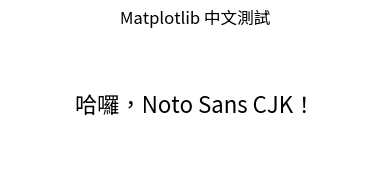

In [22]:
"""
跨平台載入 Noto Sans CJK 字型並驗證
在 VS Code + 本地 Python 環境執行
"""

import os
import sys
import platform
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager

# ---------- 1. 推斷各作業系統的預設字型路徑 ----------
def guess_noto_path() -> str | None:
    """回傳可能存在的 NotoSansCJK-Regular.ttc 路徑，找不到則回傳 None"""
    candidates = []

    match platform.system():
        case "Windows":
            candidates = [
                r"C:\Windows\Fonts\NotoSansCJK-Regular.ttc",
                r"C:\Windows\Fonts\NotoSansCJKtc-Regular.otf",
            ]
        case "Darwin":  # macOS
            candidates = [
                "/Library/Fonts/NotoSansCJK-Regular.ttc",
                "/System/Library/Fonts/NotoSansCJK.ttc",
            ]
        case "Linux":
            # 常見安裝位置；亦可加入 ~/.local/share/fonts
            candidates = [
                "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
                "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc",
                str(Path.home() / ".local/share/fonts/NotoSansCJK-Regular.ttc"),
            ]

    for p in candidates:
        if Path(p).is_file():
            return p
    return None


# ---------- 2. 取得字型路徑（可改為專案內相對路徑） ----------
# font_path = guess_noto_path()
font_path = 'NotoSansTC-Regular.ttf'  # 若已下載字型檔，請確認路徑正確

if font_path is None:
    # 若系統沒安裝，可改成專案相對路徑，例如 Path("fonts/NotoSansCJK-Regular.ttc")
    font_path = "fonts/NotoSansCJK-Regular.ttc"  # 請確認實際檔案位置
    if not Path(font_path).is_file():
        sys.exit(
            f"❌ 找不到 Noto Sans CJK 字型！\n"
            f"  請先安裝字型或把字型檔放到 {font_path}"
        )

# ---------- 3. 動態註冊並設定為預設中文字型 ----------
font_manager.fontManager.addfont(font_path)
plt.rcParams["font.family"] = font_manager.FontProperties(fname=font_path).get_name()

# ---------- 4. 驗證 ----------
print("✅ 已載入字型：", plt.rcParams["font.family"])

# (可選) 畫個示範圖
plt.figure(figsize=(4, 2))
plt.title("Matplotlib 中文測試")
plt.text(0.5, 0.5, "哈囉，Noto Sans CJK！", ha="center", va="center", size=16)
plt.axis("off")
plt.tight_layout()
plt.show()


=== 製作SFSS篩選出的15個特徵相關性熱感圖 ===
final_dataset_sfss 資料集形狀: (67610, 17)
資料集欄位: ['CUST_NO', '工單升級趨勢', 'SUB_CAT_拆機挽回_RATIO', 'MAIN_CAT_帳務相關_RATIO', 'MAIN_CAT_帳務相關_COUNT', 'SUB_CAT_無法上網_RATIO', 'SUB_CAT_拆機挽回_COUNT', 'paytype_1', 'paymethod_廠商代收', 'MAIN_CAT_網路連線問題_RATIO', 'MAIN_CAT_網路連線問題_COUNT', 'MAIN_CAT_經銷商問題_RATIO', 'SUB_CAT_無法上網_COUNT', 'SUB_CAT_台哥大-電訪約裝_RATIO', 'SUB_CAT_用戶退租_RATIO', '平均繳款延遲日數', '使用狀態_編碼']

篩選出的特徵數量: 15
特徵列表:
 1. 工單升級趨勢
 2. SUB_CAT_拆機挽回_RATIO
 3. MAIN_CAT_帳務相關_RATIO
 4. MAIN_CAT_帳務相關_COUNT
 5. SUB_CAT_無法上網_RATIO
 6. SUB_CAT_拆機挽回_COUNT
 7. paytype_1
 8. paymethod_廠商代收
 9. MAIN_CAT_網路連線問題_RATIO
10. MAIN_CAT_網路連線問題_COUNT
11. MAIN_CAT_經銷商問題_RATIO
12. SUB_CAT_無法上網_COUNT
13. SUB_CAT_台哥大-電訪約裝_RATIO
14. SUB_CAT_用戶退租_RATIO
15. 平均繳款延遲日數

=== 資料預處理 ===
總空值數: 531714
有空值的欄位:
  工單升級趨勢: 17739 個空值
  SUB_CAT_拆機挽回_RATIO: 32289 個空值
  MAIN_CAT_帳務相關_RATIO: 32289 個空值
  MAIN_CAT_帳務相關_COUNT: 32289 個空值
  SUB_CAT_無法上網_RATIO: 32289 個空值
  SUB_CAT_拆機挽回_COUNT: 32289 個空值
  paytype_1: 52932 個空值
  paymet

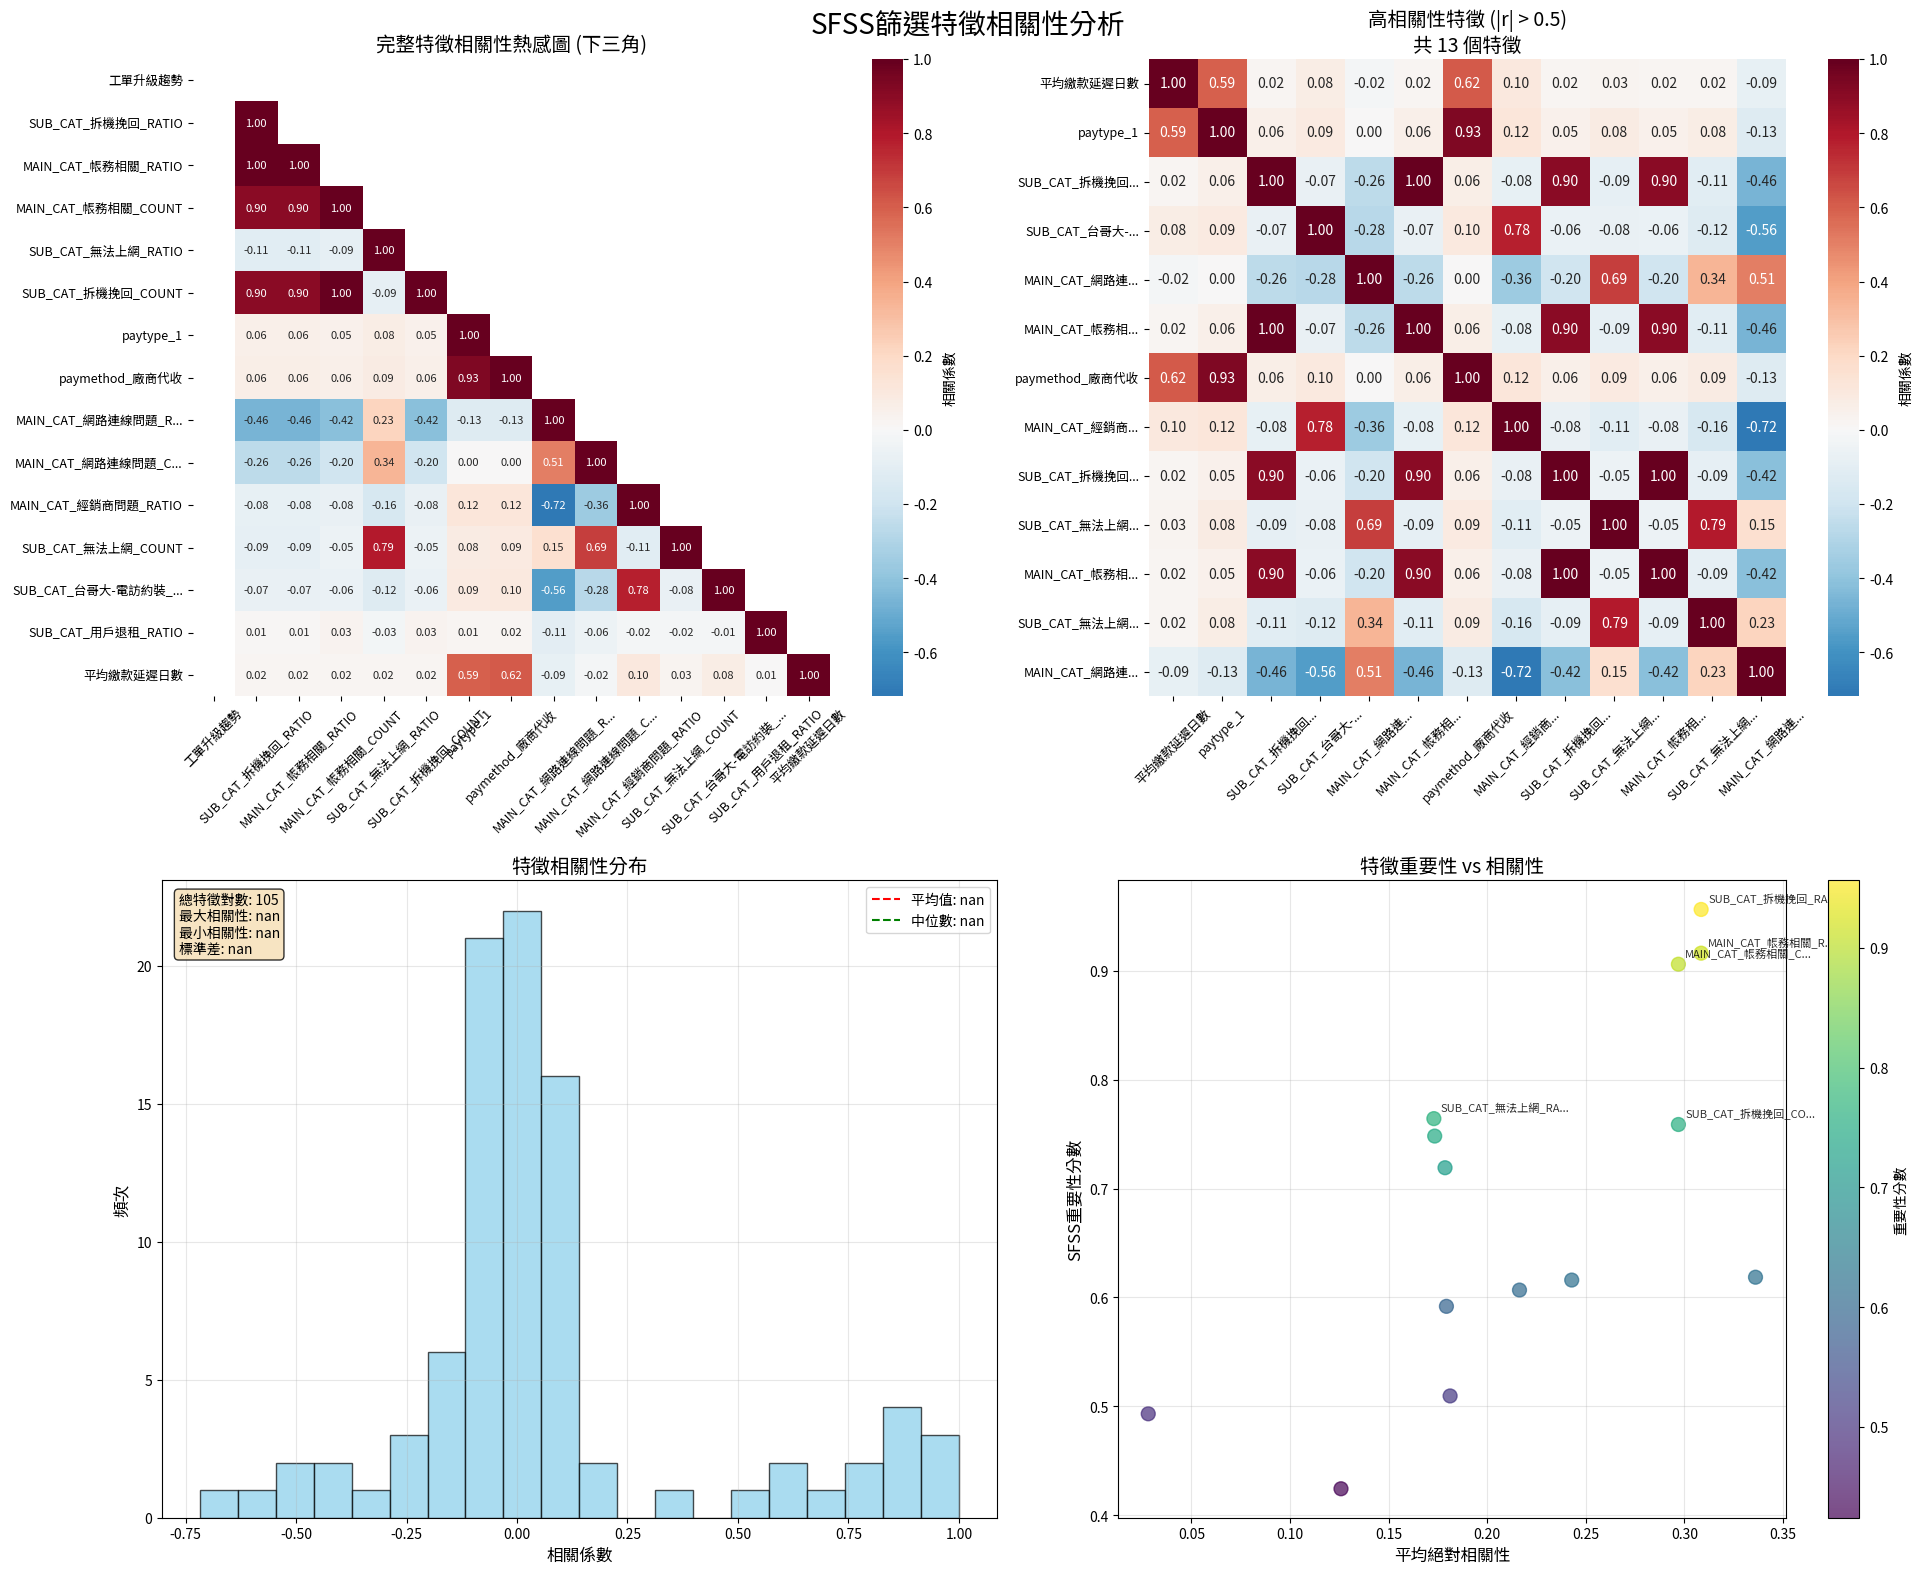


=== 相關性分析結果 ===
特徵數量: 15
特徵對數量: 105
相關係數統計:
  平均值: nan
  中位數: nan
  標準差: nan
  最大值: nan
  最小值: nan

相關性強度分布:
  強正相關 (> 0.7): 9 對
  中等正相關 (0.3-0.7): 5 對
  弱正相關 (0-0.3): 35 對
  弱負相關 (-0.3-0): 35 對
  中等負相關 (-0.7--0.3): 6 對
  強負相關 (< -0.7): 1 對

高相關性特徵對詳細列表:
 1. SUB_CAT_拆機挽回_RATIO             ↔ MAIN_CAT_帳務相關_RATIO            (r=1.000)
 2. MAIN_CAT_帳務相關_COUNT            ↔ SUB_CAT_拆機挽回_COUNT             (r=1.000)
 3. paytype_1                      ↔ paymethod_廠商代收                 (r=0.927)
 4. SUB_CAT_拆機挽回_RATIO             ↔ MAIN_CAT_帳務相關_COUNT            (r=0.895)
 5. SUB_CAT_拆機挽回_RATIO             ↔ SUB_CAT_拆機挽回_COUNT             (r=0.895)
 6. MAIN_CAT_帳務相關_RATIO            ↔ MAIN_CAT_帳務相關_COUNT            (r=0.895)
 7. MAIN_CAT_帳務相關_RATIO            ↔ SUB_CAT_拆機挽回_COUNT             (r=0.895)
 8. SUB_CAT_無法上網_RATIO             ↔ SUB_CAT_無法上網_COUNT             (r=0.788)
 9. MAIN_CAT_經銷商問題_RATIO           ↔ SUB_CAT_台哥大-電訪約裝_RATIO         (r=0.776)
10. MAIN_CAT_網路連線問題_RATIO          ↔ MAIN_

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 製作篩選出的15個特徵的相關性熱感圖
print("=== 製作SFSS篩選出的15個特徵相關性熱感圖 ===")

# 檢查 final_dataset_sfss 的基本資訊
print(f"final_dataset_sfss 資料集形狀: {final_dataset_sfss.shape}")
print(f"資料集欄位: {list(final_dataset_sfss.columns)}")

# 排除非特徵欄位，只保留特徵欄位
feature_cols = [col for col in final_dataset_sfss.columns 
               if col not in ['CUST_NO', '使用狀態', '使用狀態_編碼']]

print(f"\n篩選出的特徵數量: {len(feature_cols)}")
print(f"特徵列表:")
for i, col in enumerate(feature_cols, 1):
    print(f"{i:2d}. {col}")

# 確保有足夠的特徵進行分析
if len(feature_cols) == 0:
    print("❌ 沒有找到可用的特徵欄位")
else:
    # 準備特徵資料
    feature_data = final_dataset_sfss[feature_cols].copy()
    
    # 處理空值
    print(f"\n=== 資料預處理 ===")
    null_counts = feature_data.isnull().sum()
    total_nulls = null_counts.sum()
    print(f"總空值數: {total_nulls}")
    
    if total_nulls > 0:
        print("有空值的欄位:")
        for col, count in null_counts[null_counts > 0].items():
            print(f"  {col}: {count} 個空值")
        
        # 填補空值
        feature_data = feature_data.fillna(feature_data.median())
        print("✅ 已用中位數填補空值")
    
    # 確保所有資料都是數值型
    for col in feature_data.columns:
        feature_data[col] = pd.to_numeric(feature_data[col], errors='coerce')
    
    # 再次處理可能產生的空值
    feature_data = feature_data.fillna(0)
    
    # 計算相關性矩陣
    print(f"\n=== 計算相關性矩陣 ===")
    correlation_matrix = feature_data.corr()
    print(f"相關性矩陣形狀: {correlation_matrix.shape}")
    
    # 設定中文字體
    plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Arial Unicode MS', 'SimHei']
    plt.rcParams['axes.unicode_minus'] = False
    
    # 創建熱感圖
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    fig.suptitle('SFSS篩選特徵相關性分析', fontsize=20, fontweight='bold', y=0.98)
    
    # ==========================================
    # 圖1: 完整相關性熱感圖
    # ==========================================
    ax1 = axes[0, 0]
    
    # 調整特徵名稱長度以適應顯示
    display_names = []
    for col in feature_data.columns:
        if len(col) > 20:
            display_names.append(col[:17] + '...')
        else:
            display_names.append(col)
    
    # 重新命名相關性矩陣的行列
    correlation_display = correlation_matrix.copy()
    correlation_display.index = display_names
    correlation_display.columns = display_names
    
    mask = np.triu(np.ones_like(correlation_display, dtype=bool), k=1)  # 遮罩上三角
    
    sns.heatmap(correlation_display, 
                mask=mask,
                annot=True, 
                cmap='RdBu_r', 
                center=0,
                fmt='.2f',
                square=True,
                cbar_kws={'label': '相關係數'},
                ax=ax1,
                annot_kws={'size': 8})
    
    ax1.set_title('完整特徵相關性熱感圖 (下三角)', fontsize=14, fontweight='bold')
    ax1.tick_params(axis='x', rotation=45, labelsize=9)
    ax1.tick_params(axis='y', rotation=0, labelsize=9)
    
    # ==========================================
    # 圖2: 高相關性特徵對 (|r| > 0.5)
    # ==========================================
    ax2 = axes[0, 1]
    
    # 找出高相關性的特徵對
    high_corr_pairs = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            corr_val = correlation_matrix.iloc[i, j]
            if abs(corr_val) > 0.5:
                high_corr_pairs.append({
                    'feature1': correlation_matrix.columns[i],
                    'feature2': correlation_matrix.columns[j],
                    'correlation': corr_val
                })
    
    print(f"\n高相關性特徵對 (|r| > 0.5): {len(high_corr_pairs)} 對")
    
    if high_corr_pairs:
        # 創建高相關性特徵的子矩陣
        high_corr_features = list(set([pair['feature1'] for pair in high_corr_pairs] + 
                                    [pair['feature2'] for pair in high_corr_pairs]))
        
        if len(high_corr_features) > 1:
            high_corr_matrix = correlation_matrix.loc[high_corr_features, high_corr_features]
            
            # 調整特徵名稱
            high_corr_display_names = []
            for col in high_corr_features:
                if len(col) > 15:
                    high_corr_display_names.append(col[:12] + '...')
                else:
                    high_corr_display_names.append(col)
            
            high_corr_matrix.index = high_corr_display_names
            high_corr_matrix.columns = high_corr_display_names
            
            sns.heatmap(high_corr_matrix, 
                       annot=True, 
                       cmap='RdBu_r', 
                       center=0,
                       fmt='.2f',
                       square=True,
                       cbar_kws={'label': '相關係數'},
                       ax=ax2,
                       annot_kws={'size': 10})
            
            ax2.set_title(f'高相關性特徵 (|r| > 0.5)\n共 {len(high_corr_features)} 個特徵', 
                         fontsize=14, fontweight='bold')
        else:
            ax2.text(0.5, 0.5, '沒有發現高相關性\n特徵對 (|r| > 0.5)', 
                    ha='center', va='center', fontsize=12, transform=ax2.transAxes)
            ax2.set_title('高相關性特徵分析', fontsize=14, fontweight='bold')
    else:
        ax2.text(0.5, 0.5, '沒有發現高相關性\n特徵對 (|r| > 0.5)', 
                ha='center', va='center', fontsize=12, transform=ax2.transAxes)
        ax2.set_title('高相關性特徵分析', fontsize=14, fontweight='bold')
    
    ax2.tick_params(axis='x', rotation=45, labelsize=9)
    ax2.tick_params(axis='y', rotation=0, labelsize=9)
    
    # ==========================================
    # 圖3: 相關性分布直方圖
    # ==========================================
    ax3 = axes[1, 0]
    
    # 取得所有相關係數（不包括對角線）
    corr_values = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            corr_values.append(correlation_matrix.iloc[i, j])
    
    # 繪製直方圖
    n_bins = min(20, len(corr_values) // 2) if len(corr_values) > 10 else 10
    ax3.hist(corr_values, bins=n_bins, alpha=0.7, color='skyblue', edgecolor='black')
    ax3.axvline(x=np.mean(corr_values), color='red', linestyle='--', 
               label=f'平均值: {np.mean(corr_values):.3f}')
    ax3.axvline(x=np.median(corr_values), color='green', linestyle='--', 
               label=f'中位數: {np.median(corr_values):.3f}')
    
    ax3.set_xlabel('相關係數', fontsize=12)
    ax3.set_ylabel('頻次', fontsize=12)
    ax3.set_title('特徵相關性分布', fontsize=14, fontweight='bold')
    ax3.legend()
    ax3.grid(alpha=0.3)
    
    # 添加統計資訊
    ax3.text(0.02, 0.98, f'總特徵對數: {len(corr_values)}\n'
                         f'最大相關性: {np.max(corr_values):.3f}\n'
                         f'最小相關性: {np.min(corr_values):.3f}\n'
                         f'標準差: {np.std(corr_values):.3f}',
            transform=ax3.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
            fontsize=10)
    
    # ==========================================
    # 圖4: 特徵重要性 vs 相關性散佈圖
    # ==========================================
    ax4 = axes[1, 1]
    
    # 如果有 SFSS 結果，顯示特徵重要性
    if 'sfss_results' in locals() and sfss_results:
        feature_scores = sfss_results.get('feature_scores', {})
        
        if feature_scores:
            # 準備散佈圖資料
            scatter_data = []
            
            for feature in feature_cols:
                importance = feature_scores.get(feature, 0)
                # 計算該特徵與其他特徵的平均絕對相關性
                other_features = [f for f in feature_cols if f != feature]
                if other_features:
                    avg_abs_corr = correlation_matrix.loc[feature, other_features].abs().mean()
                else:
                    avg_abs_corr = 0
                
                scatter_data.append({
                    'feature': feature,
                    'importance': importance,
                    'avg_abs_correlation': avg_abs_corr
                })
            
            # 繪製散佈圖
            scatter_df = pd.DataFrame(scatter_data)
            
            scatter = ax4.scatter(scatter_df['avg_abs_correlation'], 
                                scatter_df['importance'],
                                c=scatter_df['importance'], 
                                cmap='viridis', 
                                s=100, alpha=0.7)
            
            # 添加特徵名稱標註（只標註前5個重要特徵）
            top_features = scatter_df.nlargest(5, 'importance')
            for _, row in top_features.iterrows():
                feature_name = row['feature'][:15] + '...' if len(row['feature']) > 15 else row['feature']
                ax4.annotate(feature_name, 
                           (row['avg_abs_correlation'], row['importance']),
                           xytext=(5, 5), textcoords='offset points',
                           fontsize=8, alpha=0.8)
            
            ax4.set_xlabel('平均絕對相關性', fontsize=12)
            ax4.set_ylabel('SFSS重要性分數', fontsize=12)
            ax4.set_title('特徵重要性 vs 相關性', fontsize=14, fontweight='bold')
            
            # 添加顏色條
            cbar = plt.colorbar(scatter, ax=ax4)
            cbar.set_label('重要性分數', fontsize=10)
            
            ax4.grid(alpha=0.3)
        else:
            ax4.text(0.5, 0.5, '無SFSS重要性\n分數資料', 
                    ha='center', va='center', fontsize=12, transform=ax4.transAxes)
            ax4.set_title('特徵重要性分析', fontsize=14, fontweight='bold')
    else:
        ax4.text(0.5, 0.5, '無SFSS結果\n資料可用', 
                ha='center', va='center', fontsize=12, transform=ax4.transAxes)
        ax4.set_title('特徵重要性分析', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()
    
    # ==========================================
    # 輸出詳細統計資訊
    # ==========================================
    print(f"\n=== 相關性分析結果 ===")
    print(f"特徵數量: {len(feature_cols)}")
    print(f"特徵對數量: {len(corr_values)}")
    print(f"相關係數統計:")
    print(f"  平均值: {np.mean(corr_values):.4f}")
    print(f"  中位數: {np.median(corr_values):.4f}")
    print(f"  標準差: {np.std(corr_values):.4f}")
    print(f"  最大值: {np.max(corr_values):.4f}")
    print(f"  最小值: {np.min(corr_values):.4f}")
    
    # 相關性強度分類
    strong_positive = sum(1 for x in corr_values if x > 0.7)
    moderate_positive = sum(1 for x in corr_values if 0.3 < x <= 0.7)
    weak_positive = sum(1 for x in corr_values if 0 < x <= 0.3)
    weak_negative = sum(1 for x in corr_values if -0.3 <= x < 0)
    moderate_negative = sum(1 for x in corr_values if -0.7 <= x < -0.3)
    strong_negative = sum(1 for x in corr_values if x < -0.7)
    
    print(f"\n相關性強度分布:")
    print(f"  強正相關 (> 0.7): {strong_positive} 對")
    print(f"  中等正相關 (0.3-0.7): {moderate_positive} 對")
    print(f"  弱正相關 (0-0.3): {weak_positive} 對")
    print(f"  弱負相關 (-0.3-0): {weak_negative} 對")
    print(f"  中等負相關 (-0.7--0.3): {moderate_negative} 對")
    print(f"  強負相關 (< -0.7): {strong_negative} 對")
    
    if high_corr_pairs:
        print(f"\n高相關性特徵對詳細列表:")
        for i, pair in enumerate(sorted(high_corr_pairs, 
                                       key=lambda x: abs(x['correlation']), 
                                       reverse=True)[:10], 1):
            print(f"{i:2d}. {pair['feature1'][:30]:<30} ↔ "
                  f"{pair['feature2'][:30]:<30} (r={pair['correlation']:.3f})")
    
    print(f"\n✅ 相關性熱感圖製作完成！")